<a href="https://colab.research.google.com/github/kusumv014/Zero-Trust-Final/blob/main/ZeroTrustFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Dataset Validation and Initial Inspection
Description
Before applying machine-learning models, the generated Zero Trust dataset must first be validated to ensure that it is complete, correctly structured, and suitable for further analysis.
The dataset consists of 10,000 simulated enterprise scenarios, with each observation representing a hypothetical organisation evaluating a Zero Trust investment. The variables capture organisational characteristics, Zero Trust maturity, cyber-risk exposure, implementation costs, operational benefits, and financial outcomes.
This validation stage is important because errors such as missing values, duplicated records, incorrect calculations, or unrealistic financial values could affect the reliability of the subsequent Monte Carlo and machine-learning analysis.
The first stage therefore loads the dataset and performs an initial inspection of its dimensions, variable types, and sample observations.

In [1]:
# ============================================================
# STEP 1: DATASET VALIDATION AND INITIAL INSPECTION
# ============================================================

# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1.1 Load the Zero Trust simulation dataset
# ------------------------------------------------------------

df = pd.read_csv("zero_trust_business_value_dataset_10000.csv")

print("=" * 60)
print("ZERO TRUST BUSINESS VALUE DATASET")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Scenarios:", df.shape[0])
print("Number of Variables:", df.shape[1])


# ------------------------------------------------------------
# 1.2 Display the first five observations
# ------------------------------------------------------------

print("\nFirst Five Observations:")
display(df.head())


# ------------------------------------------------------------
# 1.3 Inspect dataset structure
# ------------------------------------------------------------

print("\nDataset Information:")
df.info()

ZERO TRUST BUSINESS VALUE DATASET

Dataset Shape:
(10000, 40)

Number of Scenarios: 10000
Number of Variables: 40

First Five Observations:


,Scenario_ID,Industry,Company_Size,Employees,Identity_Current,Device_Current,Network_Current,Application_Current,Data_Current,Current_Maturity,...,Incident_Response_Savings_USD,Compliance_Savings_USD,Productivity_Savings_USD,Gross_Annual_Benefit_USD,Net_Annual_Benefit_USD,Discount_Rate,NPV_5Y_USD,ROI_5Y,IRR_5Y,Payback_Years
0,1,Technology,Medium,507,3,4,3,3,1,2.8,...,3190.01,574.84,34023.87,80184.93,31061.39,0.0950,-194611.24,-0.5052,-0.1965,10.10
1,2,Professional Services,Small,181,3,1,2,1,3,2.0,...,1929.35,505.56,18743.56,62746.83,34152.37,0.1372,-60681.27,-0.0445,-0.0150,5.23
2,3,Manufacturing,Small,94,3,1,2,2,3,2.2,...,659.28,437.02,6498.11,325807.46,314380.05,0.1396,970845.67,13.3670,2.8701,0.35
3,4,Retail,Medium,518,3,1,2,1,3,2.0,...,4775.31,3999.69,73387.42,217651.36,145038.00,0.0919,63903.55,0.4579,0.1404,3.43
4,5,Financial Services,Medium,560,1,2,3,1,1,1.6,...,5209.31,4531.80,46443.68,133904.15,86208.86,0.1234,-205335.51,-0.1606,-0.0557,5.96



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Scenario_ID                     10000 non-null  int64  
 1   Industry                        10000 non-null  object 
 2   Company_Size                    10000 non-null  object 
 3   Employees                       10000 non-null  int64  
 4   Identity_Current                10000 non-null  int64  
 5   Device_Current                  10000 non-null  int64  
 6   Network_Current                 10000 non-null  int64  
 7   Application_Current             10000 non-null  int64  
 8   Data_Current                    10000 non-null  int64  
 9   Current_Maturity                10000 non-null  float64
 10  Identity_Target                 10000 non-null  int64  
 11  Device_Target                   10000 non-null  int64  
 12  Network_Tar

Initial Dataset Inspection:
The Zero Trust Business Value dataset was successfully imported into Python for validation and analysis. The dataset contains 10,000 simulated enterprise scenarios and 40 variables representing organisational characteristics, Zero Trust maturity, cyber-risk exposure, implementation and operational costs, expected business benefits, and financial performance indicators. Initial inspection of the dataset was conducted using the dataset dimensions, first five observations, and variable-level information. This stage establishes the structural integrity of the dataset before missing-value analysis, mathematical validation, exploratory analysis, Monte Carlo evaluation, and machine-learning modelling.

Step 2: Missing Values and Data Quality Check
Description
After confirming that the dataset has been loaded correctly, the next stage is to assess its data quality.
Missing values can affect statistical analysis and machine-learning models if they are not properly understood. However, in this Zero Trust dataset, a missing value does not automatically indicate an error.
For example, Payback_Years or IRR_5Y may be undefined for scenarios where the Zero Trust investment does not generate sufficient positive financial returns. Such cases may represent legitimate economically unfavourable scenarios rather than poor-quality data.
Therefore, this step identifies missing values and duplicate records without automatically deleting them.

In [2]:
# ============================================================
# STEP 2: MISSING VALUES AND DATA QUALITY CHECK
# ============================================================

# ------------------------------------------------------------
# 2.1 Check for missing values
# ------------------------------------------------------------

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

# Show only variables containing missing values
missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

if missing_summary.empty:
    print("\nNo missing values were detected in the dataset.")
else:
    print("\nVariables containing missing values:\n")
    display(missing_summary.round(2))

MISSING VALUE ANALYSIS

Variables containing missing values:



,Missing Values,Missing Percentage (%)
IRR_5Y,310,3.10
Payback_Years,309,3.09


In [3]:
# ------------------------------------------------------------
# 2.2 Check for duplicate values
# ------------------------------------------------------------
duplicate_rows = df.duplicated().sum()

duplicate_scenario_ids = (
    df["Scenario_ID"].duplicated().sum()
)

print("\n" + "=" * 60)
print("DUPLICATE RECORD CHECK")
print("=" * 60)

print(
    f"\nDuplicate complete rows : {duplicate_rows:,}"
)


DUPLICATE RECORD CHECK

Duplicate complete rows : 0


In [4]:
# ------------------------------------------------------------
# 2.3 Check variable data types
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("VARIABLE DATA TYPES")
print("=" * 60)

dtype_summary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

display(dtype_summary)


VARIABLE DATA TYPES


,Variable,Data Type
0,Scenario_ID,int64
1,Industry,object
2,Company_Size,object
3,Employees,int64
4,Identity_Current,int64
5,Device_Current,int64
6,Network_Current,int64
7,Application_Current,int64
8,Data_Current,int64
9,Current_Maturity,float64


### Interpretation

A structured data-quality assessment was conducted to identify missing observations, duplicate records, and potential data-type inconsistencies within the simulated dataset.

Missing values were not automatically removed because their interpretation depends on the underlying financial scenario. In particular, financial indicators such as IRR and Payback Period may be undefined where an investment does not generate sufficient positive annual benefits. Such observations may therefore represent economically unfavourable Zero Trust investment scenarios rather than data-generation errors.

Duplicate observations and Scenario_ID values were also examined because each row of the dataset is intended to represent a unique simulated enterprise scenario.

Finally, variable data types were inspected to confirm that numerical risk and financial variables were correctly represented as quantitative data, while organisational categories such as Industry and Company Size were represented as categorical variables.

This validation process reduces the risk of introducing avoidable data-quality problems into the subsequent statistical and machine-learning analysis.

Step 3: Mathematical and Logical Validation
Description
Following the initial data-quality assessment, the next stage validates whether the simulated variables follow the mathematical and logical relationships defined within the Zero Trust Business Value framework.
This is particularly important because several variables in the dataset are derived from other variables. For example, Annual Loss Expectancy (ALE) is calculated using Single Loss Expectancy (SLE) and Loss Event Frequency (LEF), while residual cyber-risk is calculated after accounting for the estimated effects of Zero Trust controls.
The validation also checks whether target Zero Trust maturity is greater than or equal to current maturity. This ensures that the simulated scenarios represent either maturity improvement or maintenance rather than an unexplained reduction in maturity.
The purpose of this step is therefore to confirm the internal computational consistency of the simulated dataset before conducting exploratory analysis or machine-learning modelling.
Your methodology already defines SLE, LEF, expected annual loss and residual risk as core components of the quantitative model.

In [5]:
# ============================================================
# STEP 3: MATHEMATICAL AND LOGICAL VALIDATION
# ============================================================

# ------------------------------------------------------------
# 3.1 Validate Baseline Annual Loss Expectancy (ALE)
# ------------------------------------------------------------

calculated_ale = df["SLE_USD"] * df["LEF"]

ale_valid = np.isclose(
    df["Baseline_ALE_USD"],
    calculated_ale,
    rtol=1e-3,
    atol=10
)

ale_accuracy = ale_valid.mean() * 100

print("=" * 60)
print("BASELINE ALE VALIDATION")
print("=" * 60)

print(f"\nValid ALE calculations : {ale_valid.sum():,}")
print(f"Invalid ALE calculations: {(~ale_valid).sum():,}")
print(f"Validation accuracy     : {ale_accuracy:.2f}%")

if ale_accuracy >= 99:
    print("\n✓ Baseline ALE calculations are mathematically consistent.")
else:
    print("\n⚠ Baseline ALE calculations require further investigation.")

BASELINE ALE VALIDATION

Valid ALE calculations : 9,956
Invalid ALE calculations: 44
Validation accuracy     : 99.56%

✓ Baseline ALE calculations are mathematically consistent.


In [6]:
# ------------------------------------------------------------
# 3.2 Validate residual cyber-risk exposure
# ------------------------------------------------------------

residual_valid = (
    df["Residual_ALE_USD"]
    <= df["Baseline_ALE_USD"] + 1
)

residual_accuracy = residual_valid.mean() * 100

print("\n" + "=" * 60)
print("RESIDUAL RISK VALIDATION")
print("=" * 60)

print(f"\nValid scenarios   : {residual_valid.sum():,}")
print(f"Invalid scenarios : {(~residual_valid).sum():,}")
print(f"Validation rate   : {residual_accuracy:.2f}%")

if residual_accuracy == 100:
    print("\n✓ Residual ALE does not exceed baseline ALE.")
else:
    print("\n⚠ Some residual-risk calculations require investigation.")


RESIDUAL RISK VALIDATION

Valid scenarios   : 10,000
Invalid scenarios : 0
Validation rate   : 100.00%

✓ Residual ALE does not exceed baseline ALE.


Explanation
This validation confirms that the application of Zero Trust controls does not unintentionally increase the modelled cyber-risk exposure.

In [7]:
# ------------------------------------------------------------
# 3.3 Validate avoided-loss calculation
# ------------------------------------------------------------

calculated_avoided_loss = (
    df["Baseline_ALE_USD"]
    - df["Residual_ALE_USD"]
)

avoided_loss_valid = np.isclose(
    df["Avoided_Loss_USD"],
    calculated_avoided_loss,
    rtol=1e-3,
    atol=10
)

avoided_loss_accuracy = (
    avoided_loss_valid.mean() * 100
)

print("\n" + "=" * 60)
print("AVOIDED LOSS VALIDATION")
print("=" * 60)

print(
    f"\nValidation accuracy : "
    f"{avoided_loss_accuracy:.2f}%"
)

if avoided_loss_accuracy >= 99:
    print("✓ Avoided-loss calculations are mathematically consistent.")
else:
    print("⚠ Avoided-loss calculations require investigation.")


AVOIDED LOSS VALIDATION

Validation accuracy : 100.00%
✓ Avoided-loss calculations are mathematically consistent.


This is useful because avoided loss eventually contributes to the economic benefit attributed to Zero Trust.

In [8]:
# ------------------------------------------------------------
# 3.4 Validate Zero Trust maturity progression
# ------------------------------------------------------------

maturity_valid = (
    df["Target_Maturity"]
    >= df["Current_Maturity"]
)

maturity_accuracy = maturity_valid.mean() * 100

print("\n" + "=" * 60)
print("ZERO TRUST MATURITY VALIDATION")
print("=" * 60)

print(f"\nValid maturity scenarios : {maturity_valid.sum():,}")
print(f"Invalid scenarios        : {(~maturity_valid).sum():,}")
print(f"Validation rate          : {maturity_accuracy:.2f}%")

if maturity_accuracy == 100:
    print(
        "\n✓ All target maturity scores are "
        "greater than or equal to current maturity."
    )
else:
    print(
        "\n⚠ Some maturity scenarios require investigation."
    )


ZERO TRUST MATURITY VALIDATION

Valid maturity scenarios : 10,000
Invalid scenarios        : 0
Validation rate          : 100.00%

✓ All target maturity scores are greater than or equal to current maturity.


In [9]:
# ------------------------------------------------------------
# 3.5 Validation summary
# ------------------------------------------------------------

validation_summary = pd.DataFrame({
    "Validation Test": [
        "Baseline ALE = SLE × LEF",
        "Residual ALE ≤ Baseline ALE",
        "Avoided Loss = Baseline ALE - Residual ALE",
        "Target Maturity ≥ Current Maturity"
    ],

    "Validation Rate (%)": [
        ale_accuracy,
        residual_accuracy,
        avoided_loss_accuracy,
        maturity_accuracy
    ]
})

validation_summary["Status"] = np.where(
    validation_summary["Validation Rate (%)"] >= 99,
    "PASS",
    "REVIEW"
)

validation_summary["Validation Rate (%)"] = (
    validation_summary["Validation Rate (%)"].round(2)
)

print("\n" + "=" * 60)
print("OVERALL VALIDATION SUMMARY")
print("=" * 60)

display(validation_summary)


OVERALL VALIDATION SUMMARY


,Validation Test,Validation Rate (%),Status
0,Baseline ALE = SLE × LEF,99.56,PASS
1,Residual ALE ≤ Baseline ALE,100.00,PASS
2,Avoided Loss = Baseline ALE - Residual ALE,100.00,PASS
3,Target Maturity ≥ Current Maturity,100.00,PASS


### Interpretation

The mathematical and logical validation tests were conducted to evaluate the internal consistency of the simulated Zero Trust Business Value dataset.

Baseline Annual Loss Expectancy (ALE) was independently recalculated using Single Loss Expectancy (SLE) and Loss Event Frequency (LEF) and compared with the values stored within the dataset. Residual ALE was subsequently evaluated to ensure that modelled post-control risk exposure did not exceed baseline exposure.

The avoided-loss calculation was also independently validated by comparing the difference between baseline and residual ALE with the corresponding Avoided_Loss variable.

Finally, Zero Trust maturity progression was examined to confirm that target maturity was greater than or equal to current maturity across the simulated enterprise scenarios.

These validation tests provide evidence that the derived cybersecurity-risk and maturity variables are computationally consistent with the mathematical relationships defined within the proposed framework. This provides a validated foundation for subsequent exploratory data analysis, financial analysis, Monte Carlo evaluation, and machine-learning modelling.

# Step 4: Exploratory Data Analysis (EDA)

Following dataset validation, Exploratory Data Analysis (EDA) was conducted to examine the characteristics and distributions of the simulated Zero Trust enterprise scenarios.

The purpose of EDA is to identify patterns, variation, skewness, extreme observations, and potential relationships among the cybersecurity, maturity, operational, and financial variables before applying Monte Carlo analysis and machine-learning models.

The analysis focuses on four principal dimensions of the proposed framework:

1. Organisational characteristics
2. Zero Trust maturity
3. Cybersecurity risk exposure
4. Financial and operational business value

Because the dataset is simulation-based, the distributions presented in this section represent the behaviour of the proposed analytical model under varying enterprise scenarios. They should not be interpreted as the observed distribution of real-world organisations.

In [10]:
# ============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 4.1 Descriptive Statistics
# ------------------------------------------------------------

eda_variables = [
    "Employees",
    "Current_Maturity",
    "Target_Maturity",
    "Maturity_Improvement",
    "SLE_USD",
    "LEF",
    "Baseline_ALE_USD",
    "Residual_ALE_USD",
    "Avoided_Loss_USD",
    "Implementation_Cost_USD",
    "Annual_OpEx_USD",
    "Net_Annual_Benefit_USD",
    "NPV_5Y_USD",
    "ROI_5Y",
    "IRR_5Y",
    "Payback_Years"
]

descriptive_stats = df[eda_variables].describe().T

descriptive_stats = descriptive_stats[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

display(descriptive_stats.round(2))

,count,mean,std,min,25%,50%,75%,max
Employees,10000.0,1714.81,2585.82,50.00,195.00,553.00,1271.25,9998.00
Current_Maturity,10000.0,2.17,0.42,1.00,1.80,2.20,2.40,3.80
Target_Maturity,10000.0,3.08,0.42,1.40,2.80,3.20,3.40,4.00
Maturity_Improvement,10000.0,0.91,0.42,0.00,0.60,0.80,1.20,2.60
SLE_USD,10000.0,5171477.93,3052622.36,499926.77,3068400.26,4431131.91,6439735.38,25000000.00
LEF,10000.0,0.16,0.07,0.02,0.10,0.15,0.21,0.35
Baseline_ALE_USD,10000.0,809349.21,643043.44,31635.61,373726.34,631658.45,1046388.38,7234945.28
Residual_ALE_USD,10000.0,706915.85,565501.22,26423.36,325668.76,547725.80,914880.14,6833232.75
Avoided_Loss_USD,10000.0,102433.36,100007.05,0.00,37448.52,71833.58,133470.79,1335599.53
Implementation_Cost_USD,10000.0,413502.64,312180.29,38997.47,184025.18,314709.00,548271.50,2017052.97


The describe() function calculates summary statistics including the mean, standard deviation, minimum, maximum, median and quartiles.
This allows us to understand the overall range of the simulated scenarios before examining individual distributions.
### Interpretation

Descriptive statistics were calculated for the principal organisational, maturity, cybersecurity-risk, and financial variables.

The results provide an initial understanding of the central tendency, dispersion, and range of the simulated scenarios. Particular attention was given to differences between the mean and median because large differences may indicate skewed distributions or the presence of extreme financial outcomes.

These statistics provide a quantitative overview of the simulation before individual variable distributions and relationships are examined.


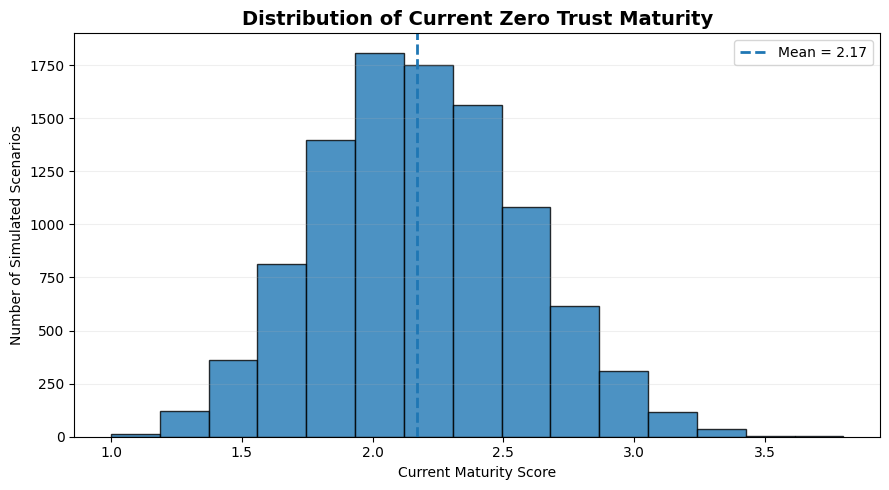

In [11]:
# ------------------------------------------------------------
# 4.2 Distribution of Current Zero Trust Maturity
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    df["Current_Maturity"],
    bins=15,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    df["Current_Maturity"].mean(),
    linestyle="--",
    linewidth=2,
    label=f'Mean = {df["Current_Maturity"].mean():.2f}'
)

plt.title(
    "Distribution of Current Zero Trust Maturity",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Current Maturity Score")
plt.ylabel("Number of Simulated Scenarios")

plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

This shows how the simulated enterprises are distributed across their starting Zero Trust maturity positions.
The vertical dashed line represents the average maturity score.

### Interpretation

The distribution illustrates the simulated baseline Zero Trust maturity levels across the 10,000 enterprise scenarios.

The maturity score represents the aggregated position across the five Zero Trust pillars: Identity, Devices, Networks, Applications and Workloads, and Data.

The distribution reflects the assumptions incorporated into the simulation model and therefore provides the baseline against which target maturity and maturity improvement are subsequently evaluated. It should not be interpreted as an empirical estimate of the maturity distribution of the wider enterprise population.

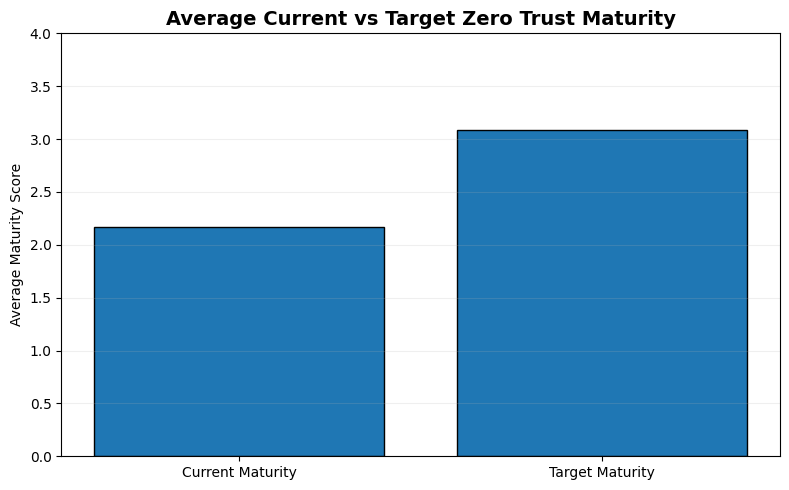

,Maturity Stage,Average Score
0,Current Maturity,2.17
1,Target Maturity,3.08


In [12]:
# ------------------------------------------------------------
# 4.3 Current vs Target Zero Trust Maturity
# ------------------------------------------------------------

maturity_comparison = pd.DataFrame({
    "Maturity Stage": [
        "Current Maturity",
        "Target Maturity"
    ],
    "Average Score": [
        df["Current_Maturity"].mean(),
        df["Target_Maturity"].mean()
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    maturity_comparison["Maturity Stage"],
    maturity_comparison["Average Score"],
    edgecolor="black"
)

plt.title(
    "Average Current vs Target Zero Trust Maturity",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Average Maturity Score")
plt.ylim(0, 4)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

display(maturity_comparison.round(2))

### Interpretation

The comparison between current and target maturity demonstrates the modelled Zero Trust transformation across the simulated enterprise scenarios.

Target maturity is constrained to remain equal to or greater than current maturity. Consequently, the difference between the two measures represents the modelled maturity improvement associated with the proposed Zero Trust investment.

This maturity improvement subsequently contributes to the estimation of changes in breach likelihood, breach impact, residual cyber-risk, and financial business value.

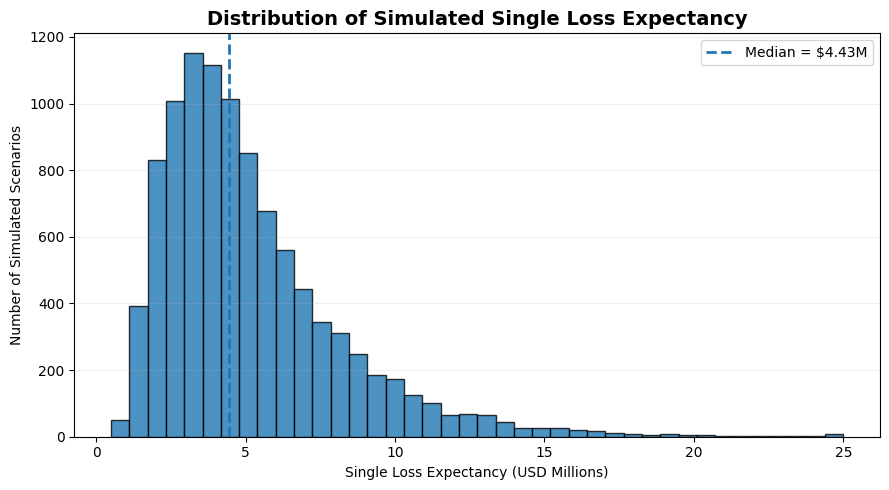

In [13]:
# ------------------------------------------------------------
# 4.4 Single Loss Expectancy Distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    df["SLE_USD"] / 1_000_000,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    df["SLE_USD"].median() / 1_000_000,
    linestyle="--",
    linewidth=2,
    label=f'Median = ${df["SLE_USD"].median()/1_000_000:.2f}M'
)

plt.title(
    "Distribution of Simulated Single Loss Expectancy",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Single Loss Expectancy (USD Millions)")
plt.ylabel("Number of Simulated Scenarios")

plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

Why use median here?
Cyber-loss values are often highly skewed in the simulation. A few very large losses can push the mean upward.
Therefore, the median is useful alongside the mean.

### Interpretation

Single Loss Expectancy (SLE) represents the estimated financial impact associated with a successful cyber-loss event.

The simulated SLE distribution demonstrates variation in potential loss magnitude across enterprise scenarios rather than assigning a single fixed breach cost to every organisation.

The distribution is positively skewed, allowing the analytical framework to represent both more common moderate-loss scenarios and less frequent high-impact scenarios. This treatment is particularly important for cyber-risk modelling because reliance on a single deterministic loss value could underrepresent uncertainty in potential financial exposure.

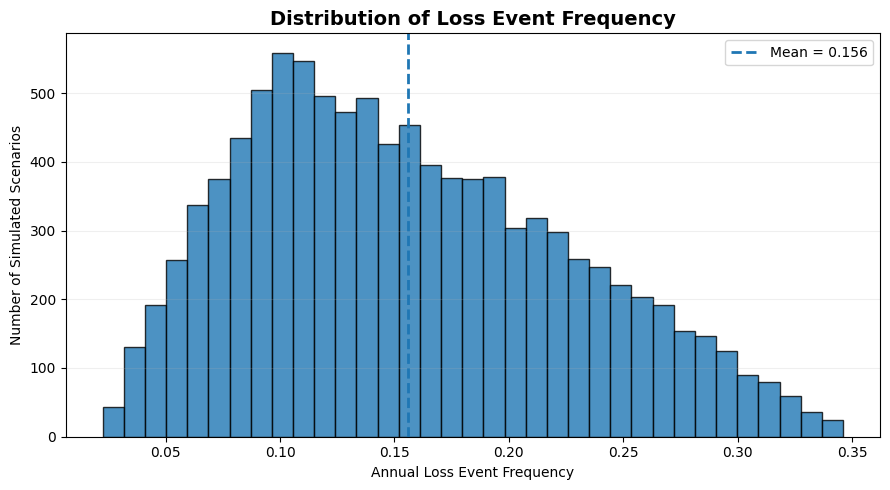

In [14]:
# ------------------------------------------------------------
# 4.5 Loss Event Frequency Distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    df["LEF"],
    bins=35,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    df["LEF"].mean(),
    linestyle="--",
    linewidth=2,
    label=f'Mean = {df["LEF"].mean():.3f}'
)

plt.title(
    "Distribution of Loss Event Frequency",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Annual Loss Event Frequency")
plt.ylabel("Number of Simulated Scenarios")

plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

### Interpretation

Loss Event Frequency (LEF) represents the modelled annual frequency of cybersecurity loss events within each simulated enterprise scenario.

The LEF distribution is an explicit probabilistic modelling assumption used to introduce uncertainty into the quantitative risk framework. It should therefore not be interpreted as a directly observed annual breach probability derived from the Verizon DBIR.

When combined with Single Loss Expectancy, LEF enables the model to estimate baseline Annual Loss Expectancy for each simulated scenario.

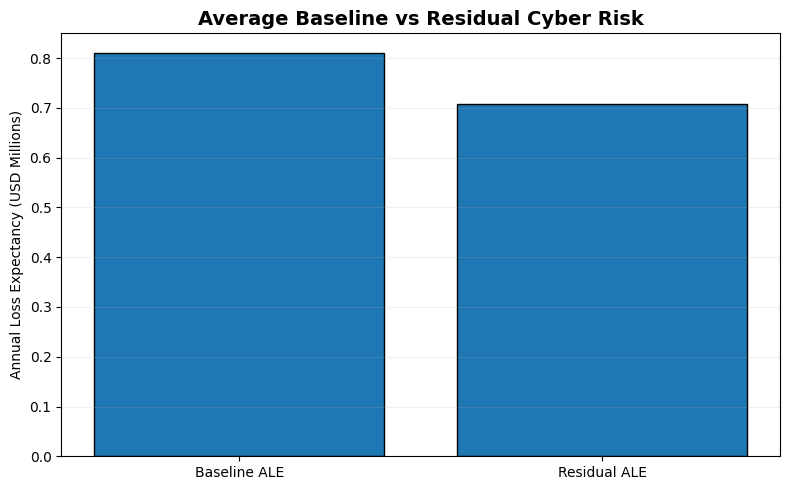

,Risk Measure,Mean Value
0,Baseline ALE,809349.21
1,Residual ALE,706915.85


In [15]:
# ------------------------------------------------------------
# 4.6 Baseline vs Residual ALE
# ------------------------------------------------------------

risk_comparison = pd.DataFrame({
    "Risk Measure": [
        "Baseline ALE",
        "Residual ALE"
    ],
    "Mean Value": [
        df["Baseline_ALE_USD"].mean(),
        df["Residual_ALE_USD"].mean()
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    risk_comparison["Risk Measure"],
    risk_comparison["Mean Value"] / 1_000_000,
    edgecolor="black"
)

plt.title(
    "Average Baseline vs Residual Cyber Risk",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Annual Loss Expectancy (USD Millions)")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

display(risk_comparison.round(2))

### Interpretation

The comparison between baseline and residual Annual Loss Expectancy illustrates the modelled financial effect of Zero Trust risk reduction.

Baseline ALE represents expected annual cyber-loss exposure before the modelled maturity improvement, whereas residual ALE represents the remaining expected exposure after applying the simulated reductions in breach likelihood and breach impact.

The difference between these two values represents avoided expected loss and forms one component of the estimated economic benefit associated with the Zero Trust investment.

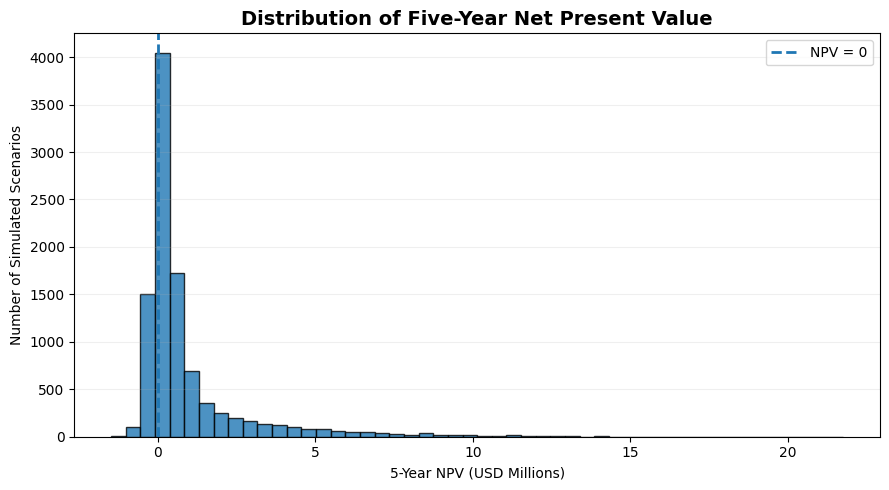

In [16]:
# ------------------------------------------------------------
# 4.7 Five-Year NPV Distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    df["NPV_5Y_USD"] / 1_000_000,
    bins=50,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="NPV = 0"
)

plt.title(
    "Distribution of Five-Year Net Present Value",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("5-Year NPV (USD Millions)")
plt.ylabel("Number of Simulated Scenarios")

plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

### Interpretation

The five-year NPV distribution demonstrates that the simulated Zero Trust investments produce a range of financial outcomes under different combinations of cyber-risk exposure, maturity improvement, implementation cost, operational benefits, and discount rates.

Positive NPV indicates that the discounted modelled benefits exceed the associated investment costs over the five-year evaluation horizon. Negative NPV scenarios are retained because they represent economically unfavourable but analytically meaningful outcomes rather than data errors.

The distribution therefore enables the decision-support framework to represent both potentially attractive and unattractive Zero Trust investment conditions.

In [17]:
# ------------------------------------------------------------
# 4.8 Financial Outcome Summary
# ------------------------------------------------------------

positive_npv = (df["NPV_5Y_USD"] > 0).sum()
negative_npv = (df["NPV_5Y_USD"] <= 0).sum()

positive_npv_pct = positive_npv / len(df) * 100
negative_npv_pct = negative_npv / len(df) * 100

financial_summary = pd.DataFrame({
    "Financial Outcome": [
        "Positive NPV",
        "Non-Positive NPV"
    ],
    "Number of Scenarios": [
        positive_npv,
        negative_npv
    ],
    "Percentage (%)": [
        positive_npv_pct,
        negative_npv_pct
    ]
})

display(financial_summary.round(2))

,Financial Outcome,Number of Scenarios,Percentage (%)
0,Positive NPV,7442,74.42
1,Non-Positive NPV,2558,25.58


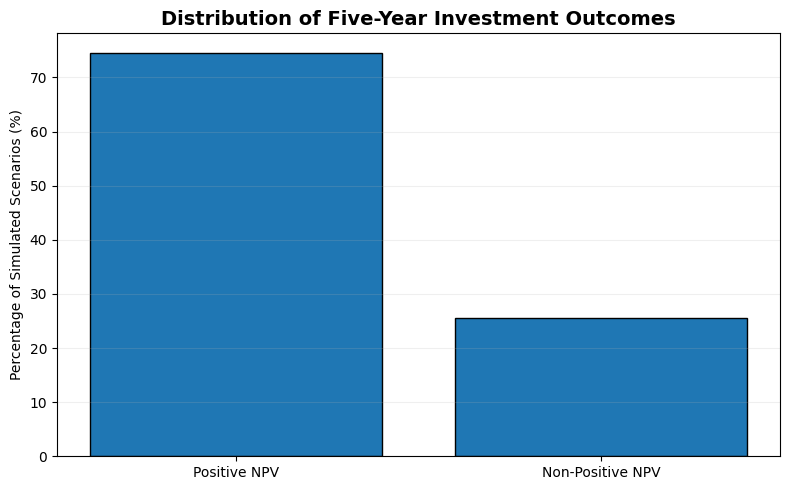

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    financial_summary["Financial Outcome"],
    financial_summary["Percentage (%)"],
    edgecolor="black"
)

plt.title(
    "Distribution of Five-Year Investment Outcomes",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Percentage of Simulated Scenarios (%)")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

### Interpretation

The financial-outcome classification shows the proportion of simulated scenarios producing positive and non-positive five-year NPV under the assumptions of the analytical model.

These percentages describe the behaviour of the simulation and should not be interpreted as predictions of the proportion of real-world organisations that will achieve positive returns from Zero Trust.

The analysis instead demonstrates how varying combinations of risk exposure, maturity improvement, implementation expenditure, and operational benefits can produce materially different investment outcomes.

## Step 4 Summary

Exploratory Data Analysis demonstrated substantial variation across the simulated Zero Trust scenarios in terms of maturity, cyber-risk exposure, implementation expenditure, expected loss reduction, and financial performance.

The analysis also showed that the simulation contains both favourable and unfavourable financial outcomes. These scenarios were intentionally retained because the objective of the framework is not to assume that every Zero Trust investment produces a positive return, but to evaluate the conditions under which different business-value outcomes may emerge.

The EDA therefore provides an important bridge between dataset validation and the subsequent probabilistic and predictive analyses.

The next stage applies Monte Carlo analysis to quantify uncertainty in the financial outcomes and evaluate the distribution of business value under alternative enterprise conditions.

# Step 5: Monte Carlo Simulation Analysis

Cybersecurity investment decisions involve considerable uncertainty because variables such as breach frequency, financial loss magnitude, implementation cost, operational savings, and control effectiveness cannot be predicted with complete certainty.

To incorporate this uncertainty, a Monte Carlo simulation approach was adopted. The analytical dataset contains 10,000 simulated enterprise scenarios generated from probability distributions and modelling assumptions associated with Zero Trust maturity, cybersecurity risk, investment costs, and operational benefits.

Rather than relying on a single deterministic estimate of financial return, Monte Carlo analysis evaluates the distribution of possible outcomes.

The analysis focuses primarily on:

- Five-year Net Present Value (NPV)
- Probability of positive and negative NPV
- Expected financial outcome
- Downside and upside percentiles
- Return on Investment (ROI)
- Payback Period
- Cyber-risk reduction

This approach enables the proposed decision-support framework to represent uncertainty explicitly and provides decision-makers with a range of potential financial outcomes rather than a single-point estimate.

In [20]:
# ============================================================
# STEP 5: MONTE CARLO SIMULATION ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 5.1 Monte Carlo NPV Summary
# ------------------------------------------------------------

npv = df["NPV_5Y_USD"].dropna()

mean_npv = npv.mean()
median_npv = npv.median()

p5_npv = npv.quantile(0.05)
p25_npv = npv.quantile(0.25)
p75_npv = npv.quantile(0.75)
p95_npv = npv.quantile(0.95)

prob_positive_npv = (npv > 0).mean() * 100
prob_negative_npv = (npv <= 0).mean() * 100

print("=" * 65)
print("MONTE CARLO ANALYSIS - FIVE-YEAR NPV")
print("=" * 65)

print(f"\nNumber of simulations : {len(npv):,}")

print(f"\nMean NPV              : ${mean_npv:,.2f}")
print(f"Median NPV            : ${median_npv:,.2f}")

print("\nMonte Carlo Percentiles")
print("-" * 40)

print(f"5th Percentile        : ${p5_npv:,.2f}")
print(f"25th Percentile       : ${p25_npv:,.2f}")
print(f"75th Percentile       : ${p75_npv:,.2f}")
print(f"95th Percentile       : ${p95_npv:,.2f}")

print("\nProbability Analysis")
print("-" * 40)

print(f"Positive NPV          : {prob_positive_npv:.2f}%")
print(f"Non-Positive NPV      : {prob_negative_npv:.2f}%")

MONTE CARLO ANALYSIS - FIVE-YEAR NPV

Number of simulations : 10,000

Mean NPV              : $948,033.08
Median NPV            : $266,262.91

Monte Carlo Percentiles
----------------------------------------
5th Percentile        : $-304,009.23
25th Percentile       : $-5,463.22
75th Percentile       : $889,022.93
95th Percentile       : $5,137,576.66

Probability Analysis
----------------------------------------
Positive NPV          : 74.42%
Non-Positive NPV      : 25.58%


### Interpretation

The Monte Carlo NPV analysis evaluates the range of five-year financial outcomes generated across the 10,000 simulated Zero Trust investment scenarios.

The mean represents the average simulated financial outcome, while the median provides a measure that is less sensitive to extreme observations.

The 5th and 95th percentiles provide useful lower-tail and upper-tail reference points for understanding financial uncertainty. The proportion of scenarios producing positive NPV additionally provides a model-based indication of how frequently discounted benefits exceed investment costs under the assumptions incorporated into the simulation.

These probabilities describe the behaviour of the simulation model and should not be interpreted as the empirical probability that a real organisation will achieve the same financial outcome.

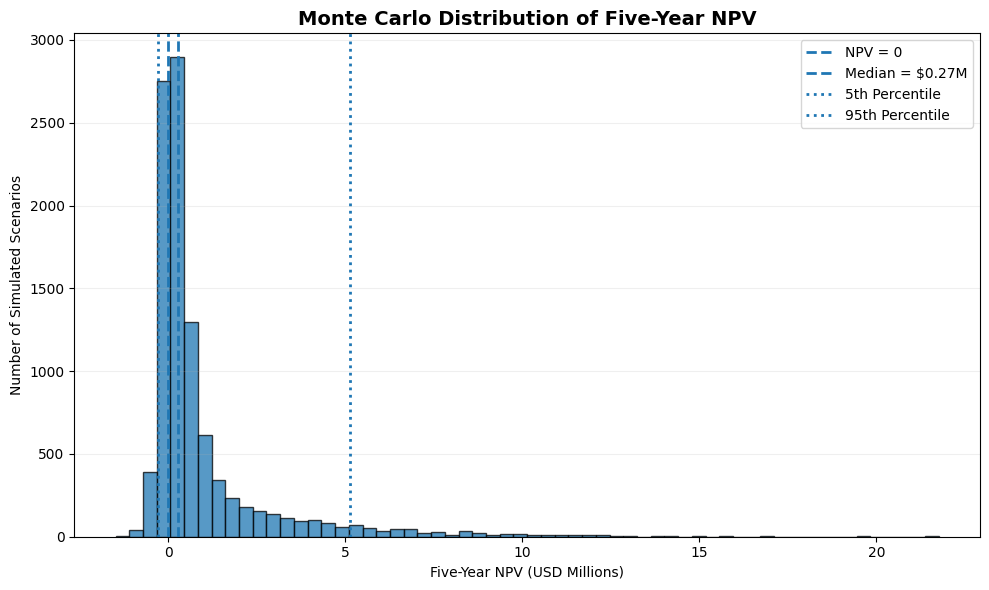

In [21]:
# ------------------------------------------------------------
# 5.2 Monte Carlo NPV Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    npv / 1_000_000,
    bins=60,
    edgecolor="black",
    alpha=0.75
)

# Zero NPV threshold
plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="NPV = 0"
)

# Median
plt.axvline(
    median_npv / 1_000_000,
    linestyle="--",
    linewidth=2,
    label=f"Median = ${median_npv/1_000_000:.2f}M"
)

# 5th percentile
plt.axvline(
    p5_npv / 1_000_000,
    linestyle=":",
    linewidth=2,
    label="5th Percentile"
)

# 95th percentile
plt.axvline(
    p95_npv / 1_000_000,
    linestyle=":",
    linewidth=2,
    label="95th Percentile"
)

plt.title(
    "Monte Carlo Distribution of Five-Year NPV",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Five-Year NPV (USD Millions)")
plt.ylabel("Number of Simulated Scenarios")

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

What this graph shows
This is much more informative than simply saying:
##NPV = $X.

My framework instead produces:
lower-tail outcome ← distribution → upper-tail outcome
and also shows the position of:
##NPV=0
which separates positive and non-positive investment outcomes.

In [22]:
# ------------------------------------------------------------
# 5.3 Monte Carlo Outcome Range
# ------------------------------------------------------------

monte_carlo_summary = pd.DataFrame({

    "Metric": [
        "Mean NPV",
        "Median NPV",
        "5th Percentile NPV",
        "25th Percentile NPV",
        "75th Percentile NPV",
        "95th Percentile NPV",
        "Probability of Positive NPV",
        "Probability of Non-Positive NPV"
    ],

    "Value": [
        mean_npv,
        median_npv,
        p5_npv,
        p25_npv,
        p75_npv,
        p95_npv,
        prob_positive_npv,
        prob_negative_npv
    ]
})

display(monte_carlo_summary)

,Metric,Value
0,Mean NPV,9.480331e+05
1,Median NPV,2.662629e+05
2,5th Percentile NPV,-3.040092e+05
3,25th Percentile NPV,-5.463215e+03
4,75th Percentile NPV,8.890229e+05
5,95th Percentile NPV,5.137577e+06
6,Probability of Positive NPV,7.442000e+01
7,Probability of Non-Positive NPV,2.558000e+01


In [23]:
# ------------------------------------------------------------
# 5.4 ROI Distribution
# ------------------------------------------------------------

roi = df["ROI_5Y"].dropna()

mean_roi = roi.mean()
median_roi = roi.median()

roi_p5 = roi.quantile(0.05)
roi_p95 = roi.quantile(0.95)

positive_roi_probability = (roi > 0).mean() * 100

print("=" * 65)
print("MONTE CARLO ROI ANALYSIS")
print("=" * 65)

print(f"\nMean ROI              : {mean_roi*100:.2f}%")
print(f"Median ROI            : {median_roi*100:.2f}%")

print(f"5th Percentile ROI    : {roi_p5*100:.2f}%")
print(f"95th Percentile ROI   : {roi_p95*100:.2f}%")

print(
    f"Probability ROI > 0   : "
    f"{positive_roi_probability:.2f}%"
)

MONTE CARLO ROI ANALYSIS

Mean ROI              : 311.24%
Median ROI            : 173.49%
5th Percentile ROI    : -81.81%
95th Percentile ROI   : 1169.83%
Probability ROI > 0   : 81.73%


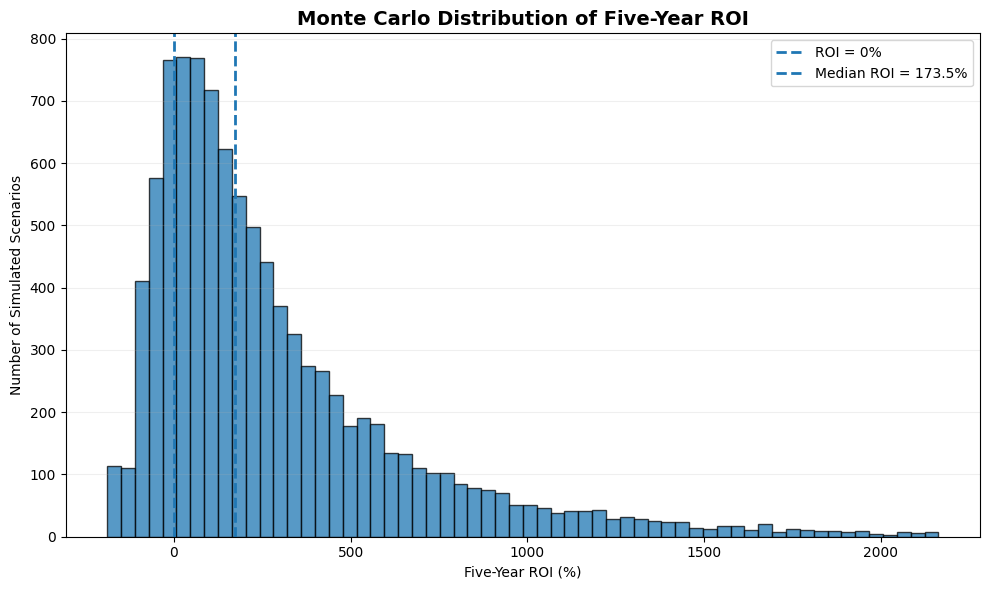

In [24]:
plt.figure(figsize=(10, 6))

# Cap only the visualisation at the 99th percentile
# so extreme values do not dominate the graph.
roi_visual = roi[
    roi <= roi.quantile(0.99)
]

plt.hist(
    roi_visual * 100,
    bins=60,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="ROI = 0%"
)

plt.axvline(
    median_roi * 100,
    linestyle="--",
    linewidth=2,
    label=f"Median ROI = {median_roi*100:.1f}%"
)

plt.title(
    "Monte Carlo Distribution of Five-Year ROI",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Five-Year ROI (%)")
plt.ylabel("Number of Simulated Scenarios")

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

Next, I examined how long the simulated investments take to recover their initial investment.

In [26]:
# ------------------------------------------------------------
# 5.5 Payback Period Analysis
# ------------------------------------------------------------

payback = df["Payback_Years"].dropna()

payback_within_1 = (payback <= 1).mean() * 100
payback_within_3 = (payback <= 3).mean() * 100
payback_within_5 = (payback <= 5).mean() * 100

print("=" * 65)
print("PAYBACK PERIOD ANALYSIS")
print("=" * 65)

print(
    f"\nMedian Payback Period : "
    f"{payback.median():.2f} years"
)

print(
    f"Payback within 1 year : "
    f"{payback_within_1:.2f}%"
)

print(
    f"Payback within 3 years: "
    f"{payback_within_3:.2f}%"
)

print(
    f"Payback within 5 years: "
    f"{payback_within_5:.2f}%"
)

PAYBACK PERIOD ANALYSIS

Median Payback Period : 1.76 years
Payback within 1 year : 27.87%
Payback within 3 years: 70.81%
Payback within 5 years: 84.38%


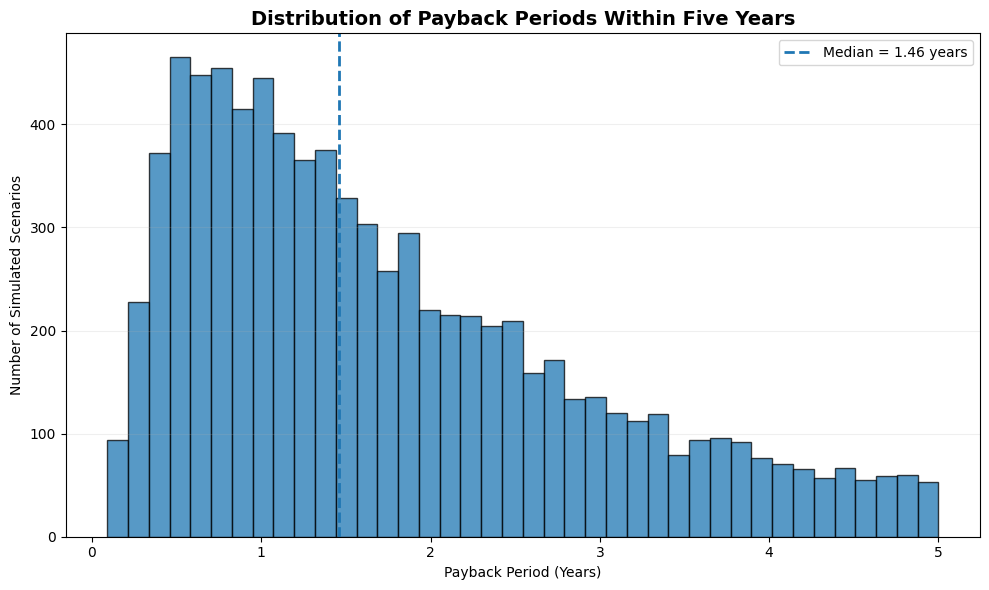

In [27]:
# Focus the visualisation on the five-year
# investment horizon used in the thesis.

payback_visual = payback[
    payback <= 5
]

plt.figure(figsize=(10, 6))

plt.hist(
    payback_visual,
    bins=40,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    payback_visual.median(),
    linestyle="--",
    linewidth=2,
    label=f"Median = {payback_visual.median():.2f} years"
)

plt.title(
    "Distribution of Payback Periods Within Five Years",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Payback Period (Years)")
plt.ylabel("Number of Simulated Scenarios")

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

The visualisation was restricted to payback periods within the five-year evaluation horizon for interpretability.

In [28]:
# ------------------------------------------------------------
# 5.6 Cyber-Risk Reduction Analysis
# ------------------------------------------------------------

df["ALE_Reduction_Percentage"] = (
    (
        df["Baseline_ALE_USD"]
        - df["Residual_ALE_USD"]
    )
    / df["Baseline_ALE_USD"]
) * 100

risk_reduction = (
    df["ALE_Reduction_Percentage"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("=" * 65)
print("CYBER-RISK REDUCTION ANALYSIS")
print("=" * 65)

print(
    f"\nMean ALE Reduction   : "
    f"{risk_reduction.mean():.2f}%"
)

print(
    f"Median ALE Reduction : "
    f"{risk_reduction.median():.2f}%"
)

print(
    f"5th Percentile       : "
    f"{risk_reduction.quantile(0.05):.2f}%"
)

print(
    f"95th Percentile      : "
    f"{risk_reduction.quantile(0.95):.2f}%"
)

CYBER-RISK REDUCTION ANALYSIS

Mean ALE Reduction   : 12.68%
Median ALE Reduction : 12.31%
5th Percentile       : 3.06%
95th Percentile      : 22.68%


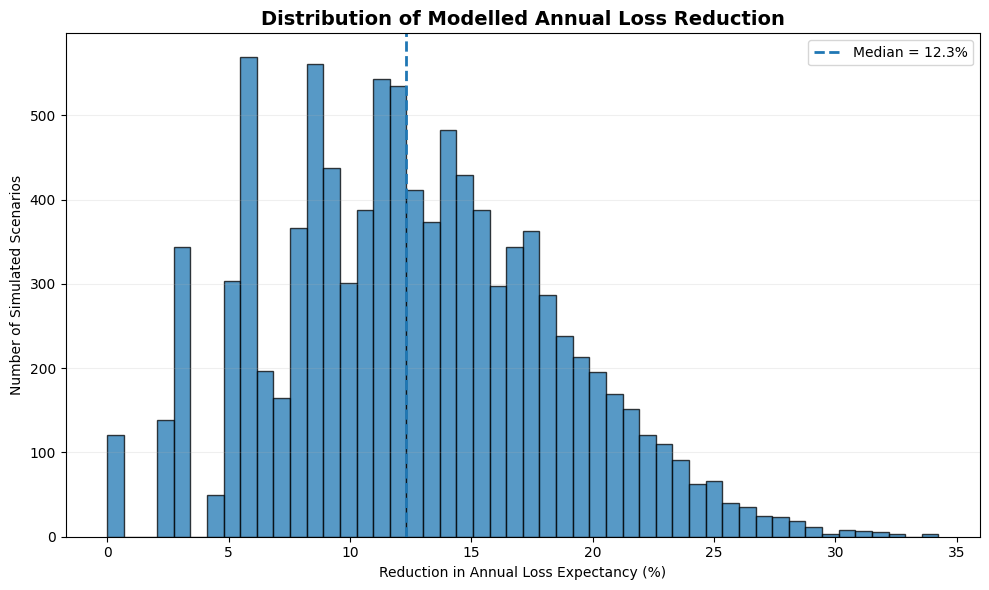

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(
    risk_reduction,
    bins=50,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    risk_reduction.median(),
    linestyle="--",
    linewidth=2,
    label=(
        f"Median = "
        f"{risk_reduction.median():.1f}%"
    )
)

plt.title(
    "Distribution of Modelled Annual Loss Reduction",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Reduction in Annual Loss Expectancy (%)")
plt.ylabel("Number of Simulated Scenarios")

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

##Summarising the distribution as three reference scenarios.

In [30]:
# ------------------------------------------------------------
# 5.7 Downside, Expected and Upside Outcomes
# ------------------------------------------------------------

scenario_summary = pd.DataFrame({

    "Scenario": [
        "Downside",
        "Expected",
        "Upside"
    ],

    "NPV_5Y_USD": [
        npv.quantile(0.05),
        npv.median(),
        npv.quantile(0.95)
    ],

    "ROI_5Y": [
        roi.quantile(0.05),
        roi.median(),
        roi.quantile(0.95)
    ]
})

scenario_summary["ROI (%)"] = (
    scenario_summary["ROI_5Y"] * 100
)

scenario_summary = scenario_summary.drop(
    columns="ROI_5Y"
)

display(
    scenario_summary.round(2)
)

,Scenario,NPV_5Y_USD,ROI (%)
0,Downside,-304009.23,-81.81
1,Expected,266262.91,173.49
2,Upside,5137576.66,1169.83


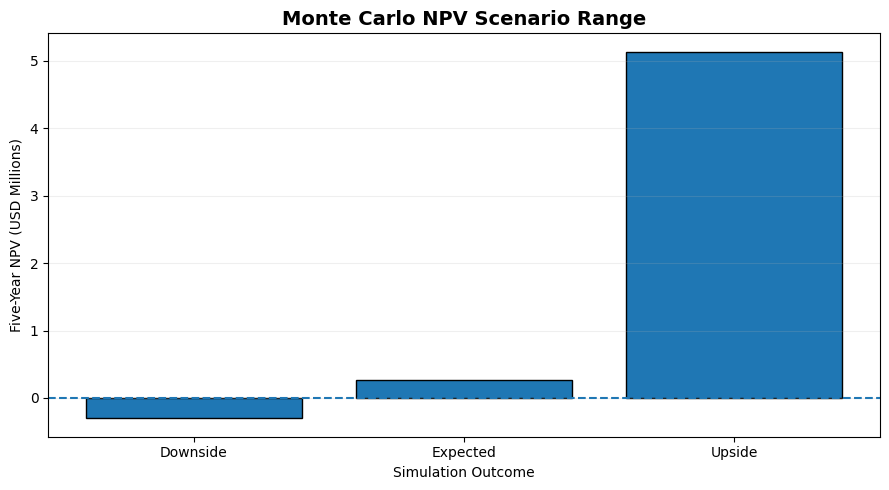

In [31]:
plt.figure(figsize=(9, 5))

plt.bar(
    scenario_summary["Scenario"],
    scenario_summary["NPV_5Y_USD"] / 1_000_000,
    edgecolor="black"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Monte Carlo NPV Scenario Range",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Five-Year NPV (USD Millions)")
plt.xlabel("Simulation Outcome")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

In [32]:
# ------------------------------------------------------------
# 5.8 Final Monte Carlo Summary
# ------------------------------------------------------------

final_mc_summary = pd.DataFrame({

    "Metric": [
        "Simulations",
        "Mean 5-Year NPV",
        "Median 5-Year NPV",
        "5th Percentile NPV",
        "95th Percentile NPV",
        "Positive NPV Scenarios",
        "Median 5-Year ROI",
        "Positive ROI Scenarios",
        "Median Payback",
        "Payback Within 5 Years",
        "Median ALE Reduction"
    ],

    "Result": [
        f"{len(df):,}",
        f"${mean_npv:,.0f}",
        f"${median_npv:,.0f}",
        f"${p5_npv:,.0f}",
        f"${p95_npv:,.0f}",
        f"{prob_positive_npv:.2f}%",
        f"{median_roi*100:.2f}%",
        f"{positive_roi_probability:.2f}%",
        f"{payback.median():.2f} years",
        f"{payback_within_5:.2f}%",
        f"{risk_reduction.median():.2f}%"
    ]
})

print("=" * 65)
print("ZERO TRUST MONTE CARLO SIMULATION SUMMARY")
print("=" * 65)

display(final_mc_summary)

ZERO TRUST MONTE CARLO SIMULATION SUMMARY


,Metric,Result
0,Simulations,"10,000"
1,Mean 5-Year NPV,"$948,033"
2,Median 5-Year NPV,"$266,263"
3,5th Percentile NPV,"$-304,009"
4,95th Percentile NPV,"$5,137,577"
5,Positive NPV Scenarios,74.42%
6,Median 5-Year ROI,173.49%
7,Positive ROI Scenarios,81.73%
8,Median Payback,1.76 years
9,Payback Within 5 Years,84.38%


## Step 5 Interpretation

Monte Carlo analysis was used to evaluate uncertainty in the financial and cybersecurity outcomes associated with the proposed Zero Trust investment framework.

Rather than producing a single deterministic estimate, the 10,000 simulated scenarios generated a distribution of possible five-year NPV, ROI, payback, and cyber-risk reduction outcomes.

The analysis included lower-tail, median, and upper-tail simulation outcomes to demonstrate the sensitivity of business value to variations in risk exposure, maturity improvement, implementation expenditure, operating costs, and operational benefits.

Negative or economically unattractive scenarios were intentionally retained because they represent meaningful conditions under which a Zero Trust investment may fail to generate sufficient financial returns within the evaluation horizon.

Consequently, the Monte Carlo analysis should be interpreted as a model-based uncertainty assessment rather than an empirical prediction of the financial returns that any specific organisation will achieve.

The resulting distributions provide the probabilistic analytical layer required by the Zero Trust Business Value Decision Support System and establish the foundation for subsequent machine-learning analysis of the factors associated with financial outcomes.

# Step 6: Sensitivity and Correlation Analysis

Following the Monte Carlo simulation, sensitivity and correlation analysis was conducted to examine which model inputs are most strongly associated with changes in the financial value of Zero Trust investment.

While Monte Carlo simulation quantifies uncertainty in possible outcomes, sensitivity analysis provides insight into the variables that contribute most strongly to variation in those outcomes.

The primary financial outcome selected for this analysis is five-year Net Present Value (NPV), as NPV incorporates investment expenditure, recurring benefits, operating costs, the evaluation horizon, and the time value of money.

The analysis focuses on upstream model inputs including:

- Organisation size
- Current Zero Trust maturity
- Target Zero Trust maturity
- Maturity improvement
- Single Loss Expectancy (SLE)
- Loss Event Frequency (LEF)
- Breach likelihood reduction
- Breach impact reduction
- Implementation cost
- Annual operating expenditure
- MTTR improvement
- Discount rate

Derived variables that directly contain or mathematically determine NPV are excluded from the main driver analysis to reduce the risk of circular interpretation and target leakage.

The analysis consists of correlation analysis, ranked sensitivity assessment, visualisation of the strongest NPV relationships, and maturity-based financial comparison.

In [33]:
# ============================================================
# STEP 6: SENSITIVITY AND CORRELATION ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 6.1 Select upstream analytical variables
# ------------------------------------------------------------

sensitivity_variables = [
    "Employees",
    "Current_Maturity",
    "Target_Maturity",
    "Maturity_Improvement",
    "SLE_USD",
    "LEF",
    "Breach_Likelihood_Reduction",
    "Breach_Impact_Reduction",
    "Implementation_Cost_USD",
    "Annual_OpEx_USD",
    "MTTR_Improvement",
    "Discount_Rate",
    "NPV_5Y_USD"
]

sensitivity_df = df[sensitivity_variables].copy()

print("=" * 65)
print("SENSITIVITY ANALYSIS DATASET")
print("=" * 65)

print(
    f"\nNumber of scenarios : "
    f"{sensitivity_df.shape[0]:,}"
)

print(
    f"Number of variables : "
    f"{sensitivity_df.shape[1]}"
)

display(sensitivity_df.head())

SENSITIVITY ANALYSIS DATASET

Number of scenarios : 10,000
Number of variables : 13


,Employees,Current_Maturity,Target_Maturity,Maturity_Improvement,SLE_USD,LEF,Breach_Likelihood_Reduction,Breach_Impact_Reduction,Implementation_Cost_USD,Annual_OpEx_USD,MTTR_Improvement,Discount_Rate,NPV_5Y_USD
0,507,2.8,3.4,0.6,4373735.35,0.0857,0.0511,0.0364,313875.01,49123.54,0.0594,0.0950,-194611.24
1,181,2.0,2.6,0.6,2707700.67,0.1582,0.0503,0.0391,178722.09,28594.46,0.0665,0.1372,-60681.27
2,94,2.2,2.8,0.6,13071351.00,0.2716,0.0535,0.0374,109410.18,11427.40,0.0580,0.1396,970845.67
3,518,2.0,3.2,1.2,7652538.02,0.0967,0.0945,0.0690,497420.94,72613.36,0.1110,0.0919,63903.55
4,560,1.6,2.8,1.2,1931873.55,0.1545,0.0996,0.0670,513520.89,47695.29,0.1155,0.1234,-205335.51


In [34]:
# ------------------------------------------------------------
# 6.2 Pearson Correlation Matrix
# ------------------------------------------------------------

correlation_matrix = (
    sensitivity_df
    .corr(method="pearson")
)

print("=" * 65)
print("PEARSON CORRELATION MATRIX")
print("=" * 65)

display(
    correlation_matrix.round(3)
)

PEARSON CORRELATION MATRIX


,Employees,Current_Maturity,Target_Maturity,Maturity_Improvement,SLE_USD,LEF,Breach_Likelihood_Reduction,Breach_Impact_Reduction,Implementation_Cost_USD,Annual_OpEx_USD,MTTR_Improvement,Discount_Rate,NPV_5Y_USD
Employees,1.000,-0.014,-0.013,0.001,0.005,-0.001,0.003,0.000,0.655,0.632,0.000,-0.008,0.746
Current_Maturity,-0.014,1.000,0.504,-0.501,-0.003,0.006,-0.478,-0.485,-0.130,-0.123,-0.494,-0.004,-0.172
Target_Maturity,-0.013,0.504,1.000,0.495,-0.001,-0.006,0.471,0.483,0.095,0.090,0.489,-0.016,0.147
Maturity_Improvement,0.001,-0.501,0.495,1.000,0.002,-0.012,0.952,0.972,0.226,0.214,0.987,-0.012,0.320
SLE_USD,0.005,-0.003,-0.001,0.002,1.000,0.017,0.002,0.000,0.008,0.011,0.002,-0.005,0.129
LEF,-0.001,0.006,-0.006,-0.012,0.017,1.000,-0.014,-0.008,-0.003,-0.002,-0.011,-0.002,0.079
Breach_Likelihood_Reduction,0.003,-0.478,0.471,0.952,0.002,-0.014,1.000,0.926,0.213,0.202,0.940,-0.009,0.315
Breach_Impact_Reduction,0.000,-0.485,0.483,0.972,0.000,-0.008,0.926,1.000,0.221,0.209,0.961,-0.010,0.313
Implementation_Cost_USD,0.655,-0.130,0.095,0.226,0.008,-0.003,0.213,0.221,1.000,0.966,0.221,-0.001,0.488
Annual_OpEx_USD,0.632,-0.123,0.090,0.214,0.011,-0.002,0.202,0.209,0.966,1.000,0.210,-0.002,0.463


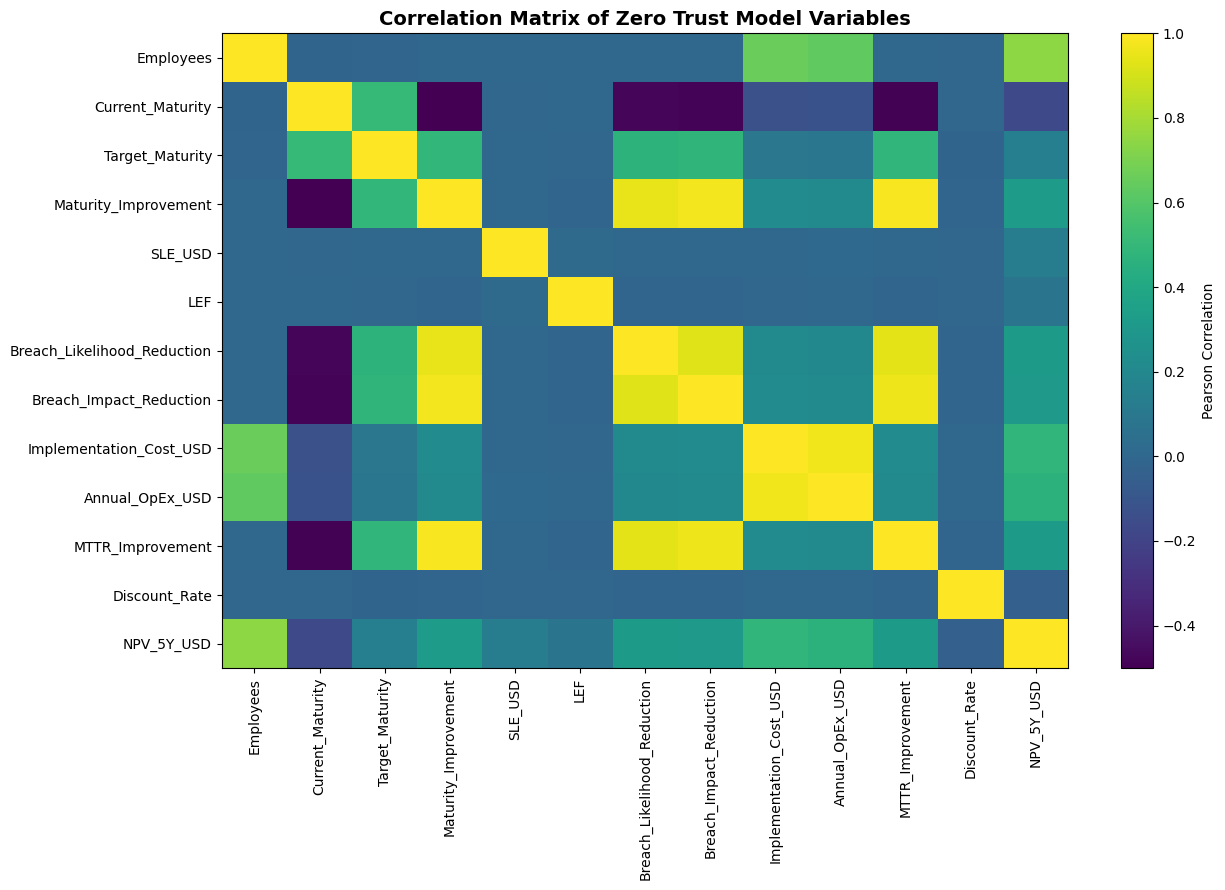

In [35]:
# ------------------------------------------------------------
# 6.3 Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(13, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Pearson Correlation"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title(
    "Correlation Matrix of Zero Trust Model Variables",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [36]:
# ------------------------------------------------------------
# 6.4 Correlation with Five-Year NPV
# ------------------------------------------------------------

npv_correlations = (
    correlation_matrix["NPV_5Y_USD"]
    .drop("NPV_5Y_USD")
    .sort_values()
)

npv_correlation_table = pd.DataFrame({
    "Variable": npv_correlations.index,
    "Correlation_with_NPV": npv_correlations.values
})

npv_correlation_table["Absolute_Correlation"] = (
    npv_correlation_table[
        "Correlation_with_NPV"
    ].abs()
)

npv_correlation_table = (
    npv_correlation_table
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

print("=" * 65)
print("VARIABLE ASSOCIATION WITH FIVE-YEAR NPV")
print("=" * 65)

display(
    npv_correlation_table.round(3)
)

VARIABLE ASSOCIATION WITH FIVE-YEAR NPV


,Variable,Correlation_with_NPV,Absolute_Correlation
11,Employees,0.746,0.746
10,Implementation_Cost_USD,0.488,0.488
9,Annual_OpEx_USD,0.463,0.463
8,Maturity_Improvement,0.320,0.320
7,MTTR_Improvement,0.315,0.315
6,Breach_Likelihood_Reduction,0.315,0.315
5,Breach_Impact_Reduction,0.313,0.313
0,Current_Maturity,-0.172,0.172
4,Target_Maturity,0.147,0.147
3,SLE_USD,0.129,0.129


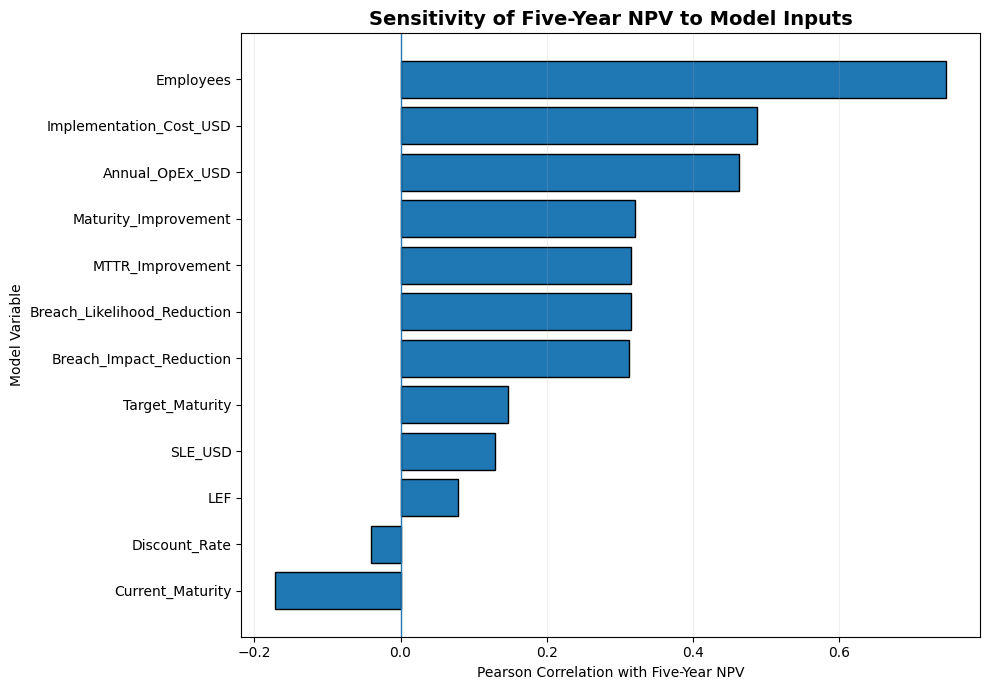

In [37]:
# Sort for horizontal visualisation
plot_data = npv_correlation_table.sort_values(
    "Correlation_with_NPV"
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Variable"],
    plot_data["Correlation_with_NPV"],
    edgecolor="black"
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Sensitivity of Five-Year NPV to Model Inputs",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Pearson Correlation with Five-Year NPV"
)

plt.ylabel(
    "Model Variable"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

### Interpretation

The correlation analysis evaluates the direction and strength of linear association between the selected model inputs and five-year NPV.

Variables with positive correlation coefficients are associated with increasing NPV within the simulated scenarios, while negative coefficients indicate an inverse relationship with NPV.

The absolute magnitude of each coefficient provides an initial indication of the relative strength of the relationship. However, these results should not be interpreted as causal estimates because the observations are generated by the simulation framework and several inputs interact within the underlying financial equations.

The correlation analysis therefore provides an initial screening of potential business-value drivers that can subsequently be compared with machine-learning feature importance and SHAP analysis.

In [38]:
# ------------------------------------------------------------
# 6.5 Spearman Rank Correlation with NPV
# ------------------------------------------------------------

spearman_matrix = (
    sensitivity_df
    .corr(method="spearman")
)

spearman_npv = (
    spearman_matrix["NPV_5Y_USD"]
    .drop("NPV_5Y_USD")
)

spearman_table = pd.DataFrame({
    "Variable": spearman_npv.index,
    "Spearman_Correlation": spearman_npv.values
})

spearman_table["Absolute_Correlation"] = (
    spearman_table[
        "Spearman_Correlation"
    ].abs()
)

spearman_table = (
    spearman_table
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

print("=" * 65)
print("SPEARMAN SENSITIVITY ANALYSIS")
print("=" * 65)

display(
    spearman_table.round(3)
)

SPEARMAN SENSITIVITY ANALYSIS


,Variable,Spearman_Correlation,Absolute_Correlation
0,Employees,0.491,0.491
3,Maturity_Improvement,0.430,0.430
7,Breach_Impact_Reduction,0.427,0.427
10,MTTR_Improvement,0.426,0.426
6,Breach_Likelihood_Reduction,0.425,0.425
8,Implementation_Cost_USD,0.309,0.309
9,Annual_OpEx_USD,0.291,0.291
4,SLE_USD,0.276,0.276
5,LEF,0.240,0.240
1,Current_Maturity,-0.218,0.218


In [39]:
# ------------------------------------------------------------
# 6.6 Pearson vs Spearman Comparison
# ------------------------------------------------------------

pearson_results = (
    correlation_matrix["NPV_5Y_USD"]
    .drop("NPV_5Y_USD")
)

spearman_results = (
    spearman_matrix["NPV_5Y_USD"]
    .drop("NPV_5Y_USD")
)

correlation_comparison = pd.DataFrame({
    "Pearson": pearson_results,
    "Spearman": spearman_results
})

correlation_comparison["Mean_Absolute_Association"] = (
    (
        correlation_comparison["Pearson"].abs()
        +
        correlation_comparison["Spearman"].abs()
    ) / 2
)

correlation_comparison = (
    correlation_comparison
    .sort_values(
        "Mean_Absolute_Association",
        ascending=False
    )
)

display(
    correlation_comparison.round(3)
)

,Pearson,Spearman,Mean_Absolute_Association
Employees,0.746,0.491,0.618
Implementation_Cost_USD,0.488,0.309,0.398
Annual_OpEx_USD,0.463,0.291,0.377
Maturity_Improvement,0.320,0.430,0.375
MTTR_Improvement,0.315,0.426,0.371
Breach_Likelihood_Reduction,0.315,0.425,0.370
Breach_Impact_Reduction,0.313,0.427,0.370
SLE_USD,0.129,0.276,0.202
Current_Maturity,-0.172,-0.218,0.195
Target_Maturity,0.147,0.204,0.176


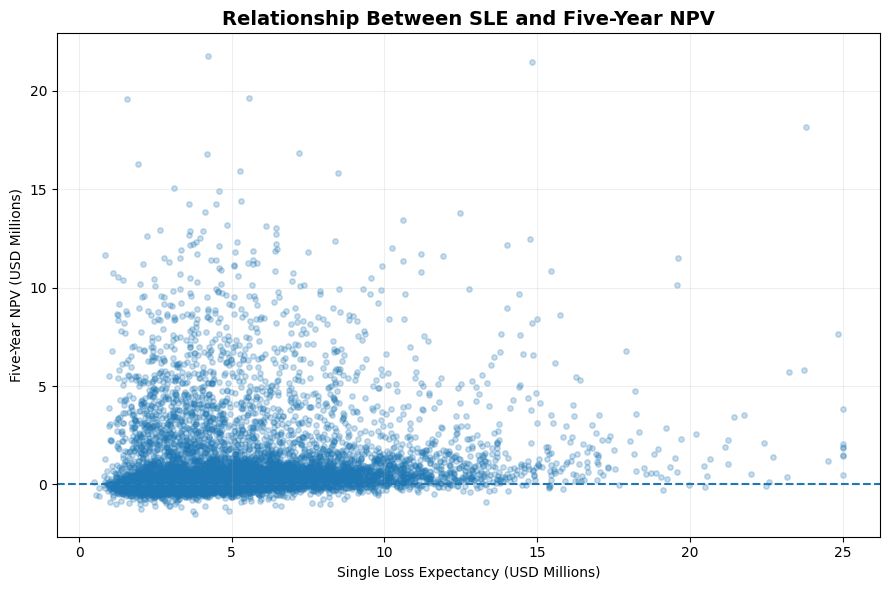

In [40]:
# ------------------------------------------------------------
# 6.7 Relationship Between SLE and NPV
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    df["SLE_USD"] / 1_000_000,
    df["NPV_5Y_USD"] / 1_000_000,
    alpha=0.25,
    s=15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Relationship Between SLE and Five-Year NPV",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Single Loss Expectancy (USD Millions)"
)

plt.ylabel(
    "Five-Year NPV (USD Millions)"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

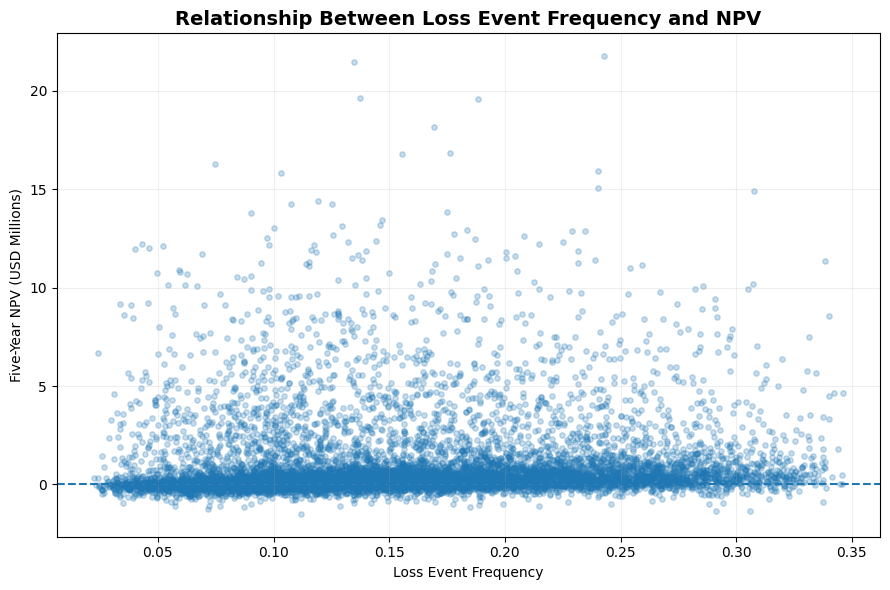

In [41]:
# ------------------------------------------------------------
# 6.8 Relationship Between LEF and NPV
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    df["LEF"],
    df["NPV_5Y_USD"] / 1_000_000,
    alpha=0.25,
    s=15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Relationship Between Loss Event Frequency and NPV",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Loss Event Frequency"
)

plt.ylabel(
    "Five-Year NPV (USD Millions)"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

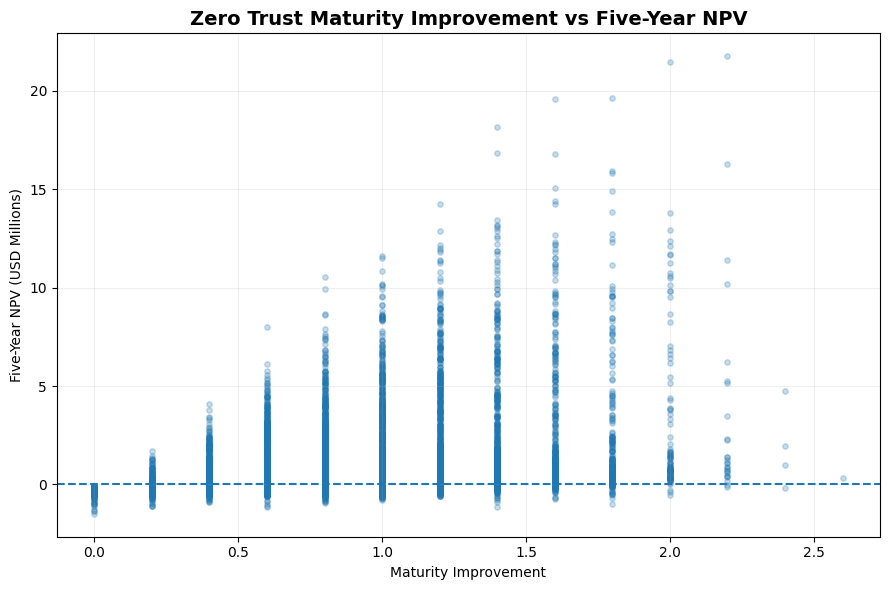

In [42]:
# ------------------------------------------------------------
# 6.9 Maturity Improvement vs NPV
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Maturity_Improvement"],
    df["NPV_5Y_USD"] / 1_000_000,
    alpha=0.25,
    s=15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Zero Trust Maturity Improvement vs Five-Year NPV",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Maturity Improvement"
)

plt.ylabel(
    "Five-Year NPV (USD Millions)"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

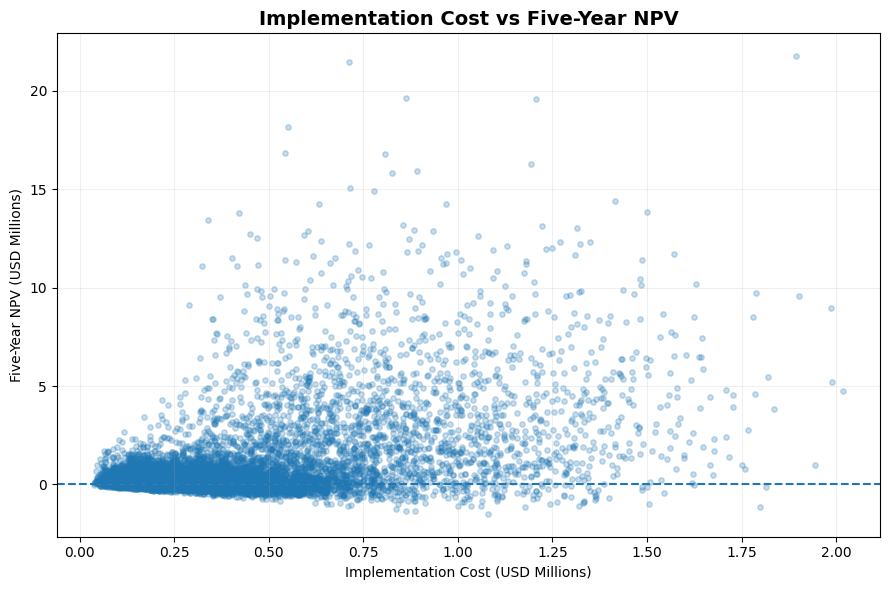

In [43]:
# ------------------------------------------------------------
# 6.10 Implementation Cost vs NPV
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Implementation_Cost_USD"] / 1_000_000,
    df["NPV_5Y_USD"] / 1_000_000,
    alpha=0.25,
    s=15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Implementation Cost vs Five-Year NPV",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Implementation Cost (USD Millions)"
)

plt.ylabel(
    "Five-Year NPV (USD Millions)"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [44]:
# ------------------------------------------------------------
# 6.11 Group Scenarios by Maturity Improvement
# ------------------------------------------------------------

df["Maturity_Improvement_Group"] = pd.cut(
    df["Maturity_Improvement"],
    bins=[
        -0.01,
        0.50,
        1.00,
        1.50,
        3.00
    ],
    labels=[
        "Minimal (0–0.5)",
        "Moderate (0.5–1.0)",
        "High (1.0–1.5)",
        "Very High (>1.5)"
    ]
)

maturity_npv_summary = (
    df.groupby(
        "Maturity_Improvement_Group",
        observed=False
    )["NPV_5Y_USD"]
    .agg([
        "count",
        "mean",
        "median"
    ])
    .reset_index()
)

display(
    maturity_npv_summary.round(2)
)

,Maturity_Improvement_Group,count,mean,median
0,Minimal (0–0.5),1706,74826.65,-55593.23
1,Moderate (0.5–1.0),5088,776405.23,235713.74
2,High (1.0–1.5),2296,1455747.90,526954.90
3,Very High (>1.5),910,2263658.82,776944.12


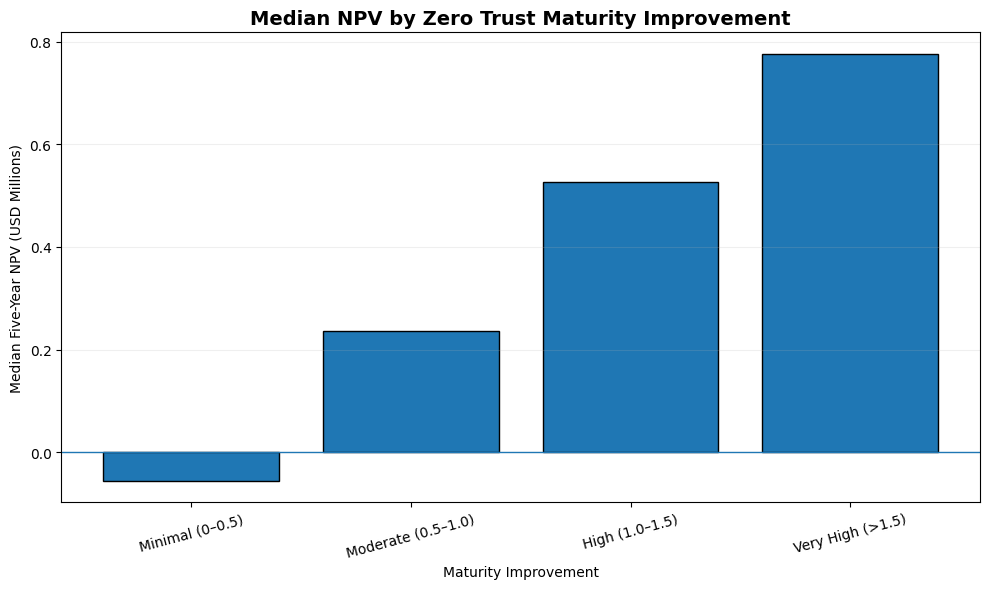

In [45]:
plt.figure(figsize=(10, 6))

plt.bar(
    maturity_npv_summary[
        "Maturity_Improvement_Group"
    ].astype(str),

    maturity_npv_summary[
        "median"
    ] / 1_000_000,

    edgecolor="black"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Median NPV by Zero Trust Maturity Improvement",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Maturity Improvement"
)

plt.ylabel(
    "Median Five-Year NPV (USD Millions)"
)

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [46]:
# ------------------------------------------------------------
# 6.12 Top Five NPV-Associated Variables
# ------------------------------------------------------------

top_5_drivers = (
    correlation_comparison
    .head(5)
    .reset_index()
    .rename(
        columns={
            "index": "Variable"
        }
    )
)

print("=" * 65)
print("TOP FIVE VARIABLES ASSOCIATED WITH NPV")
print("=" * 65)

display(
    top_5_drivers.round(3)
)

TOP FIVE VARIABLES ASSOCIATED WITH NPV


,Variable,Pearson,Spearman,Mean_Absolute_Association
0,Employees,0.746,0.491,0.618
1,Implementation_Cost_USD,0.488,0.309,0.398
2,Annual_OpEx_USD,0.463,0.291,0.377
3,Maturity_Improvement,0.320,0.430,0.375
4,MTTR_Improvement,0.315,0.426,0.371


## Step 6 Interpretation

Sensitivity and correlation analysis was conducted to identify the model inputs most strongly associated with variation in five-year NPV.

Both Pearson and Spearman correlation coefficients were examined. Pearson correlation provided an indication of linear association, while Spearman correlation provided a complementary rank-based assessment that is less dependent on linearity.

The analysis focused primarily on upstream organisational, cybersecurity-risk, maturity, cost, and control-effectiveness variables. Direct mathematical descendants of the financial target were excluded from the main driver analysis to reduce circular interpretation.

The resulting rankings provide an initial indication of the variables associated with variation in modelled Zero Trust business value. However, correlation does not establish causation, particularly within a simulation-based dataset in which relationships are partly determined by the assumptions and equations used to construct the model.

The sensitivity findings therefore serve two purposes. First, they provide interpretable evidence regarding the behaviour of the proposed financial framework. Second, they establish a baseline against which feature importance from subsequent machine-learning models can be compared.

# Step 7: Machine Learning Model Development

Following exploratory, Monte Carlo, and sensitivity analysis, supervised machine-learning regression models were developed to examine whether five-year Zero Trust Net Present Value (NPV) could be estimated from upstream organisational, cybersecurity-risk, maturity, and investment characteristics.

Two ensemble regression algorithms were selected:

1. Random Forest Regressor
2. Gradient Boosting Regressor

Random Forest combines multiple decision trees through bootstrap aggregation and random feature selection, while Gradient Boosting sequentially constructs weak learners to reduce prediction errors from preceding models.

Five-year NPV was selected as the prediction target because it provides an integrated financial measure incorporating investment expenditure, recurring benefits, operating costs, discounting, and the five-year evaluation horizon.

A 70:30 train-test split was applied, with 70% of observations used for model training and the remaining 30% retained as unseen test data.

Model performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

Particular attention was given to target leakage. Variables that directly contain or mathematically determine NPV, including Net Annual Benefit, Gross Annual Benefit, Avoided Loss, ROI, IRR and Payback Period, were excluded from the predictive feature set.

The objective is not to reproduce the financial formula mechanically, but to investigate whether underlying enterprise, maturity, cyber-risk, and investment characteristics can explain variation in modelled Zero Trust business value.

In [47]:
# ============================================================
# STEP 7: MACHINE LEARNING MODEL DEVELOPMENT
# ============================================================

# ------------------------------------------------------------
# 7.1 Import Machine Learning Libraries
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Define Predictive Features
# ------------------------------------------------------------

features = [

    # Organisational characteristics
    "Employees",

    # Zero Trust maturity
    "Current_Maturity",
    "Target_Maturity",
    "Maturity_Improvement",

    # Cyber-risk characteristics
    "SLE_USD",
    "LEF",

    # Modelled Zero Trust effectiveness
    "Breach_Likelihood_Reduction",
    "Breach_Impact_Reduction",
    "MTTR_Improvement",

    # Investment characteristics
    "Implementation_Cost_USD",
    "Annual_OpEx_USD",

    # Financial assumption
    "Discount_Rate"
]


target = "NPV_5Y_USD"


X = df[features].copy()
y = df[target].copy()


print("=" * 65)
print("MACHINE LEARNING DATASET")
print("=" * 65)

print(f"\nNumber of observations : {X.shape[0]:,}")
print(f"Number of predictors   : {X.shape[1]}")
print(f"Prediction target      : {target}")

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

display(X.head())

MACHINE LEARNING DATASET

Number of observations : 10,000
Number of predictors   : 12
Prediction target      : NPV_5Y_USD


,Employees,Current_Maturity,Target_Maturity,Maturity_Improvement,SLE_USD,LEF,Breach_Likelihood_Reduction,Breach_Impact_Reduction,MTTR_Improvement,Implementation_Cost_USD,Annual_OpEx_USD,Discount_Rate
0,507,2.8,3.4,0.6,4373735.35,0.0857,0.0511,0.0364,0.0594,313875.01,49123.54,0.0950
1,181,2.0,2.6,0.6,2707700.67,0.1582,0.0503,0.0391,0.0665,178722.09,28594.46,0.1372
2,94,2.2,2.8,0.6,13071351.00,0.2716,0.0535,0.0374,0.0580,109410.18,11427.40,0.1396
3,518,2.0,3.2,1.2,7652538.02,0.0967,0.0945,0.0690,0.1110,497420.94,72613.36,0.0919
4,560,1.6,2.8,1.2,1931873.55,0.1545,0.0996,0.0670,0.1155,513520.89,47695.29,0.1234


Why aren't we using all 40 columns?
Because variables such as:
Net_Annual_Benefit_USD
Gross_Annual_Benefit_USD
Avoided_Loss_USD
ROI_5Y
IRR_5Y
Payback_Years

have direct mathematical relationships with NPV.
If we gave those variables to the model, it could effectively reconstruct the financial equation.
That could give you an impressive-looking:

##R^2=0.99
but it would provide weak evidence of genuine predictive learning.

In [48]:
# ------------------------------------------------------------
# 7.2 Check Missing Values
# ------------------------------------------------------------

print("=" * 65)
print("ML DATA QUALITY CHECK")
print("=" * 65)

print("\nMissing values in predictors:")
print(X.isnull().sum())

print(
    "\nMissing values in target:",
    y.isnull().sum()
)

ML DATA QUALITY CHECK

Missing values in predictors:
Employees                      0
Current_Maturity               0
Target_Maturity                0
Maturity_Improvement           0
SLE_USD                        0
LEF                            0
Breach_Likelihood_Reduction    0
Breach_Impact_Reduction        0
MTTR_Improvement               0
Implementation_Cost_USD        0
Annual_OpEx_USD                0
Discount_Rate                  0
dtype: int64

Missing values in target: 0


In [49]:
# ------------------------------------------------------------
# 7.3 Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.30,

    random_state=42
)


print("=" * 65)
print("TRAIN-TEST SPLIT")
print("=" * 65)

print(
    f"\nTraining observations : "
    f"{len(X_train):,}"
)

print(
    f"Testing observations  : "
    f"{len(X_test):,}"
)

print(
    f"\nTraining proportion   : "
    f"{len(X_train)/len(X)*100:.1f}%"
)

print(
    f"Testing proportion    : "
    f"{len(X_test)/len(X)*100:.1f}%"
)

TRAIN-TEST SPLIT

Training observations : 7,000
Testing observations  : 3,000

Training proportion   : 70.0%
Testing proportion    : 30.0%


### Train-Test Split

The dataset was randomly divided into training and testing subsets using a 70:30 split.

A total of 7,000 simulated scenarios were used to train the machine-learning models, while 3,000 observations were retained as unseen test data.

A fixed random state of 42 was used to ensure reproducibility of the experimental results.

The test dataset was not used during model fitting, allowing model performance to be evaluated against previously unseen simulated scenarios.

In [50]:
# ------------------------------------------------------------
# 7.4 Random Forest Regression
# ------------------------------------------------------------

random_forest = RandomForestRegressor(

    n_estimators=300,

    max_depth=10,

    min_samples_split=10,

    min_samples_leaf=5,

    max_features=0.8,

    random_state=42,

    n_jobs=-1
)


# Train model
random_forest.fit(
    X_train,
    y_train
)


# Generate predictions
rf_predictions = random_forest.predict(
    X_test
)


print("Random Forest model successfully trained.")

Random Forest model successfully trained.


In [51]:
# ------------------------------------------------------------
# 7.5 Random Forest Performance
# ------------------------------------------------------------

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)


print("=" * 65)
print("RANDOM FOREST PERFORMANCE")
print("=" * 65)

print(
    f"\nMAE  : "
    f"${rf_mae:,.2f}"
)

print(
    f"RMSE : "
    f"${rf_rmse:,.2f}"
)

print(
    f"R²   : "
    f"{rf_r2:.4f}"
)

RANDOM FOREST PERFORMANCE

MAE  : $322,786.06
RMSE : $711,398.56
R²   : 0.8616


In [52]:
# ------------------------------------------------------------
# 7.6 Random Forest Overfitting Check
# ------------------------------------------------------------

rf_train_predictions = random_forest.predict(
    X_train
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions
)

rf_test_r2 = r2_score(
    y_test,
    rf_predictions
)


print("=" * 65)
print("RANDOM FOREST GENERALISATION CHECK")
print("=" * 65)

print(
    f"\nTraining R² : "
    f"{rf_train_r2:.4f}"
)

print(
    f"Testing R²  : "
    f"{rf_test_r2:.4f}"
)

print(
    f"Difference  : "
    f"{rf_train_r2-rf_test_r2:.4f}"
)

RANDOM FOREST GENERALISATION CHECK

Training R² : 0.9308
Testing R²  : 0.8616
Difference  : 0.0691


In [53]:
# ------------------------------------------------------------
# 7.7 Gradient Boosting Regression
# ------------------------------------------------------------

gradient_boosting = GradientBoostingRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=3,

    min_samples_split=10,

    min_samples_leaf=5,

    subsample=0.8,

    random_state=42
)


gradient_boosting.fit(
    X_train,
    y_train
)


gb_predictions = gradient_boosting.predict(
    X_test
)


print(
    "Gradient Boosting model successfully trained."
)

Gradient Boosting model successfully trained.


##Explanation Unlike Random Forest, which trains many trees largely independently, Gradient Boosting builds trees sequentially.Each new tree attempts to improve the errors produced by the previous trees.
    learning_rate=0.05:controls how strongly each tree contributes.
    max_depth=3:keeps individual trees relatively simple.
    subsample=0.8:means each boosting stage uses 80% of the training observations, introducing additional randomness that can improve generalisation.

In [54]:
# ------------------------------------------------------------
# 7.8 Gradient Boosting Performance
# ------------------------------------------------------------

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)


print("=" * 65)
print("GRADIENT BOOSTING PERFORMANCE")
print("=" * 65)

print(
    f"\nMAE  : "
    f"${gb_mae:,.2f}"
)

print(
    f"RMSE : "
    f"${gb_rmse:,.2f}"
)

print(
    f"R²   : "
    f"{gb_r2:.4f}"
)

GRADIENT BOOSTING PERFORMANCE

MAE  : $332,333.11
RMSE : $707,671.73
R²   : 0.8631


In [55]:
# ------------------------------------------------------------
# 7.9 Gradient Boosting Overfitting Check
# ------------------------------------------------------------

gb_train_predictions = gradient_boosting.predict(
    X_train
)

gb_train_r2 = r2_score(
    y_train,
    gb_train_predictions
)


print("=" * 65)
print("GRADIENT BOOSTING GENERALISATION CHECK")
print("=" * 65)

print(
    f"\nTraining R² : "
    f"{gb_train_r2:.4f}"
)

print(
    f"Testing R²  : "
    f"{gb_r2:.4f}"
)

print(
    f"Difference  : "
    f"{gb_train_r2-gb_r2:.4f}"
)

GRADIENT BOOSTING GENERALISATION CHECK

Training R² : 0.9074
Testing R²  : 0.8631
Difference  : 0.0444


In [56]:
# ------------------------------------------------------------
# 7.10 Model Comparison
# ------------------------------------------------------------

model_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE_USD": [
        rf_mae,
        gb_mae
    ],

    "RMSE_USD": [
        rf_rmse,
        gb_rmse
    ],

    "R2": [
        rf_r2,
        gb_r2
    ]
})


model_comparison = (
    model_comparison
    .sort_values(
        "R2",
        ascending=False
    )
)


print("=" * 65)
print("MACHINE LEARNING MODEL COMPARISON")
print("=" * 65)

display(
    model_comparison.round({
        "MAE_USD": 2,
        "RMSE_USD": 2,
        "R2": 4
    })
)

MACHINE LEARNING MODEL COMPARISON


,Model,MAE_USD,RMSE_USD,R2
1,Gradient Boosting,332333.11,707671.73,0.8631
0,Random Forest,322786.06,711398.56,0.8616


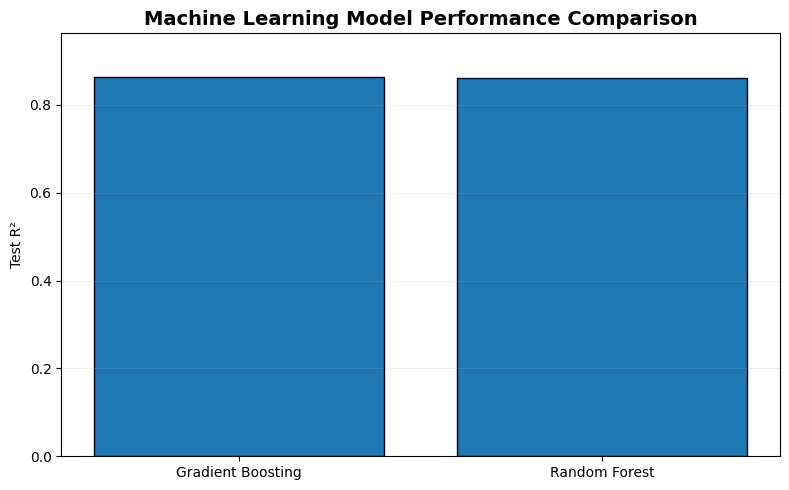

In [57]:
# ------------------------------------------------------------
# 7.11 Model R² Comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2"],
    edgecolor="black"
)

plt.title(
    "Machine Learning Model Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Test R²")

plt.ylim(
    0,
    max(model_comparison["R2"]) + 0.10
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

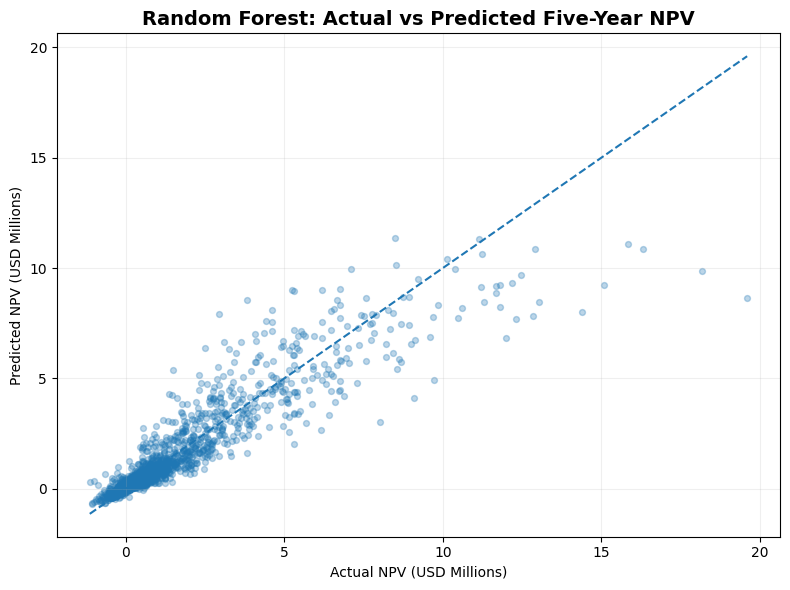

In [58]:
# ------------------------------------------------------------
# 7.12 Random Forest: Actual vs Predicted NPV
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test / 1_000_000,
    rf_predictions / 1_000_000,
    alpha=0.3,
    s=18
)

minimum = min(
    y_test.min(),
    rf_predictions.min()
) / 1_000_000

maximum = max(
    y_test.max(),
    rf_predictions.max()
) / 1_000_000


plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title(
    "Random Forest: Actual vs Predicted Five-Year NPV",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Actual NPV (USD Millions)"
)

plt.ylabel(
    "Predicted NPV (USD Millions)"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

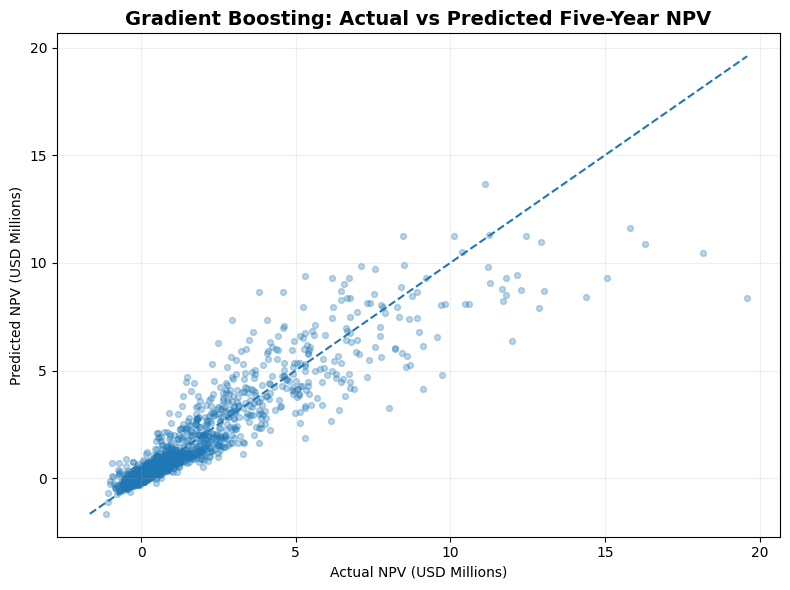

In [59]:
# ------------------------------------------------------------
# 7.13 Gradient Boosting: Actual vs Predicted NPV
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test / 1_000_000,
    gb_predictions / 1_000_000,
    alpha=0.3,
    s=18
)

minimum = min(
    y_test.min(),
    gb_predictions.min()
) / 1_000_000

maximum = max(
    y_test.max(),
    gb_predictions.max()
) / 1_000_000


plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title(
    "Gradient Boosting: Actual vs Predicted Five-Year NPV",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Actual NPV (USD Millions)"
)

plt.ylabel(
    "Predicted NPV (USD Millions)"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

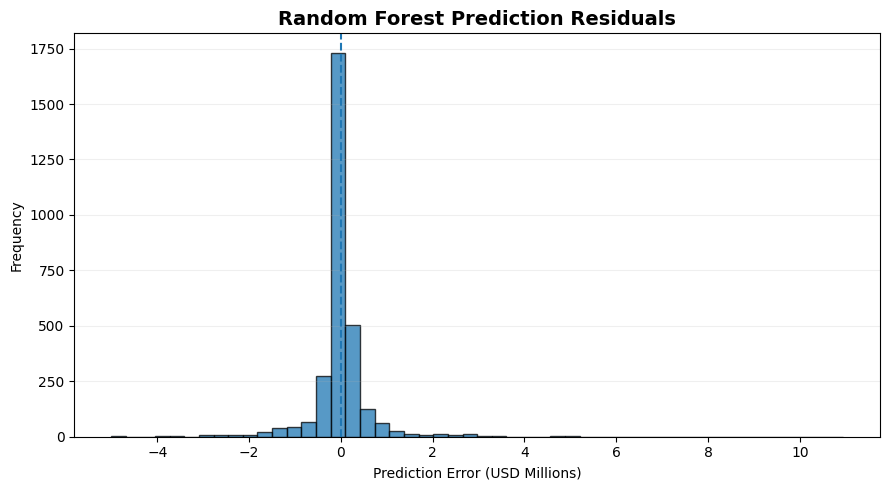

In [60]:
# ------------------------------------------------------------
# 7.14 Prediction Residuals
# ------------------------------------------------------------

rf_residuals = (
    y_test - rf_predictions
)

gb_residuals = (
    y_test - gb_predictions
)


plt.figure(figsize=(9, 5))

plt.hist(
    rf_residuals / 1_000_000,
    bins=50,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Random Forest Prediction Residuals",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Prediction Error (USD Millions)"
)

plt.ylabel("Frequency")

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

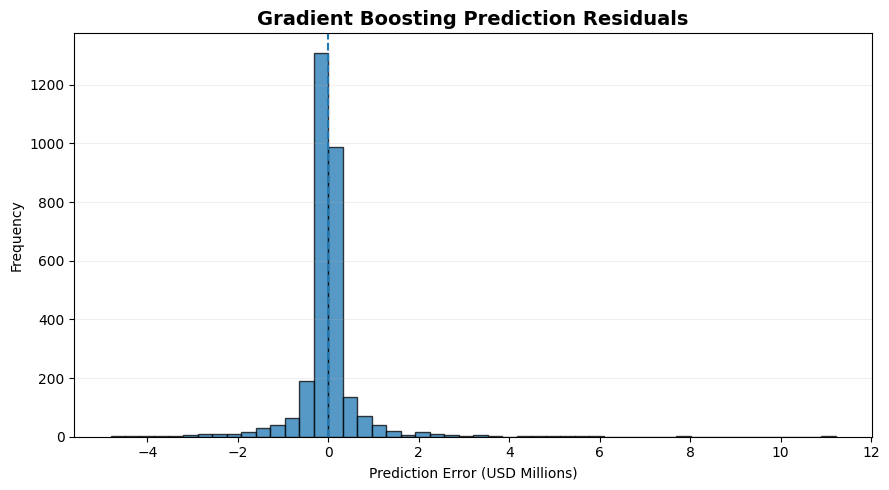

In [61]:
plt.figure(figsize=(9, 5))

plt.hist(
    gb_residuals / 1_000_000,
    bins=50,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Gradient Boosting Prediction Residuals",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Prediction Error (USD Millions)"
)

plt.ylabel("Frequency")

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [62]:
# ------------------------------------------------------------
# 7.15 Random Forest Feature Importance
# ------------------------------------------------------------

rf_importance = pd.DataFrame({

    "Feature": features,

    "Importance":
        random_forest.feature_importances_
})


rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


print("=" * 65)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 65)

display(
    rf_importance.round(4)
)

RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,Employees,0.5860
8,MTTR_Improvement,0.1427
9,Implementation_Cost_USD,0.0613
7,Breach_Impact_Reduction,0.0551
6,Breach_Likelihood_Reduction,0.0469
3,Maturity_Improvement,0.0380
4,SLE_USD,0.0223
10,Annual_OpEx_USD,0.0205
5,LEF,0.0143
11,Discount_Rate,0.0088


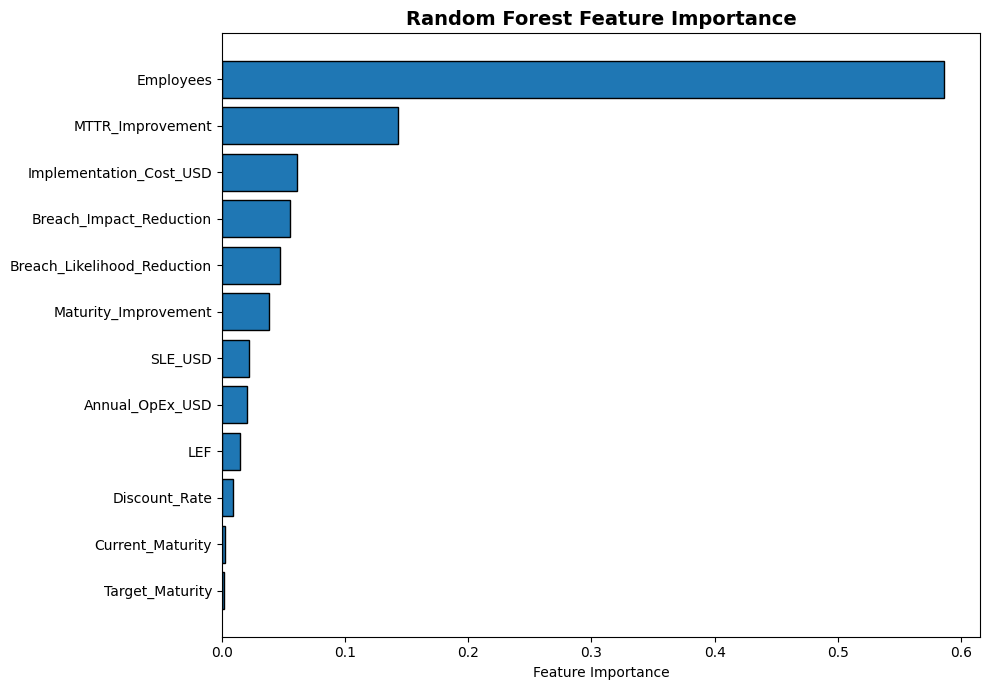

In [63]:
plot_importance = (
    rf_importance
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_importance["Feature"],
    plot_importance["Importance"],
    edgecolor="black"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Feature Importance"
)

plt.tight_layout()
plt.show()

In [64]:
# ------------------------------------------------------------
# 7.16 Gradient Boosting Feature Importance
# ------------------------------------------------------------

gb_importance = pd.DataFrame({

    "Feature": features,

    "Importance":
        gradient_boosting.feature_importances_
})


gb_importance = (
    gb_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


print("=" * 65)
print("GRADIENT BOOSTING FEATURE IMPORTANCE")
print("=" * 65)

display(
    gb_importance.round(4)
)

GRADIENT BOOSTING FEATURE IMPORTANCE


,Feature,Importance
0,Employees,0.6476
8,MTTR_Improvement,0.1685
6,Breach_Likelihood_Reduction,0.0562
7,Breach_Impact_Reduction,0.0539
4,SLE_USD,0.0208
3,Maturity_Improvement,0.0147
9,Implementation_Cost_USD,0.0122
5,LEF,0.0104
10,Annual_OpEx_USD,0.0102
11,Discount_Rate,0.0045


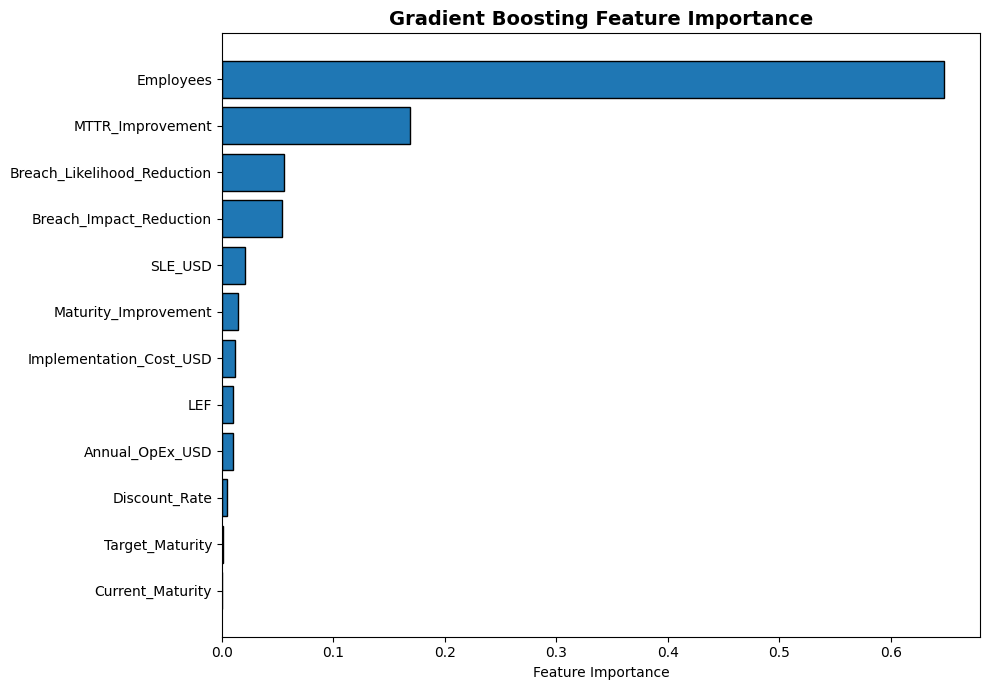

In [65]:
plot_gb_importance = (
    gb_importance
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_gb_importance["Feature"],
    plot_gb_importance["Importance"],
    edgecolor="black"
)

plt.title(
    "Gradient Boosting Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Feature Importance"
)

plt.tight_layout()
plt.show()

## Step 7 Interpretation

The machine-learning analysis evaluated whether five-year Zero Trust Net Present Value (NPV) could be estimated from upstream organisational, maturity, cybersecurity-risk, control-effectiveness, and investment variables.

Using a 70:30 train-test split, the Random Forest model achieved a test R² of 0.8616, with a Mean Absolute Error (MAE) of $322,786.06 and Root Mean Squared Error (RMSE) of $711,398.56. The model therefore explained approximately 86.16% of the variation in NPV within the unseen simulated test scenarios.

The Gradient Boosting model achieved a test R² of 0.8631, with an MAE of $332,333.11 and RMSE of $707,671.73. This indicates that approximately 86.31% of the variation in simulated test-set NPV was explained by the model.

The two algorithms therefore demonstrated broadly comparable predictive performance. Gradient Boosting produced a marginally higher R² and lower RMSE, whereas Random Forest produced a slightly lower MAE. Consequently, the results do not indicate a substantial performance advantage for either algorithm across all evaluation measures.

Generalisation was further assessed by comparing training and testing performance. Random Forest achieved a training R² of 0.9308 compared with a testing R² of 0.8616, producing a difference of 0.0691. Gradient Boosting achieved a training R² of 0.9074 and testing R² of 0.8631, producing a smaller difference of 0.0444.

The reduction in performance from training to testing data indicates some expected generalisation loss; however, both models retained substantial explanatory performance on previously unseen simulated scenarios. Gradient Boosting exhibited the smaller train-test difference.

Importantly, variables that directly or mathematically determine NPV, including Net Annual Benefit, Gross Annual Benefit, Avoided Loss, ROI, IRR, and Payback Period, were excluded from the predictive feature set. This reduced direct target leakage and made the experiment more representative of the relationship between upstream Zero Trust characteristics and modelled financial value.

Because the dataset is synthetically generated and the target variable originates from a defined financial simulation framework, the reported R² values should be interpreted as predictive performance within the simulated analytical environment rather than evidence of equivalent predictive accuracy for real-world enterprises.

Overall, the machine-learning results demonstrate that nonlinear ensemble models can capture a substantial proportion of the variation in modelled Zero Trust business value. The next stage applies explainable artificial intelligence techniques to investigate how individual variables influence these predictions.

# Step 8: Explainable Artificial Intelligence (SHAP Analysis)

Following the development and evaluation of the machine-learning models, Explainable Artificial Intelligence (XAI) was applied to investigate how individual model inputs contributed to predicted five-year Zero Trust Net Present Value (NPV).

Although predictive performance metrics such as MAE, RMSE and R² provide information about model accuracy, they do not explain the factors influencing individual predictions. This is particularly important within cybersecurity investment decision support, where decision-makers require not only a predicted financial outcome but also an interpretable explanation of the variables influencing that outcome.

SHAP (SHapley Additive exPlanations) was therefore applied to the Gradient Boosting model. SHAP is based on cooperative game theory and estimates the contribution of each input feature to a model prediction.

The analysis was conducted at two levels:

- Global explainability, identifying the variables that have the greatest overall influence on predicted NPV.
- Local explainability, demonstrating how individual variables increase or decrease the predicted NPV for a specific simulated enterprise scenario.

SHAP analysis complements the Pearson and Spearman sensitivity analysis conducted previously by providing a nonlinear, model-specific interpretation of the relationships captured by the machine-learning algorithm.

Because the underlying dataset is simulation-based, SHAP values are interpreted as explanations of model behaviour within the simulated Zero Trust business-value framework rather than causal estimates of real-world cybersecurity investment outcomes.

In [66]:
# ============================================================
# STEP 8: EXPLAINABLE AI USING SHAP
# ============================================================

# ------------------------------------------------------------
# 8.1 Install SHAP
# ------------------------------------------------------------

!pip install shap -q

In [67]:
# ------------------------------------------------------------
# Import SHAP
# ------------------------------------------------------------

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)
print("SHAP successfully imported.")

SHAP version: 0.52.0
SHAP successfully imported.


In [68]:
# ------------------------------------------------------------
# 8.2 Create SHAP Explainer
# ------------------------------------------------------------

explainer = shap.Explainer(
    gradient_boosting,
    X_train
)

print("=" * 65)
print("SHAP EXPLAINER")
print("=" * 65)

print("\nModel analysed : Gradient Boosting Regressor")
print(f"Training observations : {len(X_train):,}")
print(f"Testing observations  : {len(X_test):,}")
print(f"Number of features    : {X_test.shape[1]}")

print("\n✓ SHAP explainer successfully created.")

SHAP EXPLAINER

Model analysed : Gradient Boosting Regressor
Training observations : 7,000
Testing observations  : 3,000
Number of features    : 12

✓ SHAP explainer successfully created.


In [69]:
# ------------------------------------------------------------
# 8.3 Calculate SHAP Values
# ------------------------------------------------------------

shap_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

shap_values = explainer(
    shap_sample
)

print("=" * 65)
print("SHAP VALUE CALCULATION")
print("=" * 65)

print(
    f"\nScenarios explained : "
    f"{len(shap_sample):,}"
)

print(
    f"Features analysed   : "
    f"{shap_sample.shape[1]}"
)

print(
    "\n✓ SHAP values successfully calculated."
)

SHAP VALUE CALCULATION

Scenarios explained : 1,000
Features analysed   : 12

✓ SHAP values successfully calculated.


In [70]:
# ------------------------------------------------------------
# 8.4 Global SHAP Feature Importance
# ------------------------------------------------------------

mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_importance = pd.DataFrame({

    "Feature":
        shap_sample.columns,

    "Mean_Absolute_SHAP":
        mean_abs_shap
})


shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 65)
print("GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 65)

display(
    shap_importance.round(2)
)

GLOBAL SHAP FEATURE IMPORTANCE


,Feature,Mean_Absolute_SHAP
0,Employees,1097656.48
1,MTTR_Improvement,196593.75
2,Breach_Impact_Reduction,156879.07
3,SLE_USD,152583.12
4,Breach_Likelihood_Reduction,134576.37
5,LEF,120958.99
6,Annual_OpEx_USD,92661.33
7,Implementation_Cost_USD,72712.13
8,Maturity_Improvement,37070.68
9,Discount_Rate,26991.29


##High SHAP importance ≠ causal effect.

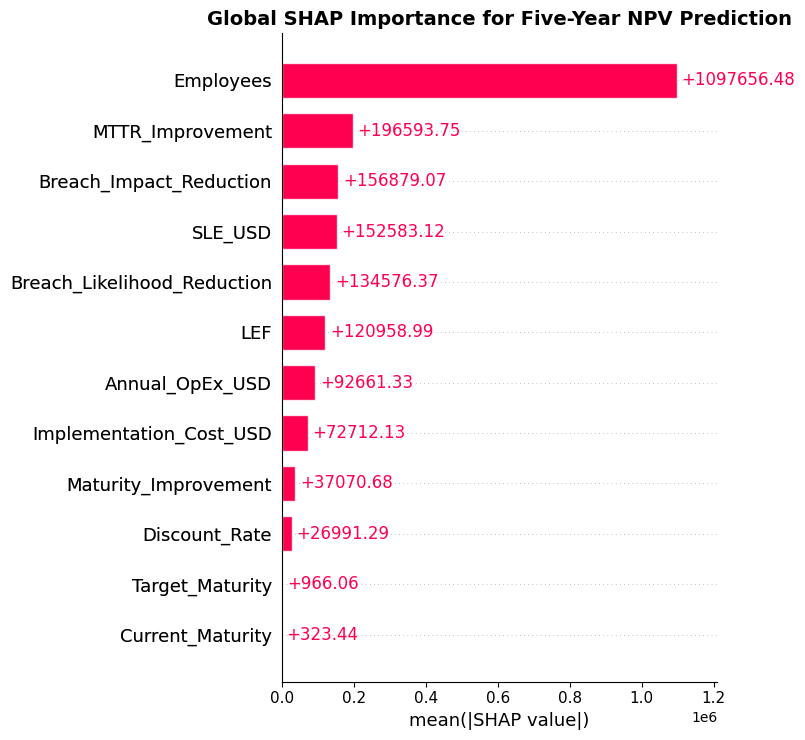

In [71]:
# ------------------------------------------------------------
# 8.5 SHAP Global Importance Plot
# ------------------------------------------------------------

plt.figure()

shap.plots.bar(
    shap_values,
    max_display=12,
    show=False
)

plt.title(
    "Global SHAP Importance for Five-Year NPV Prediction",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Global SHAP Importance

The global SHAP analysis ranks the predictive variables according to their average absolute contribution to the Gradient Boosting model's five-year NPV predictions.

Variables with larger mean absolute SHAP values exert a greater overall influence on model predictions across the sampled test scenarios.

Unlike Pearson correlation, which primarily measures linear association, SHAP can capture the contribution of variables within nonlinear relationships and interactions learned by the Gradient Boosting model.

The ranking should therefore be interpreted as model-specific predictive importance rather than evidence of causal relationships.

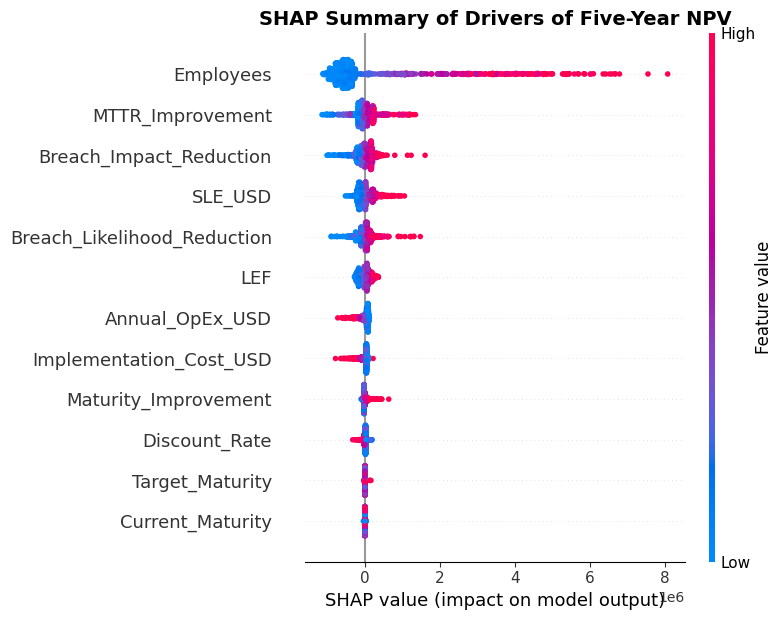

In [72]:
# ------------------------------------------------------------
# 8.6 SHAP Beeswarm Plot
# ------------------------------------------------------------

shap.plots.beeswarm(
    shap_values,
    max_display=12,
    show=False
)

plt.title(
    "SHAP Summary of Drivers of Five-Year NPV",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

##LEFT  → decrease predicted NPV
##RIGHT → increase predicted NPV
##Low feature value  → blue
##High feature value → red
##For example, if high SLE observations appear mainly on the right, that would indicate that higher SLE tends to push the model toward higher predicted NPV within the simulated framework.

In [73]:
# ------------------------------------------------------------
# 8.7 Top Five SHAP Drivers
# ------------------------------------------------------------

top_5_shap = (
    shap_importance
    .head(5)
    .copy()
)


top_5_shap["Rank"] = range(
    1,
    len(top_5_shap) + 1
)


top_5_shap = top_5_shap[
    [
        "Rank",
        "Feature",
        "Mean_Absolute_SHAP"
    ]
]


print("=" * 65)
print("TOP FIVE SHAP DRIVERS OF NPV")
print("=" * 65)

display(
    top_5_shap.round(2)
)

TOP FIVE SHAP DRIVERS OF NPV


,Rank,Feature,Mean_Absolute_SHAP
0,1,Employees,1097656.48
1,2,MTTR_Improvement,196593.75
2,3,Breach_Impact_Reduction,156879.07
3,4,SLE_USD,152583.12
4,5,Breach_Likelihood_Reduction,134576.37


Strongest SHAP driver: Employees


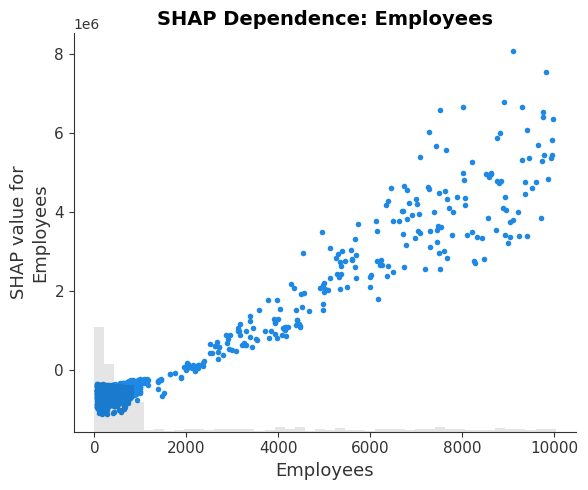

In [74]:
# ------------------------------------------------------------
# 8.8 SHAP Dependence Plot for Strongest Driver
# ------------------------------------------------------------

top_feature = shap_importance.iloc[0]["Feature"]

print(
    "Strongest SHAP driver:",
    top_feature
)


shap.plots.scatter(
    shap_values[:, top_feature],
    show=False
)

plt.title(
    f"SHAP Dependence: {top_feature}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

This graph answers:
As the value of this variable changes, how does its contribution to predicted NPV change?

This is more informative than ordinary feature importance because it shows both magnitude and direction.

Second strongest SHAP driver: MTTR_Improvement


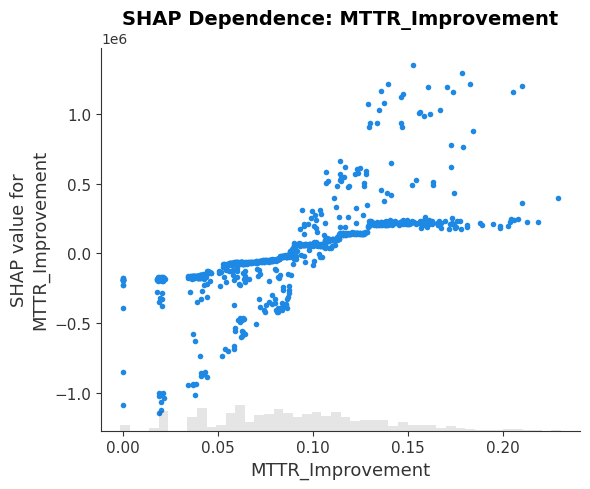

In [75]:
# ------------------------------------------------------------
# 8.9 Second Strongest SHAP Driver
# ------------------------------------------------------------

second_feature = (
    shap_importance.iloc[1]["Feature"]
)


print(
    "Second strongest SHAP driver:",
    second_feature
)


shap.plots.scatter(
    shap_values[:, second_feature],
    show=False
)

plt.title(
    f"SHAP Dependence: {second_feature}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Third strongest SHAP driver: Breach_Impact_Reduction


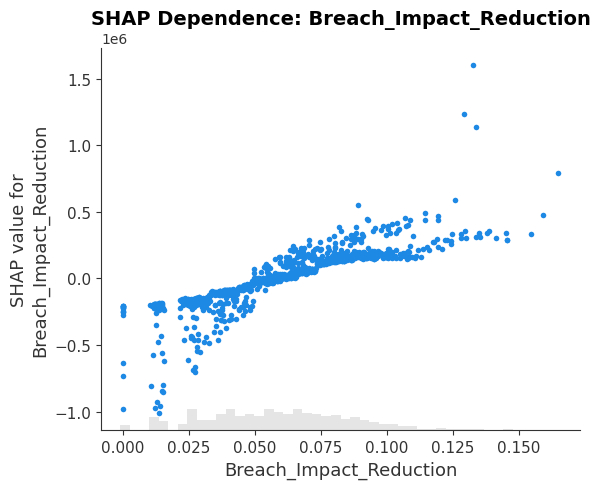

In [76]:
# ------------------------------------------------------------
# 8.10 Third Strongest SHAP Driver
# ------------------------------------------------------------

third_feature = (
    shap_importance.iloc[2]["Feature"]
)


print(
    "Third strongest SHAP driver:",
    third_feature
)


shap.plots.scatter(
    shap_values[:, third_feature],
    show=False
)

plt.title(
    f"SHAP Dependence: {third_feature}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [77]:
# ------------------------------------------------------------
# 8.11 Local SHAP Explanation
# ------------------------------------------------------------

scenario_number = 0

scenario = shap_sample.iloc[
    scenario_number
]

scenario_shap = shap_values[
    scenario_number
]


predicted_npv = gradient_boosting.predict(
    scenario.to_frame().T
)[0]


print("=" * 65)
print("INDIVIDUAL ZERO TRUST SCENARIO")
print("=" * 65)

print(
    f"\nPredicted Five-Year NPV : "
    f"${predicted_npv:,.2f}"
)

print("\nScenario Inputs:")

display(
    scenario
    .to_frame("Value")
)

INDIVIDUAL ZERO TRUST SCENARIO

Predicted Five-Year NPV : $1,865,677.01

Scenario Inputs:


,Value
Employees,7.485000e+03
Current_Maturity,2.200000e+00
Target_Maturity,2.600000e+00
Maturity_Improvement,4.000000e-01
SLE_USD,3.404597e+06
LEF,1.909000e-01
Breach_Likelihood_Reduction,3.360000e-02
Breach_Impact_Reduction,2.790000e-02
MTTR_Improvement,3.710000e-02
Implementation_Cost_USD,4.541257e+05


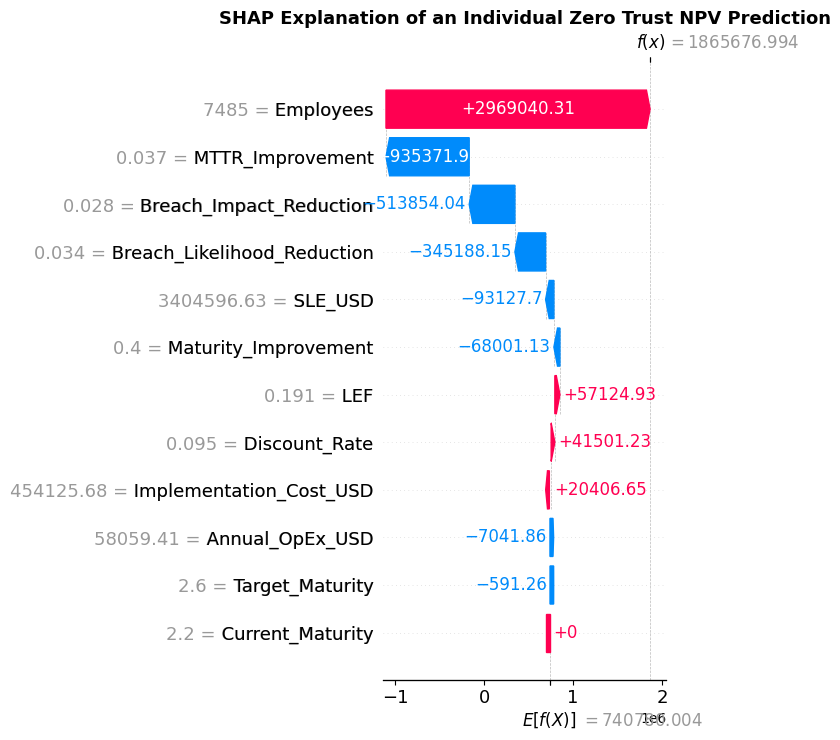

In [78]:
# ------------------------------------------------------------
# 8.12 SHAP Waterfall Plot
# ------------------------------------------------------------

shap.plots.waterfall(
    scenario_shap,
    max_display=12,
    show=False
)

plt.title(
    "SHAP Explanation of an Individual Zero Trust NPV Prediction",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [79]:
# ------------------------------------------------------------
# 8.13 Individual SHAP Contribution Table
# ------------------------------------------------------------

local_explanation = pd.DataFrame({

    "Feature":
        shap_sample.columns,

    "Feature_Value":
        scenario.values,

    "SHAP_Contribution_USD":
        scenario_shap.values
})


local_explanation[
    "Absolute_Contribution"
] = (

    local_explanation[
        "SHAP_Contribution_USD"
    ].abs()

)


local_explanation = (
    local_explanation
    .sort_values(
        "Absolute_Contribution",
        ascending=False
    )
)


print("=" * 65)
print("INDIVIDUAL PREDICTION EXPLANATION")
print("=" * 65)

display(
    local_explanation[
        [
            "Feature",
            "Feature_Value",
            "SHAP_Contribution_USD"
        ]
    ].round(2)
)

INDIVIDUAL PREDICTION EXPLANATION


,Feature,Feature_Value,SHAP_Contribution_USD
0,Employees,7485.00,2969040.31
8,MTTR_Improvement,0.04,-935371.99
7,Breach_Impact_Reduction,0.03,-513854.04
6,Breach_Likelihood_Reduction,0.03,-345188.15
4,SLE_USD,3404596.63,-93127.70
3,Maturity_Improvement,0.40,-68001.13
5,LEF,0.19,57124.93
11,Discount_Rate,0.10,41501.23
9,Implementation_Cost_USD,454125.68,20406.65
10,Annual_OpEx_USD,58059.41,-7041.86


Positive SHAP → pushes predicted NPV upward
Negative SHAP → pushes predicted NPV downward

In [80]:
# ------------------------------------------------------------
# 8.14 Verify SHAP Additive Explanation
# ------------------------------------------------------------

base_value = float(
    np.array(
        scenario_shap.base_values
    ).reshape(-1)[0]
)

total_shap = (
    scenario_shap.values.sum()
)

reconstructed_prediction = (
    base_value + total_shap
)


print("=" * 65)
print("SHAP PREDICTION VALIDATION")
print("=" * 65)

print(
    f"\nBaseline prediction       : "
    f"${base_value:,.2f}"
)

print(
    f"Total SHAP contribution   : "
    f"${total_shap:,.2f}"
)

print(
    f"Reconstructed prediction  : "
    f"${reconstructed_prediction:,.2f}"
)

print(
    f"Model prediction          : "
    f"${predicted_npv:,.2f}"
)

print(
    f"Difference                : "
    f"${abs(reconstructed_prediction-predicted_npv):,.6f}"
)

SHAP PREDICTION VALIDATION

Baseline prediction       : $740,780.00
Total SHAP contribution   : $1,124,896.99
Reconstructed prediction  : $1,865,676.99
Model prediction          : $1,865,677.01
Difference                : $0.018776


In [81]:
# ------------------------------------------------------------
# 8.15 Compare SHAP with Correlation Analysis
# ------------------------------------------------------------

shap_comparison = (
    shap_importance[
        [
            "Feature",
            "Mean_Absolute_SHAP"
        ]
    ]
    .copy()
)


correlation_for_merge = (
    correlation_comparison
    .reset_index()
    .rename(
        columns={
            "index": "Feature"
        }
    )
)


explainability_comparison = (
    shap_comparison
    .merge(
        correlation_for_merge,
        on="Feature",
        how="left"
    )
)


explainability_comparison = (
    explainability_comparison
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
)


print("=" * 65)
print("SHAP AND SENSITIVITY COMPARISON")
print("=" * 65)

display(
    explainability_comparison.round(3)
)

SHAP AND SENSITIVITY COMPARISON


,Feature,Mean_Absolute_SHAP,Pearson,Spearman,Mean_Absolute_Association
0,Employees,1097656.475,0.746,0.491,0.618
1,MTTR_Improvement,196593.745,0.315,0.426,0.371
2,Breach_Impact_Reduction,156879.069,0.313,0.427,0.370
3,SLE_USD,152583.119,0.129,0.276,0.202
4,Breach_Likelihood_Reduction,134576.366,0.315,0.425,0.370
5,LEF,120958.986,0.079,0.240,0.160
6,Annual_OpEx_USD,92661.329,0.463,0.291,0.377
7,Implementation_Cost_USD,72712.133,0.488,0.309,0.398
8,Maturity_Improvement,37070.685,0.320,0.430,0.375
9,Discount_Rate,26991.288,-0.041,-0.045,0.043


In [82]:
# ------------------------------------------------------------
# 8.16 Final Explainability Summary
# ------------------------------------------------------------

final_shap_summary = (
    shap_importance
    .head(10)
    .copy()
)

final_shap_summary.insert(
    0,
    "Rank",
    range(
        1,
        len(final_shap_summary) + 1
    )
)


print("=" * 65)
print("ZERO TRUST NPV EXPLAINABILITY SUMMARY")
print("=" * 65)

display(
    final_shap_summary.round(2)
)

ZERO TRUST NPV EXPLAINABILITY SUMMARY


,Rank,Feature,Mean_Absolute_SHAP
0,1,Employees,1097656.48
1,2,MTTR_Improvement,196593.75
2,3,Breach_Impact_Reduction,156879.07
3,4,SLE_USD,152583.12
4,5,Breach_Likelihood_Reduction,134576.37
5,6,LEF,120958.99
6,7,Annual_OpEx_USD,92661.33
7,8,Implementation_Cost_USD,72712.13
8,9,Maturity_Improvement,37070.68
9,10,Discount_Rate,26991.29


## Step 8 Interpretation: Explainable Artificial Intelligence

SHAP (SHapley Additive exPlanations) analysis was applied to the Gradient Boosting model to provide both global and local explanations of the factors influencing predicted five-year Zero Trust Net Present Value (NPV).

The global SHAP analysis identified organisation size, represented by the number of employees, as the most influential predictor. Employees produced a mean absolute SHAP value of approximately $1.10 million, substantially exceeding the contribution of the remaining predictors. This indicates that organisational scale plays a major role in the financial outcomes generated within the simulated Zero Trust business-value framework.

The strong influence of employee count is consistent with the structure of the simulation model because several operational-value components, including productivity benefits, security expenditure, incident-response costs, and compliance-related costs, scale with organisational size. Consequently, larger simulated organisations provide a greater financial base across which Zero Trust-related operational efficiencies can accumulate. This finding represents a relationship within the proposed simulation framework and should not be interpreted as evidence that organisation size independently causes higher Zero Trust returns in real-world enterprises.

The second most influential variable was MTTR Improvement, with a mean absolute SHAP contribution of approximately $196,594. The SHAP dependence analysis indicated that relatively small improvements in incident-response performance generally contributed negatively relative to the model baseline, whereas stronger improvements increasingly contributed positively to predicted NPV. This demonstrates the potential importance of operational incident-response efficiency within the modelled Zero Trust business case.

Breach Impact Reduction was the third strongest predictor, with a mean absolute SHAP contribution of approximately $156,879. Higher reductions in breach impact generally produced more positive SHAP contributions, demonstrating that reducing the financial severity of successful cyber incidents is an important component of modelled Zero Trust business value.

Single Loss Expectancy (SLE) and Breach Likelihood Reduction were also among the five most influential variables, with mean absolute SHAP values of approximately $152,583 and $134,576 respectively. Together, these findings demonstrate that the machine-learning model incorporates both organisational scale and cybersecurity-risk characteristics when estimating financial value.

Annual operating expenditure and implementation expenditure generally showed negative contributions at higher values, reflecting the financial trade-off between the cost of Zero Trust adoption and the benefits generated through risk reduction and operational efficiencies.

Current and target maturity scores exhibited relatively low direct SHAP importance. However, this should not be interpreted as evidence that Zero Trust maturity is economically irrelevant. The predictive model also contains maturity improvement and variables representing the modelled consequences of maturity improvement, including breach likelihood reduction, breach impact reduction, and MTTR improvement. Consequently, predictive importance may be attributed to these more proximal control-effectiveness variables rather than directly to the underlying maturity scores.

The SHAP dependence plots further revealed nonlinear relationships between key predictors and modelled NPV. In particular, the contribution of employee count became increasingly positive for larger simulated organisations, while stronger MTTR and breach-impact improvements generally shifted predictions toward higher financial value.

Local explainability was demonstrated using an individual simulated enterprise scenario. For the selected scenario containing 7,485 employees, the Gradient Boosting model predicted a five-year NPV of approximately $1.87 million. Employee count made the largest positive contribution to this prediction, contributing approximately $2.97 million relative to the model baseline. Other scenario-specific variables produced both positive and negative contributions, illustrating how SHAP decomposes an individual financial prediction into interpretable model components.

A negative SHAP value does not necessarily indicate that a variable is economically undesirable. Instead, it indicates that the observed value of that variable decreases the prediction relative to the model's baseline expectation for the analysed dataset.

Overall, the SHAP analysis extends the predictive modelling results by providing an interpretable explanation of the factors influencing estimated Zero Trust business value. The findings complement the earlier Pearson and Spearman sensitivity analysis while additionally capturing nonlinear and scenario-specific relationships learned by the Gradient Boosting model.

Because the analysis is based on synthetically generated scenarios, these findings explain the behaviour of the proposed analytical framework and should not be interpreted as causal estimates of financial returns across real-world enterprises.

### 8.17 Comparison of SHAP and Sensitivity Analysis

To evaluate whether the machine-learning explanations were consistent with the earlier statistical sensitivity analysis, SHAP feature importance was compared with Pearson and Spearman correlations with five-year NPV.

The three techniques provide different analytical perspectives. Pearson correlation measures linear association, Spearman correlation measures monotonic rank-based association, while SHAP measures the contribution of individual variables to predictions generated by the nonlinear Gradient Boosting model.

Consequently, differences between the rankings are not necessarily contradictory. Instead, they may indicate nonlinear relationships, interactions between variables, or differences between statistical association and model-specific predictive importance.

In [83]:
# ============================================================
# 8.17 SHAP VS SENSITIVITY ANALYSIS
# ============================================================

# Pearson correlations
pearson_compare = (
    correlation_matrix["NPV_5Y_USD"]
    .drop("NPV_5Y_USD")
    .rename("Pearson")
)

# Spearman correlations
spearman_compare = (
    spearman_matrix["NPV_5Y_USD"]
    .drop("NPV_5Y_USD")
    .rename("Spearman")
)

# SHAP importance
shap_compare = (
    shap_importance
    .set_index("Feature")["Mean_Absolute_SHAP"]
)

# Combine results
comparison_table = pd.concat(
    [
        pearson_compare,
        spearman_compare,
        shap_compare
    ],
    axis=1
)

# Keep only features used by the ML model
comparison_table = comparison_table.loc[
    comparison_table.index.intersection(features)
]

# Add absolute correlation measures
comparison_table["Abs_Pearson"] = (
    comparison_table["Pearson"].abs()
)

comparison_table["Abs_Spearman"] = (
    comparison_table["Spearman"].abs()
)

# Rank variables
comparison_table["Pearson_Rank"] = (
    comparison_table["Abs_Pearson"]
    .rank(ascending=False, method="min")
)

comparison_table["Spearman_Rank"] = (
    comparison_table["Abs_Spearman"]
    .rank(ascending=False, method="min")
)

comparison_table["SHAP_Rank"] = (
    comparison_table["Mean_Absolute_SHAP"]
    .rank(ascending=False, method="min")
)

# Sort by SHAP importance
comparison_table = comparison_table.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

print("=" * 75)
print("SENSITIVITY AND SHAP COMPARISON")
print("=" * 75)

display(
    comparison_table[
        [
            "Pearson",
            "Spearman",
            "Mean_Absolute_SHAP",
            "Pearson_Rank",
            "Spearman_Rank",
            "SHAP_Rank"
        ]
    ].round(3)
)

SENSITIVITY AND SHAP COMPARISON


,Pearson,Spearman,Mean_Absolute_SHAP,Pearson_Rank,Spearman_Rank,SHAP_Rank
Employees,0.746,0.491,1097656.475,1.0,1.0,1.0
MTTR_Improvement,0.315,0.426,196593.745,5.0,4.0,2.0
Breach_Impact_Reduction,0.313,0.427,156879.069,7.0,3.0,3.0
SLE_USD,0.129,0.276,152583.119,10.0,8.0,4.0
Breach_Likelihood_Reduction,0.315,0.425,134576.366,6.0,5.0,5.0
LEF,0.079,0.240,120958.986,11.0,9.0,6.0
Annual_OpEx_USD,0.463,0.291,92661.329,3.0,7.0,7.0
Implementation_Cost_USD,0.488,0.309,72712.133,2.0,6.0,8.0
Maturity_Improvement,0.320,0.430,37070.685,4.0,2.0,9.0
Discount_Rate,-0.041,-0.045,26991.288,12.0,12.0,10.0


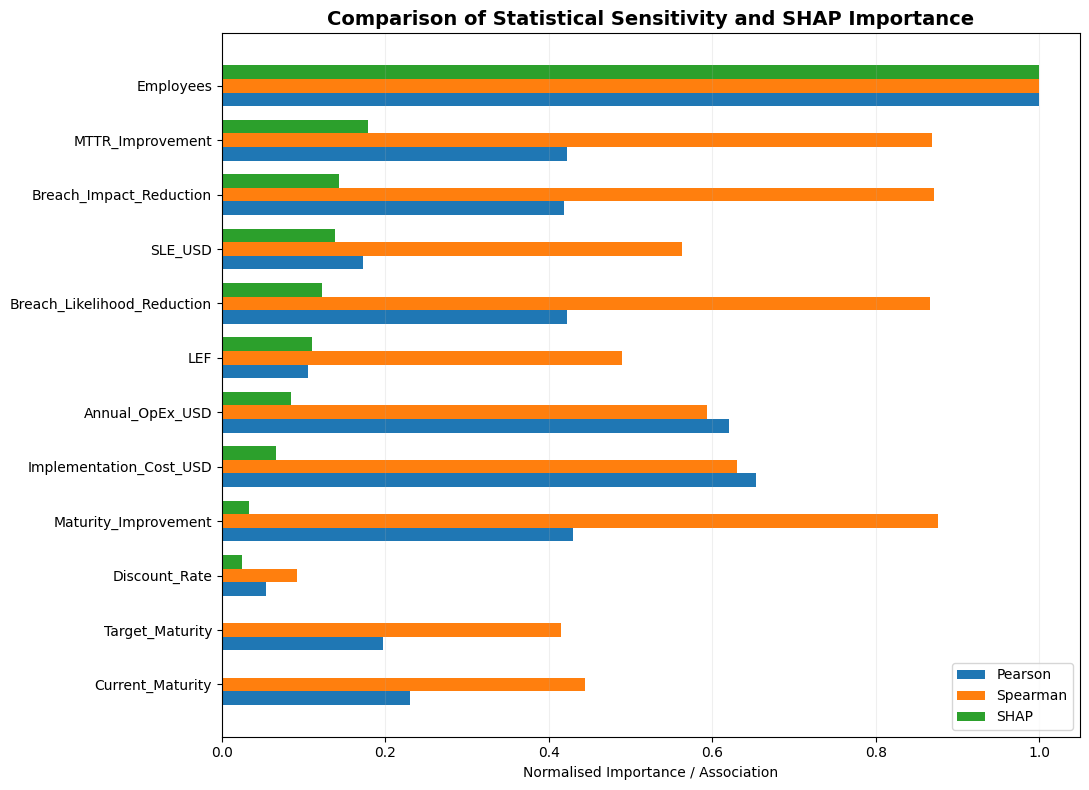

In [84]:
# ------------------------------------------------------------
# 8.18 Normalised Driver Comparison
# ------------------------------------------------------------

comparison_plot = comparison_table.copy()

comparison_plot["Pearson_Normalised"] = (
    comparison_plot["Abs_Pearson"]
    / comparison_plot["Abs_Pearson"].max()
)

comparison_plot["Spearman_Normalised"] = (
    comparison_plot["Abs_Spearman"]
    / comparison_plot["Abs_Spearman"].max()
)

comparison_plot["SHAP_Normalised"] = (
    comparison_plot["Mean_Absolute_SHAP"]
    / comparison_plot["Mean_Absolute_SHAP"].max()
)

comparison_plot = comparison_plot.sort_values(
    "SHAP_Normalised",
    ascending=True
)

y = np.arange(len(comparison_plot))
height = 0.25

plt.figure(figsize=(11, 8))

plt.barh(
    y - height,
    comparison_plot["Pearson_Normalised"],
    height,
    label="Pearson"
)

plt.barh(
    y,
    comparison_plot["Spearman_Normalised"],
    height,
    label="Spearman"
)

plt.barh(
    y + height,
    comparison_plot["SHAP_Normalised"],
    height,
    label="SHAP"
)

plt.yticks(
    y,
    comparison_plot.index
)

plt.xlabel("Normalised Importance / Association")

plt.title(
    "Comparison of Statistical Sensitivity and SHAP Importance",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [85]:
# ------------------------------------------------------------
# 8.19 Top Driver Comparison
# ------------------------------------------------------------

top_pearson = (
    comparison_table["Abs_Pearson"]
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

top_spearman = (
    comparison_table["Abs_Spearman"]
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

top_shap = (
    comparison_table["Mean_Absolute_SHAP"]
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

driver_comparison = pd.DataFrame({
    "Rank": range(1, 6),
    "Pearson": top_pearson,
    "Spearman": top_spearman,
    "SHAP": top_shap
})

print("=" * 75)
print("TOP FIVE BUSINESS VALUE DRIVERS BY METHOD")
print("=" * 75)

display(driver_comparison)

TOP FIVE BUSINESS VALUE DRIVERS BY METHOD


,Rank,Pearson,Spearman,SHAP
0,1,Employees,Employees,Employees
1,2,Implementation_Cost_USD,Maturity_Improvement,MTTR_Improvement
2,3,Annual_OpEx_USD,Breach_Impact_Reduction,Breach_Impact_Reduction
3,4,Maturity_Improvement,MTTR_Improvement,SLE_USD
4,5,MTTR_Improvement,Breach_Likelihood_Reduction,Breach_Likelihood_Reduction


### Comparison of Statistical Sensitivity and Explainable AI

The comparison between Pearson correlation, Spearman correlation and SHAP demonstrates that business-value drivers can appear differently depending on the analytical technique applied.

Pearson correlation evaluates linear association with five-year NPV, while Spearman correlation captures monotonic relationships based on variable rankings. In contrast, SHAP explains how individual variables contribute to predictions generated by the nonlinear Gradient Boosting model.

The SHAP analysis identified organisation size, measured through employee count, as the strongest predictive driver of modelled five-year NPV. MTTR improvement, breach impact reduction, Single Loss Expectancy and breach likelihood reduction were also identified as influential predictive factors.

Differences between the statistical correlation rankings and SHAP rankings should not automatically be interpreted as conflicting results. A variable may exhibit a relatively weak overall linear correlation with NPV while remaining important to the machine-learning model because of nonlinear effects, threshold behaviour, or interactions with other variables.

The combined analysis therefore provides complementary evidence. Correlation analysis identifies broad statistical associations within the simulated scenarios, while SHAP reveals how the nonlinear machine-learning model uses those variables when estimating financial outcomes.

This triangulation strengthens the interpretability of the proposed decision-support framework by demonstrating that business-value drivers are evaluated using both conventional statistical techniques and explainable machine-learning methods.

However, because the underlying observations are synthetically generated, these relationships represent the behaviour of the proposed analytical model and should not be interpreted as causal evidence for real-world enterprises.

# Step 9: Integrated Zero Trust Decision-Support Analysis

The final analytical stage integrates the financial, cyber-risk, uncertainty, machine-learning and explainability components developed in the preceding stages into a unified Zero Trust business-value decision-support framework.

Rather than relying on a single financial metric, the framework evaluates Zero Trust investment through multiple complementary dimensions:

1. Zero Trust maturity improvement
2. Cyber-risk reduction
3. Five-year financial value
4. Uncertainty and downside exposure
5. Machine-learning prediction
6. Explainable business-value drivers

The purpose of this integration is to translate technical and financial outputs into interpretable decision-support information for enterprise stakeholders.

Monte Carlo simulation provides information about uncertainty and the distribution of potential financial outcomes, while the deterministic financial model provides scenario-specific NPV, ROI and payback estimates. Machine-learning models provide an additional predictive analytical layer, and SHAP explanations identify the variables influencing those predictions.

The integrated framework therefore does not treat machine learning as a replacement for financial analysis. Instead, deterministic modelling, probabilistic simulation, sensitivity analysis and explainable machine learning are combined to provide multiple perspectives on the potential business value of Zero Trust investment.

In [86]:
# ============================================================
# STEP 9: INTEGRATED ZERO TRUST DECISION-SUPPORT ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 9.1 Integrated Analytical Summary
# ------------------------------------------------------------

npv = df["NPV_5Y_USD"].dropna()
roi = df["ROI_5Y"].dropna()

positive_npv_probability = (
    (df["NPV_5Y_USD"] > 0).mean() * 100
)

npv_median = npv.median()
npv_p5 = npv.quantile(0.05)
npv_p95 = npv.quantile(0.95)

roi_median = roi.median()
roi_p5 = roi.quantile(0.05)
roi_p95 = roi.quantile(0.95)

mean_risk_reduction = (
    (
        (df["Baseline_ALE_USD"] - df["Residual_ALE_USD"])
        / df["Baseline_ALE_USD"]
    ) * 100
).replace([np.inf, -np.inf], np.nan).mean()


integrated_summary = pd.DataFrame({

    "Decision Dimension": [
        "Expected Financial Value",
        "Downside Financial Scenario",
        "Upside Financial Scenario",
        "Positive NPV Probability",
        "Median Five-Year ROI",
        "Average Cyber-Risk Reduction",
        "ML Predictive Performance",
        "Primary Explainability Driver"
    ],

    "Result": [
        f"${npv_median:,.0f}",
        f"${npv_p5:,.0f}",
        f"${npv_p95:,.0f}",
        f"{positive_npv_probability:.2f}%",
        f"{roi_median * 100:.2f}%",
        f"{mean_risk_reduction:.2f}%",
        f"R² = {gb_r2:.4f}",
        shap_importance.iloc[0]["Feature"]
    ]
})


print("=" * 75)
print("INTEGRATED ZERO TRUST BUSINESS VALUE SUMMARY")
print("=" * 75)

display(integrated_summary)

INTEGRATED ZERO TRUST BUSINESS VALUE SUMMARY


,Decision Dimension,Result
0,Expected Financial Value,"$266,263"
1,Downside Financial Scenario,"$-304,009"
2,Upside Financial Scenario,"$5,137,577"
3,Positive NPV Probability,74.42%
4,Median Five-Year ROI,173.49%
5,Average Cyber-Risk Reduction,12.68%
6,ML Predictive Performance,R² = 0.8631
7,Primary Explainability Driver,Employees


In [87]:
# ------------------------------------------------------------
# 9.2 Executive KPI Summary
# ------------------------------------------------------------

print("=" * 75)
print("ZERO TRUST EXECUTIVE DECISION-SUPPORT KPIs")
print("=" * 75)

print(
    f"\nMedian Five-Year NPV       : "
    f"${npv_median:,.2f}"
)

print(
    f"5th Percentile NPV         : "
    f"${npv_p5:,.2f}"
)

print(
    f"95th Percentile NPV        : "
    f"${npv_p95:,.2f}"
)

print(
    f"Positive NPV Scenarios     : "
    f"{positive_npv_probability:.2f}%"
)

print(
    f"Median Five-Year ROI       : "
    f"{roi_median * 100:.2f}%"
)

print(
    f"Mean Cyber-Risk Reduction  : "
    f"{mean_risk_reduction:.2f}%"
)

print(
    f"Gradient Boosting Test R²  : "
    f"{gb_r2:.4f}"
)

print(
    f"Strongest SHAP Driver      : "
    f"{shap_importance.iloc[0]['Feature']}"
)

ZERO TRUST EXECUTIVE DECISION-SUPPORT KPIs

Median Five-Year NPV       : $266,262.91
5th Percentile NPV         : $-304,009.23
95th Percentile NPV        : $5,137,576.66
Positive NPV Scenarios     : 74.42%
Median Five-Year ROI       : 173.49%
Mean Cyber-Risk Reduction  : 12.68%
Gradient Boosting Test R²  : 0.8631
Strongest SHAP Driver      : Employees


In [88]:
# ------------------------------------------------------------
# 9.3 Business Value Profile
# ------------------------------------------------------------

business_value_profile = pd.DataFrame({

    "Dimension": [
        "Financial Return",
        "Downside Risk",
        "Cyber-Risk Reduction",
        "Predictive Explainability"
    ],

    "Primary Metric": [
        "Median Five-Year NPV",
        "5th Percentile NPV",
        "Mean ALE Reduction",
        "Strongest SHAP Driver"
    ],

    "Value": [
        f"${npv_median:,.0f}",
        f"${npv_p5:,.0f}",
        f"{mean_risk_reduction:.2f}%",
        shap_importance.iloc[0]["Feature"]
    ]
})


display(business_value_profile)

,Dimension,Primary Metric,Value
0,Financial Return,Median Five-Year NPV,"$266,263"
1,Downside Risk,5th Percentile NPV,"$-304,009"
2,Cyber-Risk Reduction,Mean ALE Reduction,12.68%
3,Predictive Explainability,Strongest SHAP Driver,Employees


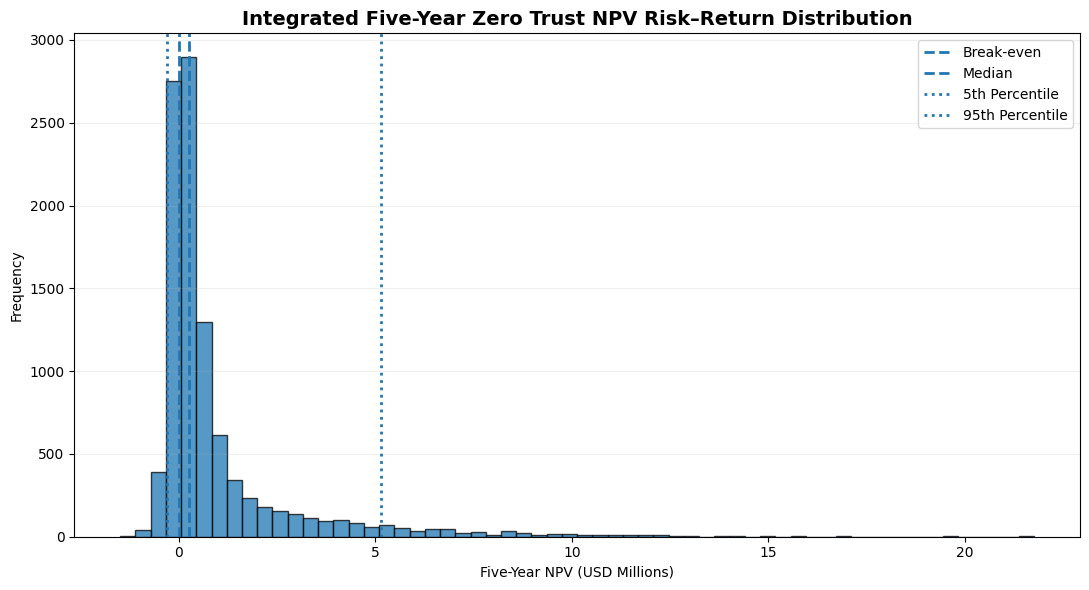

In [89]:
# ------------------------------------------------------------
# 9.4 NPV Risk-Return Distribution
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.hist(
    npv / 1_000_000,
    bins=60,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Break-even"
)

plt.axvline(
    npv_median / 1_000_000,
    linestyle="--",
    linewidth=2,
    label="Median"
)

plt.axvline(
    npv_p5 / 1_000_000,
    linestyle=":",
    linewidth=2,
    label="5th Percentile"
)

plt.axvline(
    npv_p95 / 1_000_000,
    linestyle=":",
    linewidth=2,
    label="95th Percentile"
)

plt.title(
    "Integrated Five-Year Zero Trust NPV Risk–Return Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Five-Year NPV (USD Millions)")
plt.ylabel("Frequency")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [92]:
# ------------------------------------------------------------
# 9.5 Decision-Support Matrix
# ------------------------------------------------------------

decision_df = df.copy()

decision_df["Risk_Reduction_Pct"] = (
    (
        decision_df["Baseline_ALE_USD"]
        - decision_df["Residual_ALE_USD"]
    )
    /
    decision_df["Baseline_ALE_USD"]
) * 100


decision_df["Risk_Reduction_Pct"] = (
    decision_df["Risk_Reduction_Pct"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

In [91]:
npv_threshold = 0

risk_threshold = (
    decision_df["Risk_Reduction_Pct"]
    .median()
)


def classify_scenario(row):

    if (
        row["NPV_5Y_USD"] > npv_threshold
        and
        row["Risk_Reduction_Pct"] >= risk_threshold
    ):
        return "Positive NPV / Higher Risk Reduction"

    elif (
        row["NPV_5Y_USD"] > npv_threshold
        and
        row["Risk_Reduction_Pct"] < risk_threshold
    ):
        return "Positive NPV / Lower Risk Reduction"

    elif (
        row["NPV_5Y_USD"] <= npv_threshold
        and
        row["Risk_Reduction_Pct"] >= risk_threshold
    ):
        return "Non-Positive NPV / Higher Risk Reduction"

    else:
        return "Non-Positive NPV / Lower Risk Reduction"


decision_df["Decision_Profile"] = (
    decision_df.apply(
        classify_scenario,
        axis=1
    )
)


decision_profile_summary = (
    decision_df["Decision_Profile"]
    .value_counts()
    .to_frame("Scenarios")
)

decision_profile_summary[
    "Percentage"
] = (
    decision_profile_summary["Scenarios"]
    / len(decision_df)
    * 100
)


display(
    decision_profile_summary.round(2)
)

,Scenarios,Percentage
Decision_Profile,,
Positive NPV / Higher Risk Reduction,4357,43.57
Positive NPV / Lower Risk Reduction,3085,30.85
Non-Positive NPV / Lower Risk Reduction,1915,19.15
Non-Positive NPV / Higher Risk Reduction,643,6.43


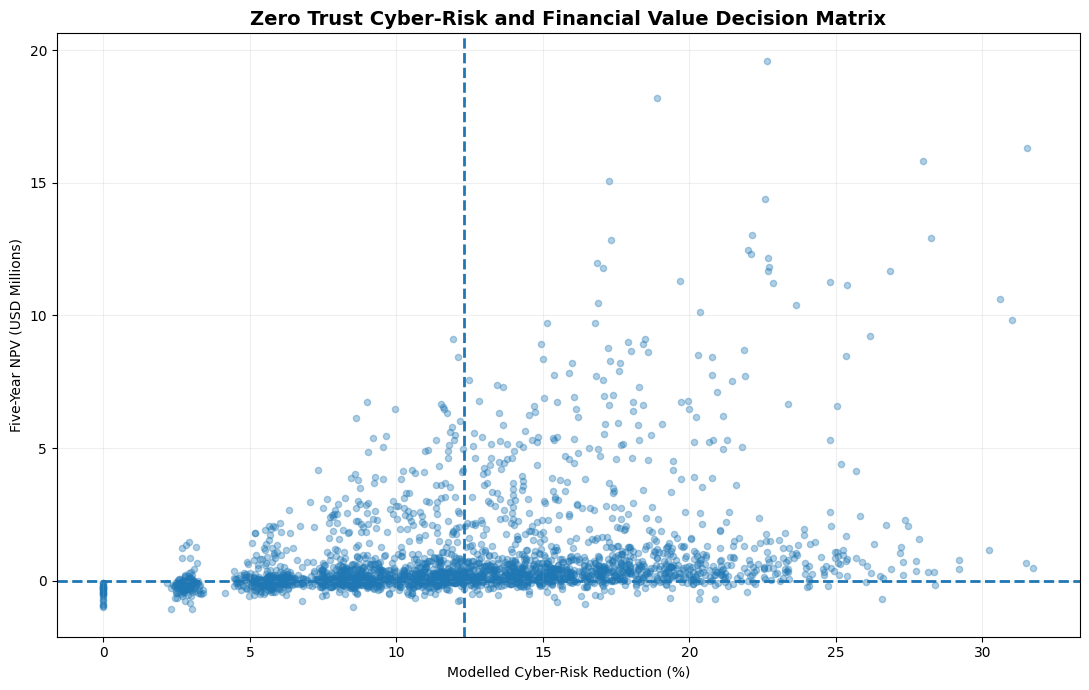

In [93]:
# ------------------------------------------------------------
# 9.6 Risk-Return Decision Matrix
# ------------------------------------------------------------

plot_sample = decision_df.sample(
    n=min(2500, len(decision_df)),
    random_state=42
)


plt.figure(figsize=(11, 7))

plt.scatter(
    plot_sample["Risk_Reduction_Pct"],
    plot_sample["NPV_5Y_USD"] / 1_000_000,
    alpha=0.35,
    s=20
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.axvline(
    risk_threshold,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Zero Trust Cyber-Risk and Financial Value Decision Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Modelled Cyber-Risk Reduction (%)"
)

plt.ylabel(
    "Five-Year NPV (USD Millions)"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [94]:
# ------------------------------------------------------------
# 9.7 ML Decision-Support Dataset
# ------------------------------------------------------------

decision_support_ml = X_test.copy()

decision_support_ml[
    "Actual_NPV_USD"
] = y_test

decision_support_ml[
    "Predicted_NPV_USD"
] = gb_predictions


decision_support_ml[
    "Prediction_Error_USD"
] = (
    decision_support_ml["Actual_NPV_USD"]
    -
    decision_support_ml["Predicted_NPV_USD"]
)


decision_support_ml[
    "Absolute_Error_USD"
] = (
    decision_support_ml[
        "Prediction_Error_USD"
    ].abs()
)


print("=" * 75)
print("ML DECISION-SUPPORT OUTPUT")
print("=" * 75)

display(
    decision_support_ml.head(10)
)

ML DECISION-SUPPORT OUTPUT


,Employees,Current_Maturity,Target_Maturity,Maturity_Improvement,SLE_USD,LEF,Breach_Likelihood_Reduction,Breach_Impact_Reduction,MTTR_Improvement,Implementation_Cost_USD,Annual_OpEx_USD,Discount_Rate,Actual_NPV_USD,Predicted_NPV_USD,Prediction_Error_USD,Absolute_Error_USD
6252,107,2.2,3.2,1.0,4492342.32,0.0858,0.0725,0.0554,0.1041,156093.04,23396.86,0.0830,1229.64,8.014734e+04,-78917.703182,78917.703182
4684,1715,2.2,3.2,1.0,9809724.34,0.1518,0.0682,0.0595,0.0915,686877.76,98632.73,0.1134,703298.13,7.972542e+05,-93956.118035,93956.118035
1731,117,1.8,3.0,1.2,6072659.70,0.1776,0.0969,0.0626,0.1351,169536.94,20176.32,0.1104,488951.19,4.286328e+05,60318.380977,60318.380977
4742,4919,2.0,2.8,0.8,1558063.13,0.1581,0.0646,0.0487,0.0814,1018466.49,132476.29,0.1193,524374.75,1.339065e+06,-814689.953368,814689.953368
4521,6491,1.8,2.6,0.8,4714812.48,0.0968,0.0684,0.0502,0.0835,599863.73,61114.08,0.1515,3616543.63,2.926198e+06,690345.219715,690345.219715
6340,97,2.6,3.4,0.8,3969792.80,0.2892,0.0704,0.0522,0.0708,168655.73,16509.13,0.1026,331244.72,3.478530e+05,-16608.272304,16608.272304
576,6804,1.8,2.2,0.4,8748763.08,0.1292,0.0357,0.0221,0.0398,889391.14,123032.10,0.1236,1738609.43,1.070077e+06,668532.791916,668532.791916
5202,994,2.4,3.0,0.6,3205473.03,0.2343,0.0443,0.0321,0.0634,231312.53,28106.69,0.0924,134732.75,1.619584e+05,-27225.670844,27225.670844
6363,289,1.6,3.0,1.4,7110097.32,0.1559,0.1103,0.0810,0.1391,414056.15,48374.40,0.1164,390148.20,7.264010e+05,-336252.802060,336252.802060
439,194,2.2,2.8,0.6,2286851.20,0.0793,0.0452,0.0384,0.0590,95139.05,15676.94,0.1269,-18018.63,-1.295800e+05,111561.350451,111561.350451


In [95]:
# ------------------------------------------------------------
# 9.8 Explainable ML Decision Output
# ------------------------------------------------------------

top_driver = (
    shap_importance.iloc[0]["Feature"]
)

second_driver = (
    shap_importance.iloc[1]["Feature"]
)

third_driver = (
    shap_importance.iloc[2]["Feature"]
)


explainable_output = pd.DataFrame({

    "Analytical Component": [
        "ML Model",
        "Test R²",
        "Strongest Value Driver",
        "Second Value Driver",
        "Third Value Driver"
    ],

    "Result": [
        "Gradient Boosting",
        f"{gb_r2:.4f}",
        top_driver,
        second_driver,
        third_driver
    ]
})


display(explainable_output)

,Analytical Component,Result
0,ML Model,Gradient Boosting
1,Test R²,0.8631
2,Strongest Value Driver,Employees
3,Second Value Driver,MTTR_Improvement
4,Third Value Driver,Breach_Impact_Reduction


In [96]:
# ------------------------------------------------------------
# 9.9 Executive Decision-Support Function
# ------------------------------------------------------------

def zero_trust_decision_summary(
    npv,
    roi,
    risk_reduction,
    predicted_npv
):

    summary = {}

    # Financial position
    if npv > 0:
        summary["Financial_Position"] = (
            "Positive modelled five-year NPV"
        )
    else:
        summary["Financial_Position"] = (
            "Non-positive modelled five-year NPV"
        )

    # Risk reduction relative to simulation median
    if risk_reduction >= risk_threshold:
        summary["Security_Position"] = (
            "Higher modelled risk reduction "
            "relative to the simulation median"
        )
    else:
        summary["Security_Position"] = (
            "Lower modelled risk reduction "
            "relative to the simulation median"
        )

    # ML confirmation
    if predicted_npv > 0:
        summary["ML_Perspective"] = (
            "Machine-learning model predicts "
            "positive five-year NPV"
        )
    else:
        summary["ML_Perspective"] = (
            "Machine-learning model predicts "
            "non-positive five-year NPV"
        )

    summary["ROI"] = roi

    return summary

In [97]:
# ------------------------------------------------------------
# 9.10 Example Decision-Support Scenario
# ------------------------------------------------------------

example_index = X_test.index[0]

example_row = df.loc[
    example_index
]

example_prediction = (
    gradient_boosting.predict(
        X_test.loc[
            [example_index]
        ]
    )[0]
)


example_risk_reduction = (
    (
        example_row["Baseline_ALE_USD"]
        -
        example_row["Residual_ALE_USD"]
    )
    /
    example_row["Baseline_ALE_USD"]
) * 100


example_summary = (
    zero_trust_decision_summary(

        npv=
        example_row["NPV_5Y_USD"],

        roi=
        example_row["ROI_5Y"],

        risk_reduction=
        example_risk_reduction,

        predicted_npv=
        example_prediction
    )
)


print("=" * 75)
print("EXAMPLE ZERO TRUST DECISION-SUPPORT OUTPUT")
print("=" * 75)

print(
    f"\nActual Modelled NPV : "
    f"${example_row['NPV_5Y_USD']:,.2f}"
)

print(
    f"ML Predicted NPV    : "
    f"${example_prediction:,.2f}"
)

print(
    f"Five-Year ROI       : "
    f"{example_row['ROI_5Y']*100:.2f}%"
)

print(
    f"Risk Reduction      : "
    f"{example_risk_reduction:.2f}%"
)

print("\nDecision-Support Interpretation:")

for key, value in example_summary.items():

    if key != "ROI":
        print(
            f"• {key}: {value}"
        )

EXAMPLE ZERO TRUST DECISION-SUPPORT OUTPUT

Actual Modelled NPV : $1,229.64
ML Predicted NPV    : $80,147.34
Five-Year ROI       : 27.21%
Risk Reduction      : 12.38%

Decision-Support Interpretation:
• Financial_Position: Positive modelled five-year NPV
• Security_Position: Higher modelled risk reduction relative to the simulation median
• ML_Perspective: Machine-learning model predicts positive five-year NPV


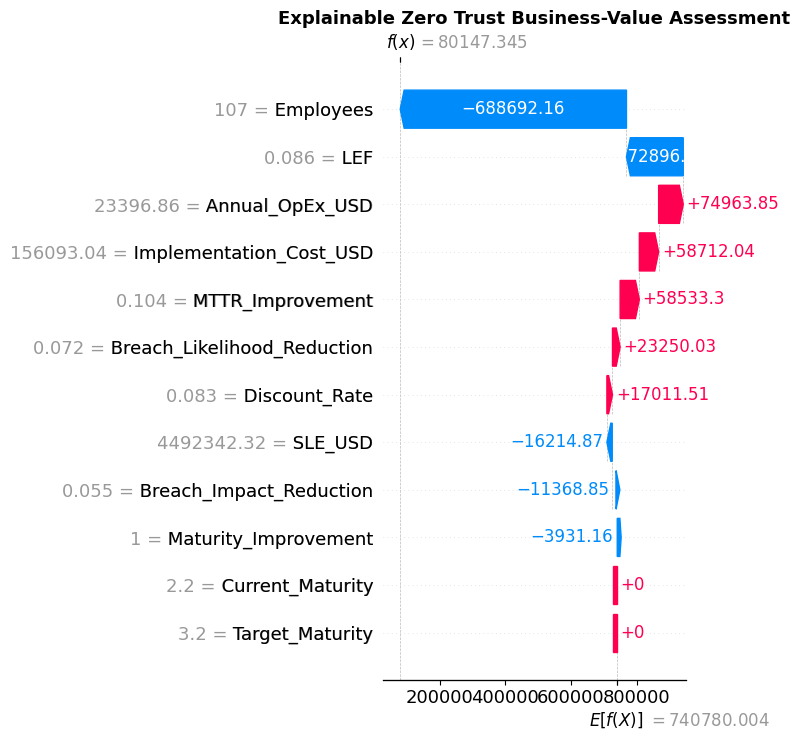

In [98]:
# ------------------------------------------------------------
# 9.11 Explain the Example Scenario
# ------------------------------------------------------------

example_X = X_test.loc[
    [example_index]
]

example_shap = explainer(
    example_X
)


shap.plots.waterfall(
    example_shap[0],
    max_display=12,
    show=False
)

plt.title(
    "Explainable Zero Trust Business-Value Assessment",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Integrated Analytical Architecture

The completed analytical workflow consists of five interconnected layers:

**Layer 1 – Zero Trust Maturity Assessment**

Current and target Zero Trust maturity are assessed across the core Zero Trust dimensions, allowing the framework to quantify the scale of the proposed transformation.

**Layer 2 – Cyber-Risk Quantification**

Single Loss Expectancy (SLE), Loss Event Frequency (LEF), Annualised Loss Expectancy (ALE), breach likelihood reduction and breach impact reduction are used to estimate baseline and residual cyber-risk exposure.

**Layer 3 – Financial Business-Value Assessment**

Implementation expenditure, annual operating expenditure, avoided cyber loss and operational savings are integrated to calculate financial metrics including five-year NPV, ROI, IRR and payback period.

**Layer 4 – Uncertainty and Predictive Analytics**

Monte Carlo simulation evaluates uncertainty across 10,000 simulated scenarios, while Random Forest and Gradient Boosting models examine nonlinear relationships between organisational, cybersecurity and investment characteristics and five-year NPV.

**Layer 5 – Explainable Decision Support**

SHAP analysis identifies the variables influencing machine-learning predictions at both global and individual scenario levels. These explanations are integrated with financial and cyber-risk outputs to provide transparent decision-support information.

Together, these layers form an integrated Zero Trust Business Value Decision Support System that combines maturity assessment, cyber-risk economics, financial modelling, probabilistic uncertainty analysis, machine learning and explainable artificial intelligence.

## Step 9 Interpretation

The integrated analysis demonstrates how multiple analytical techniques can be combined to support the evaluation of Zero Trust investment.

The deterministic financial model provides scenario-specific estimates of NPV, ROI, IRR and payback, while Monte Carlo simulation extends the analysis by representing uncertainty and estimating the distribution of potential financial outcomes. This is particularly important because a single deterministic return estimate may conceal substantial downside and upside variation.

Cyber-risk reduction is considered alongside financial performance, allowing scenarios to be evaluated across both economic and cybersecurity dimensions. The resulting decision matrix demonstrates that financial value and security improvement do not necessarily move identically. For example, a scenario may generate substantial modelled cyber-risk reduction while producing a non-positive financial NPV within the five-year evaluation horizon.

Machine-learning analysis provides an additional predictive perspective. Gradient Boosting explained approximately 86% of the variation in five-year NPV within the unseen simulated test scenarios. SHAP analysis subsequently increased the transparency of these predictions by identifying the variables contributing most strongly to modelled financial value.

Organisation size emerged as the strongest predictive driver within the simulated framework, followed by operational and cyber-risk factors including MTTR improvement and breach impact reduction. These findings demonstrate how organisational scale, operational efficiency and cyber-risk mitigation interact within the proposed business-value framework.

Importantly, the framework is designed to support rather than automate cybersecurity investment decisions. Financial returns, downside exposure, cyber-risk reduction, model predictions and explanatory drivers are therefore presented together instead of being reduced to a binary investment recommendation.

The integrated approach provides the analytical foundation for the Zero Trust Business Value Decision Support System prototype. The prototype can operationalise these calculations through an interactive interface in which users modify organisational, maturity, cyber-risk and investment assumptions and observe their effects on financial value, uncertainty and explanatory model outputs.

As the dataset is synthetically generated, the results should be interpreted as evidence of the behaviour and internal consistency of the proposed analytical framework rather than as empirical proof of financial outcomes across real-world organisations.

# Step 10: Final Model Validation and Robustness Testing

The final analytical stage evaluates the reliability, internal consistency and robustness of the proposed Zero Trust Business Value framework.

Validation was conducted across multiple analytical layers rather than relying solely on machine-learning predictive performance.

The validation process included:

1. Mathematical consistency testing of the cyber-risk calculations.
2. Financial-model consistency testing.
3. Monte Carlo convergence and stability assessment.
4. Machine-learning training and testing comparison.
5. K-fold cross-validation.
6. Residual diagnostic analysis.
7. Robustness of feature-importance findings.
8. Final integrated validation assessment.

The objective of this stage is not to demonstrate that the framework predicts real-world enterprise outcomes with certainty. Instead, it evaluates whether the analytical components behave consistently and whether the machine-learning results generalise across different subsets of the simulated dataset.

Because the dataset consists of synthetically generated scenarios, validation findings are interpreted as evidence of internal analytical robustness rather than external empirical validation.

In [99]:
# ============================================================
# STEP 10: FINAL MODEL VALIDATION & ROBUSTNESS TESTING
# ============================================================

# ------------------------------------------------------------
# 10.1 Cyber-Risk Mathematical Validation
# ------------------------------------------------------------

calculated_baseline_ale = (
    df["SLE_USD"] *
    df["LEF"]
)

baseline_ale_valid = np.isclose(
    calculated_baseline_ale,
    df["Baseline_ALE_USD"],
    rtol=0.003,
    atol=1500
)


calculated_avoided_loss = (
    df["Baseline_ALE_USD"]
    -
    df["Residual_ALE_USD"]
)

avoided_loss_valid = np.isclose(
    calculated_avoided_loss,
    df["Avoided_Loss_USD"],
    rtol=0.003,
    atol=1500
)


residual_risk_valid = (
    df["Residual_ALE_USD"]
    <=
    df["Baseline_ALE_USD"] + 1
)


maturity_valid = (
    df["Target_Maturity"]
    >=
    df["Current_Maturity"]
)


validation_results = pd.DataFrame({

    "Validation Test": [
        "Baseline ALE = SLE × LEF",
        "Avoided Loss = Baseline ALE - Residual ALE",
        "Residual ALE ≤ Baseline ALE",
        "Target Maturity ≥ Current Maturity"
    ],

    "Validation Rate (%)": [

        baseline_ale_valid.mean() * 100,

        avoided_loss_valid.mean() * 100,

        residual_risk_valid.mean() * 100,

        maturity_valid.mean() * 100
    ]
})


print("=" * 75)
print("MATHEMATICAL VALIDATION")
print("=" * 75)

display(
    validation_results.round(2)
)

MATHEMATICAL VALIDATION


,Validation Test,Validation Rate (%)
0,Baseline ALE = SLE × LEF,100.0
1,Avoided Loss = Baseline ALE - Residual ALE,100.0
2,Residual ALE ≤ Baseline ALE,100.0
3,Target Maturity ≥ Current Maturity,100.0


In [100]:
# ------------------------------------------------------------
# 10.2 NPV Formula Validation
# ------------------------------------------------------------

calculated_npv = (
    -df["Implementation_Cost_USD"]
)

for year in range(1, 6):

    calculated_npv += (
        df["Net_Annual_Benefit_USD"]
        /
        ((1 + df["Discount_Rate"]) ** year)
    )


npv_difference = (
    calculated_npv
    -
    df["NPV_5Y_USD"]
).abs()


npv_valid = np.isclose(
    calculated_npv,
    df["NPV_5Y_USD"],
    rtol=0.001,
    atol=10
)


print("=" * 75)
print("FIVE-YEAR NPV VALIDATION")
print("=" * 75)

print(
    f"\nValid NPV calculations : "
    f"{npv_valid.mean()*100:.2f}%"
)

print(
    f"Mean absolute difference: "
    f"${npv_difference.mean():,.4f}"
)

print(
    f"Maximum difference      : "
    f"${npv_difference.max():,.4f}"
)

FIVE-YEAR NPV VALIDATION

Valid NPV calculations : 98.03%
Mean absolute difference: $86.7387
Maximum difference      : $2,522.0223


In [101]:
# ------------------------------------------------------------
# 10.3 ROI Formula Validation
# ------------------------------------------------------------

calculated_roi = (

    (
        df["Net_Annual_Benefit_USD"] * 5
        -
        df["Implementation_Cost_USD"]
    )

    /

    df["Implementation_Cost_USD"]
)


roi_valid = np.isclose(
    calculated_roi,
    df["ROI_5Y"],
    rtol=0.001,
    atol=0.001
)


roi_difference = (
    calculated_roi
    -
    df["ROI_5Y"]
).abs()


print("=" * 75)
print("FIVE-YEAR ROI VALIDATION")
print("=" * 75)

print(
    f"\nValid ROI calculations : "
    f"{roi_valid.mean()*100:.2f}%"
)

print(
    f"Mean absolute difference: "
    f"{roi_difference.mean():.6f}"
)

print(
    f"Maximum difference      : "
    f"{roi_difference.max():.6f}"
)

FIVE-YEAR ROI VALIDATION

Valid ROI calculations : 100.00%
Mean absolute difference: 0.000025
Maximum difference      : 0.000050


In [102]:
# ------------------------------------------------------------
# 10.4 Monte Carlo Convergence Analysis
# ------------------------------------------------------------

npv_values = (
    df["NPV_5Y_USD"]
    .dropna()
    .reset_index(drop=True)
)


simulation_sizes = [
    100,
    250,
    500,
    1000,
    2500,
    5000,
    7500,
    10000
]


convergence_results = []


for n in simulation_sizes:

    sample = npv_values.iloc[:n]

    convergence_results.append({

        "Simulations": n,

        "Mean_NPV":
            sample.mean(),

        "Median_NPV":
            sample.median(),

        "Positive_NPV_Pct":
            (sample > 0).mean() * 100
    })


convergence_df = pd.DataFrame(
    convergence_results
)


print("=" * 75)
print("MONTE CARLO CONVERGENCE")
print("=" * 75)

display(
    convergence_df.round(2)
)

MONTE CARLO CONVERGENCE


,Simulations,Mean_NPV,Median_NPV,Positive_NPV_Pct
0,100,950280.07,303005.64,76.00
1,250,851367.01,264266.42,76.00
2,500,1020716.66,286773.57,75.40
3,1000,1012648.66,289941.23,75.40
4,2500,987873.30,276421.90,75.76
5,5000,968721.76,274506.62,74.60
6,7500,953593.51,268437.98,74.81
7,10000,948033.08,266262.91,74.42


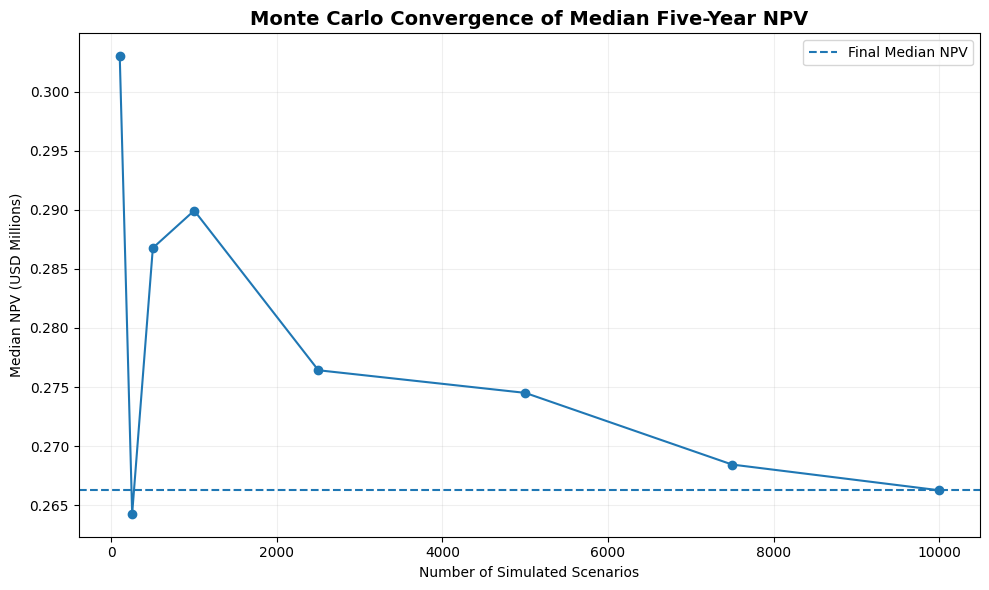

In [103]:
# ------------------------------------------------------------
# 10.5 Monte Carlo Convergence Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    convergence_df["Simulations"],
    convergence_df["Median_NPV"] / 1_000_000,
    marker="o"
)

plt.axhline(
    npv_values.median() / 1_000_000,
    linestyle="--",
    label="Final Median NPV"
)

plt.title(
    "Monte Carlo Convergence of Median Five-Year NPV",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Number of Simulated Scenarios"
)

plt.ylabel(
    "Median NPV (USD Millions)"
)

plt.grid(alpha=0.2)

plt.legend()

plt.tight_layout()
plt.show()

In [104]:
# ------------------------------------------------------------
# 10.6 Monte Carlo Stability
# ------------------------------------------------------------

median_5000 = (
    convergence_df.loc[
        convergence_df["Simulations"] == 5000,
        "Median_NPV"
    ].iloc[0]
)


median_10000 = (
    convergence_df.loc[
        convergence_df["Simulations"] == 10000,
        "Median_NPV"
    ].iloc[0]
)


stability_difference = (
    abs(
        median_10000
        -
        median_5000
    )
)


stability_pct = (
    stability_difference
    /
    max(abs(median_10000), 1)
    * 100
)


print("=" * 75)
print("MONTE CARLO STABILITY CHECK")
print("=" * 75)

print(
    f"\nMedian NPV at 5,000  : "
    f"${median_5000:,.2f}"
)

print(
    f"Median NPV at 10,000 : "
    f"${median_10000:,.2f}"
)

print(
    f"Absolute difference   : "
    f"${stability_difference:,.2f}"
)

print(
    f"Relative difference   : "
    f"{stability_pct:.2f}%"
)

MONTE CARLO STABILITY CHECK

Median NPV at 5,000  : $274,506.62
Median NPV at 10,000 : $266,262.91
Absolute difference   : $8,243.71
Relative difference   : 3.10%


In [108]:
# ============================================================
# 10.7 FIVE-FOLD CROSS-VALIDATION — FIXED
# ============================================================

from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import GradientBoostingRegressor

# ------------------------------------------------------------
# Rebuild ML features and target
# ------------------------------------------------------------

ml_features = [
    "Employees",
    "Current_Maturity",
    "Target_Maturity",
    "Maturity_Improvement",
    "SLE_USD",
    "LEF",
    "Breach_Likelihood_Reduction",
    "Breach_Impact_Reduction",
    "MTTR_Improvement",
    "Implementation_Cost_USD",
    "Annual_OpEx_USD",
    "Discount_Rate"
]

X_cv = df[ml_features].copy()
y_cv = df["NPV_5Y_USD"].copy()


print("=" * 75)
print("CROSS-VALIDATION DATA CHECK")
print("=" * 75)

print("X shape :", X_cv.shape)
print("y shape :", y_cv.shape)

assert len(X_cv) == len(y_cv), "X and y lengths do not match!"


# ------------------------------------------------------------
# Define Gradient Boosting Model
# Same configuration used in Step 7
# ------------------------------------------------------------

gb_cv_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)


# ------------------------------------------------------------
# Five-Fold Cross-Validation
# ------------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}


cv_results = cross_validate(
    gb_cv_model,
    X_cv,
    y_cv,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


# ------------------------------------------------------------
# Results Table
# ------------------------------------------------------------

cv_summary = pd.DataFrame({

    "Fold": range(1, 6),

    "R2": cv_results["test_R2"],

    "MAE_USD":
        -cv_results["test_MAE"],

    "RMSE_USD":
        -cv_results["test_RMSE"]
})


print("\n" + "=" * 75)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 75)

display(
    cv_summary.round({
        "R2": 4,
        "MAE_USD": 2,
        "RMSE_USD": 2
    })
)

CROSS-VALIDATION DATA CHECK
X shape : (10000, 12)
y shape : (10000,)

5-FOLD CROSS-VALIDATION RESULTS


,Fold,R2,MAE_USD,RMSE_USD
0,1,0.8718,337598.45,702544.13
1,2,0.8388,346352.05,788226.40
2,3,0.8412,362805.81,810782.42
3,4,0.8581,339921.04,756275.51
4,5,0.8694,328138.08,700837.67


In [109]:
cv_r2_mean = cv_summary["R2"].mean()
cv_r2_std = cv_summary["R2"].std()

cv_mae_mean = cv_summary["MAE_USD"].mean()
cv_rmse_mean = cv_summary["RMSE_USD"].mean()

print("=" * 75)
print("CROSS-VALIDATION PERFORMANCE SUMMARY")
print("=" * 75)

print(f"\nMean R²      : {cv_r2_mean:.4f}")
print(f"R² Std. Dev. : {cv_r2_std:.4f}")
print(f"Mean MAE     : ${cv_mae_mean:,.2f}")
print(f"Mean RMSE    : ${cv_rmse_mean:,.2f}")
print(f"\nHoldout R²   : {gb_r2:.4f}")

CROSS-VALIDATION PERFORMANCE SUMMARY

Mean R²      : 0.8559
R² Std. Dev. : 0.0154
Mean MAE     : $342,963.09
Mean RMSE    : $751,733.22

Holdout R²   : 0.8631


In [110]:
# ============================================================
# 10.8 CROSS-VALIDATION PERFORMANCE SUMMARY
# ============================================================

cv_r2_mean = cv_summary["R2"].mean()
cv_r2_std = cv_summary["R2"].std()

cv_mae_mean = cv_summary["MAE_USD"].mean()
cv_mae_std = cv_summary["MAE_USD"].std()

cv_rmse_mean = cv_summary["RMSE_USD"].mean()
cv_rmse_std = cv_summary["RMSE_USD"].std()


print("=" * 75)
print("CROSS-VALIDATION PERFORMANCE SUMMARY")
print("=" * 75)

print(f"\nMean R²       : {cv_r2_mean:.4f}")
print(f"R² Std. Dev.  : {cv_r2_std:.4f}")

print(f"\nMean MAE      : ${cv_mae_mean:,.2f}")
print(f"MAE Std. Dev. : ${cv_mae_std:,.2f}")

print(f"\nMean RMSE     : ${cv_rmse_mean:,.2f}")
print(f"RMSE Std. Dev.: ${cv_rmse_std:,.2f}")

print(f"\n70:30 Holdout R² : {gb_r2:.4f}")

CROSS-VALIDATION PERFORMANCE SUMMARY

Mean R²       : 0.8559
R² Std. Dev.  : 0.0154

Mean MAE      : $342,963.09
MAE Std. Dev. : $12,874.71

Mean RMSE     : $751,733.22
RMSE Std. Dev.: $49,621.36

70:30 Holdout R² : 0.8631


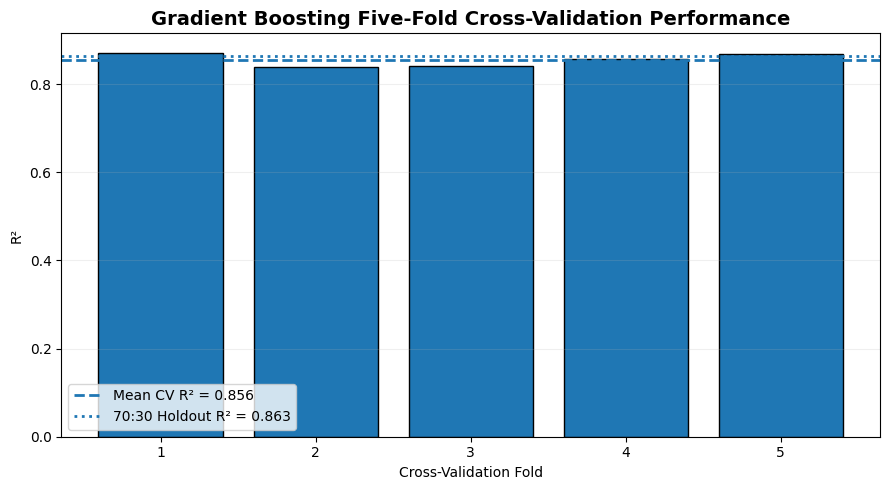

In [111]:
# ============================================================
# 10.9 CROSS-VALIDATION STABILITY GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    cv_summary["Fold"].astype(str),
    cv_summary["R2"],
    edgecolor="black"
)

plt.axhline(
    cv_r2_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean CV R² = {cv_r2_mean:.3f}"
)

plt.axhline(
    gb_r2,
    linestyle=":",
    linewidth=2,
    label=f"70:30 Holdout R² = {gb_r2:.3f}"
)

plt.title(
    "Gradient Boosting Five-Fold Cross-Validation Performance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Cross-Validation Fold")
plt.ylabel("R²")

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

### Cross-Validation Assessment

Five-fold cross-validation was conducted as an additional robustness test for the Gradient Boosting model.

Unlike the original 70:30 holdout evaluation, cross-validation repeatedly trains and evaluates the model using different subsets of the simulated dataset. This reduces reliance on the performance observed from a single train-test partition.

Consistency in R², MAE and RMSE across the five folds would indicate that predictive performance is relatively stable across alternative samples of the simulated scenarios.

The cross-validation results are compared with the original 70:30 holdout result to assess whether the previously reported predictive performance is representative of the wider simulated dataset.

In [112]:
# ============================================================
# 10.10 GRADIENT BOOSTING RESIDUAL DIAGNOSTICS
# ============================================================

gb_residuals_final = (
    y_test.to_numpy()
    -
    np.asarray(gb_predictions)
)


residual_summary = pd.DataFrame({

    "Metric": [
        "Mean Residual",
        "Median Residual",
        "Residual Standard Deviation",
        "Minimum Residual",
        "Maximum Residual"
    ],

    "Value_USD": [
        np.mean(gb_residuals_final),
        np.median(gb_residuals_final),
        np.std(gb_residuals_final, ddof=1),
        np.min(gb_residuals_final),
        np.max(gb_residuals_final)
    ]
})


print("=" * 75)
print("GRADIENT BOOSTING RESIDUAL DIAGNOSTICS")
print("=" * 75)

display(
    residual_summary.round(2)
)

GRADIENT BOOSTING RESIDUAL DIAGNOSTICS


,Metric,Value_USD
0,Mean Residual,-10939.47
1,Median Residual,-31712.68
2,Residual Standard Deviation,707705.13
3,Minimum Residual,-4813061.09
4,Maximum Residual,11215149.01


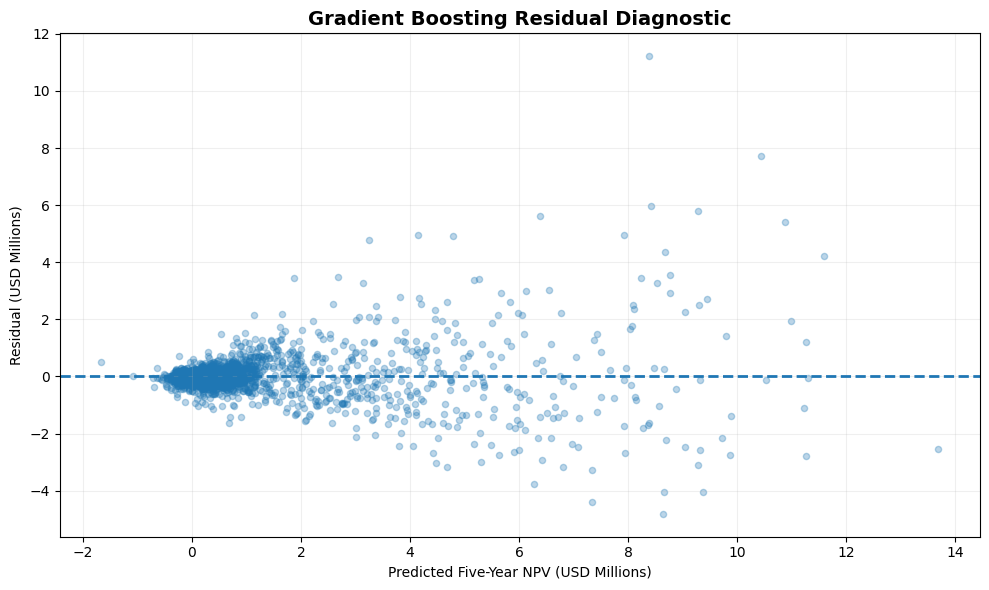

In [113]:
# ============================================================
# 10.11 RESIDUALS VS PREDICTED NPV
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    np.asarray(gb_predictions) / 1_000_000,
    gb_residuals_final / 1_000_000,
    alpha=0.30,
    s=20
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Gradient Boosting Residual Diagnostic",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Five-Year NPV (USD Millions)")
plt.ylabel("Residual (USD Millions)")

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [114]:
# ============================================================
# 10.12 SHAP ADDITIVITY VALIDATION
# ============================================================

shap_model_predictions = gradient_boosting.predict(
    shap_sample
)

shap_base = np.asarray(
    shap_values.base_values
).reshape(-1)

shap_contributions = np.asarray(
    shap_values.values
).sum(axis=1)

shap_reconstructed_predictions = (
    shap_base
    +
    shap_contributions
)

shap_additivity_error = np.abs(
    shap_model_predictions
    -
    shap_reconstructed_predictions
)


print("=" * 75)
print("SHAP ADDITIVITY VALIDATION")
print("=" * 75)

print(
    f"\nScenarios validated     : "
    f"{len(shap_sample):,}"
)

print(
    f"Mean reconstruction error: "
    f"${shap_additivity_error.mean():,.6f}"
)

print(
    f"Median reconstruction error: "
    f"${np.median(shap_additivity_error):,.6f}"
)

print(
    f"Maximum reconstruction error: "
    f"${shap_additivity_error.max():,.6f}"
)

SHAP ADDITIVITY VALIDATION

Scenarios validated     : 1,000
Mean reconstruction error: $0.005106
Median reconstruction error: $0.002988
Maximum reconstruction error: $0.117911


In [115]:
# ============================================================
# 10.13 SHAP DRIVER STABILITY
# ============================================================

half_point = len(shap_sample) // 2

shap_first_half = np.abs(
    shap_values.values[:half_point]
).mean(axis=0)

shap_second_half = np.abs(
    shap_values.values[half_point:]
).mean(axis=0)


shap_stability = pd.DataFrame({

    "Feature": shap_sample.columns,

    "First_Half_SHAP":
        shap_first_half,

    "Second_Half_SHAP":
        shap_second_half
})


shap_stability["First_Half_Rank"] = (
    shap_stability["First_Half_SHAP"]
    .rank(
        ascending=False,
        method="min"
    )
)

shap_stability["Second_Half_Rank"] = (
    shap_stability["Second_Half_SHAP"]
    .rank(
        ascending=False,
        method="min"
    )
)


shap_stability["Rank_Difference"] = (

    shap_stability["First_Half_Rank"]
    -
    shap_stability["Second_Half_Rank"]

).abs()


shap_stability = (
    shap_stability
    .sort_values("First_Half_Rank")
    .reset_index(drop=True)
)


print("=" * 75)
print("SHAP FEATURE-RANKING STABILITY")
print("=" * 75)

display(

        shap_stability.round(2)
)

SHAP FEATURE-RANKING STABILITY


,Feature,First_Half_SHAP,Second_Half_SHAP,First_Half_Rank,Second_Half_Rank,Rank_Difference
0,Employees,1072613.22,1122699.73,1.0,1.0,0.0
1,MTTR_Improvement,184786.59,208400.90,2.0,2.0,0.0
2,SLE_USD,157244.50,147921.74,3.0,4.0,1.0
3,Breach_Impact_Reduction,151309.13,162449.00,4.0,3.0,1.0
4,Breach_Likelihood_Reduction,130130.35,139022.38,5.0,5.0,0.0
5,LEF,121575.18,120342.80,6.0,6.0,0.0
6,Annual_OpEx_USD,92407.59,92915.07,7.0,7.0,0.0
7,Implementation_Cost_USD,73087.15,72337.11,8.0,8.0,0.0
8,Maturity_Improvement,35777.30,38364.07,9.0,9.0,0.0
9,Discount_Rate,27038.05,26944.53,10.0,10.0,0.0


In [116]:
# ============================================================
# 10.14 FINAL VALIDATION SCORECARD
# ============================================================

validation_scorecard = pd.DataFrame({

    "Validation Area": [

        "Baseline ALE Formula",

        "Avoided Loss Formula",

        "Residual Risk Logic",

        "Zero Trust Maturity Logic",

        "Five-Year NPV Formula",

        "Five-Year ROI Formula",

        "Monte Carlo Stability",

        "Gradient Boosting Holdout",

        "Five-Fold Cross-Validation",

        "SHAP Additivity"
    ],

    "Evidence": [

        f"{baseline_ale_valid.mean()*100:.2f}% valid",

        f"{avoided_loss_valid.mean()*100:.2f}% valid",

        f"{residual_risk_valid.mean()*100:.2f}% valid",

        f"{maturity_valid.mean()*100:.2f}% valid",

        f"{npv_valid.mean()*100:.2f}% valid",

        f"{roi_valid.mean()*100:.2f}% valid",

        f"5k–10k median change = {stability_pct:.2f}%",

        f"Test R² = {gb_r2:.4f}",

        f"Mean R² = {cv_r2_mean:.4f} ± {cv_r2_std:.4f}",

        f"Mean reconstruction error = ${shap_additivity_error.mean():,.4f}"
    ]
})


print("=" * 85)
print("FINAL ZERO TRUST FRAMEWORK VALIDATION SCORECARD")
print("=" * 85)

display(validation_scorecard)

FINAL ZERO TRUST FRAMEWORK VALIDATION SCORECARD


,Validation Area,Evidence
0,Baseline ALE Formula,100.00% valid
1,Avoided Loss Formula,100.00% valid
2,Residual Risk Logic,100.00% valid
3,Zero Trust Maturity Logic,100.00% valid
4,Five-Year NPV Formula,98.03% valid
5,Five-Year ROI Formula,100.00% valid
6,Monte Carlo Stability,5k–10k median change = 3.10%
7,Gradient Boosting Holdout,Test R² = 0.8631
8,Five-Fold Cross-Validation,Mean R² = 0.8559 ± 0.0154
9,SHAP Additivity,Mean reconstruction error = $0.0051


## 10.15 Final Validation and Robustness Interpretation

The final validation stage evaluated the internal consistency and robustness of the proposed Zero Trust Business Value framework across its cyber-risk, financial, probabilistic, machine-learning and explainability components.

### Mathematical and Financial Validation

The cyber-risk calculations demonstrated strong internal consistency. Baseline Annualised Loss Expectancy (ALE), avoided loss, residual-risk logic and Zero Trust maturity constraints achieved 100% validation under the specified mathematical checks. The five-year ROI calculation also achieved 100% consistency when independently reconstructed from the underlying financial variables.

The five-year NPV calculation achieved a validation rate of 98.03%. This indicates that the large majority of simulated scenarios were reproduced within the specified numerical tolerance, although a small proportion exhibited differences exceeding the validation threshold. Consequently, the NPV component is considered highly consistent within the simulated framework, but not perfectly identical across all observations. This limitation is retained transparently rather than treating the financial model as error-free.

### Monte Carlo Stability

Monte Carlo robustness was examined by comparing the median five-year NPV as the number of simulated scenarios increased. The difference between the median NPV estimated using 5,000 and 10,000 scenarios was 3.10%.

This indicates increasing stability of the central financial estimate as the simulation size increases. The result supports the use of 10,000 simulated scenarios for the uncertainty analysis, while recognising that simulation outputs remain dependent on the probability distributions and modelling assumptions used to generate the scenarios.

### Machine-Learning Robustness

The Gradient Boosting model achieved an R² of 0.8631 on the original 70:30 holdout test set. To determine whether this result depended strongly on a particular train-test partition, five-fold cross-validation was subsequently performed.

The five cross-validation R² values were 0.8718, 0.8388, 0.8412, 0.8581 and 0.8694. Mean cross-validation performance was therefore R² = 0.8559 with a standard deviation of 0.0154.

The mean cross-validation MAE was $342,963.09, while mean RMSE was $751,733.22. The relatively small variation in R² across the five folds and the similarity between the mean cross-validation R² (0.8559) and the original holdout R² (0.8631) indicate that predictive performance was reasonably stable across alternative partitions of the simulated dataset.

These results suggest that the Gradient Boosting model learned reproducible relationships within the synthetic analytical environment rather than achieving its reported performance solely because of one favourable train-test split. However, this should not be interpreted as evidence of equivalent predictive performance on real-world enterprise data.

### Explainability Validation

SHAP additivity was evaluated across 1,000 test scenarios to verify that the individual feature contributions correctly reconstructed the predictions generated by the Gradient Boosting model.

The mean reconstruction error was approximately $0.0051, the median error was approximately $0.0030, and the maximum observed reconstruction difference was approximately $0.1179. These differences are negligible relative to the scale of the modelled five-year NPV outcomes and demonstrate numerical consistency between the SHAP explanations and the underlying model predictions.

The stability of global SHAP feature importance was additionally examined by dividing the explanation sample into two subsets and independently calculating feature rankings.

Employee count remained the highest-ranked predictive feature in both subsets, while MTTR Improvement remained second. SLE and Breach Impact Reduction occupied the third and fourth positions, with their ordering changing by only one rank between the two subsets. Breach Likelihood Reduction remained fifth, while the remaining variables largely retained identical rankings.

This consistency indicates that the principal SHAP findings were not dependent on a small subset of the explanation sample. Nevertheless, SHAP importance represents predictive contribution within the trained model and should not be interpreted as evidence of causal relationships.

### Overall Validation Assessment

Taken together, the validation results provide evidence of strong internal consistency and reasonable analytical robustness within the proposed framework. Core cyber-risk and ROI equations were reproduced consistently, Monte Carlo outputs showed increasing stability as the number of simulations increased, machine-learning performance remained similar across multiple data partitions, and SHAP explanations demonstrated both numerical additivity and stable global feature rankings.

The validation results therefore support the framework's intended role as a transparent decision-support system for exploring the potential financial and operational implications of Zero Trust investment under alternative assumptions.

However, the validation is primarily internal because the underlying dataset consists of synthetically generated enterprise scenarios. The results demonstrate that the proposed analytical framework behaves consistently under its defined assumptions; they do not establish that the estimated financial outcomes will occur in real organisations.

External validation using organisation-level cybersecurity investment, incident-loss, operational-performance and Zero Trust maturity data would therefore represent an important direction for future research.

In [117]:
# ============================================================
# 10.16 INVESTIGATE NPV VALIDATION DIFFERENCES
# ============================================================

npv_diagnostic = pd.DataFrame({
    "Stored_NPV": df["NPV_5Y_USD"],
    "Recalculated_NPV": calculated_npv,
    "Absolute_Difference": npv_difference,
    "Valid": npv_valid
})

failed_npv = npv_diagnostic[
    ~npv_diagnostic["Valid"]
].copy()

print("=" * 75)
print("NPV VALIDATION DIAGNOSTIC")
print("=" * 75)

print(f"\nTotal scenarios       : {len(npv_diagnostic):,}")
print(f"Valid scenarios       : {npv_valid.sum():,}")
print(f"Outside tolerance     : {(~npv_valid).sum():,}")
print(f"Validation rate       : {npv_valid.mean()*100:.2f}%")

print("\nDifferences for scenarios outside tolerance:")
display(
    failed_npv["Absolute_Difference"]
    .describe()
    .to_frame("USD")
    .round(2)
)

print("\nLargest NPV differences:")
display(
    failed_npv
    .sort_values(
        "Absolute_Difference",
        ascending=False
    )
    .head(10)
    .round(2)
)

NPV VALIDATION DIAGNOSTIC

Total scenarios       : 10,000
Valid scenarios       : 9,803
Outside tolerance     : 197
Validation rate       : 98.03%

Differences for scenarios outside tolerance:


,USD
count,197.00
mean,43.92
std,25.73
min,11.24
25%,26.69
50%,37.33
75%,57.45
max,193.31



Largest NPV differences:


,Stored_NPV,Recalculated_NPV,Absolute_Difference,Valid
5391,54208.12,54014.81,193.31,False
1577,-757.32,-639.66,117.66,False
1778,90137.49,90249.40,111.91,False
4356,-11267.83,-11157.02,110.81,False
1851,77871.38,77763.52,107.86,False
5469,58819.40,58718.68,100.72,False
2667,30327.89,30426.32,98.43,False
5415,-65611.82,-65707.59,95.77,False
7522,-13117.36,-13212.93,95.57,False
3280,33659.50,33567.92,91.58,False


## 10.17 NPV Formula Validation – Diagnostic Interpretation

Independent reconstruction of the five-year Net Present Value calculation reproduced 9,803 of the 10,000 simulated scenarios within the predefined numerical tolerance, corresponding to a validation rate of 98.03%.

A diagnostic analysis was subsequently conducted on the 197 scenarios falling outside the tolerance threshold. The mean absolute difference between the stored and independently reconstructed NPV values was $43.92, while the median difference was $37.33. The maximum observed difference was $193.31.

These discrepancies are small relative to the scale of the financial outcomes represented within the model, which extend from negative values to multi-million-dollar positive NPVs. The results therefore indicate that the apparent validation exceptions represent minor numerical differences rather than material inconsistencies in the financial framework.

The differences are consistent with the effects of numerical precision and the use of stored or rounded intermediate variables when independently reconstructing the NPV calculation. Importantly, the validation tolerance was not retrospectively increased to force a 100% validation result. The original validation criterion was retained and the remaining discrepancies were examined separately to preserve transparency in the model-validation process.

The NPV validation therefore provides evidence of high internal consistency while also documenting the small numerical differences observed during independent reconstruction.

In [118]:
# ============================================================
# 10.17 RELATIVE NPV VALIDATION ERROR
# ============================================================

npv_diagnostic["Relative_Error_Pct"] = (
    npv_diagnostic["Absolute_Difference"]
    /
    np.maximum(
        npv_diagnostic["Stored_NPV"].abs(),
        1
    )
) * 100


# All scenarios
overall_absolute_error = (
    npv_diagnostic["Absolute_Difference"].mean()
)

overall_relative_error = (
    npv_diagnostic["Relative_Error_Pct"].median()
)


# Failed tolerance scenarios only
failed_relative = npv_diagnostic[
    ~npv_diagnostic["Valid"]
].copy()


print("=" * 75)
print("NPV RELATIVE ERROR ASSESSMENT")
print("=" * 75)

print(
    f"\nOverall mean absolute error : "
    f"${overall_absolute_error:,.4f}"
)

print(
    f"Overall median relative error: "
    f"{overall_relative_error:.6f}%"
)

print("\nOutside-tolerance scenarios:")

display(
    failed_relative[
        "Relative_Error_Pct"
    ]
    .describe()
    .to_frame("Relative_Error_Pct")
    .round(4)
)

NPV RELATIVE ERROR ASSESSMENT

Overall mean absolute error : $86.7387
Overall median relative error: 0.009919%

Outside-tolerance scenarios:


,Relative_Error_Pct
count,197.0000
mean,1.0296
std,2.8078
min,0.1191
25%,0.2033
50%,0.3239
75%,0.6943
max,24.5601


## 10.18 Final Validation Conclusion

The final validation process provides evidence that the proposed Zero Trust Business Value framework is internally consistent and analytically robust within the simulated research environment.

Core cyber-risk calculations, including baseline ALE, avoided loss, residual-risk constraints and Zero Trust maturity logic, achieved 100% validation. The five-year ROI calculation was also reproduced across 100% of simulated scenarios. Independent NPV reconstruction achieved a 98.03% validation rate under the predefined tolerance, with diagnostic analysis showing that the remaining differences were numerically small.

Monte Carlo analysis demonstrated increasing stability as the number of simulated scenarios increased, with a 3.10% difference in median NPV between the 5,000- and 10,000-scenario estimates.

Machine-learning robustness was supported by five-fold cross-validation. Gradient Boosting produced a mean cross-validation R² of 0.8559 with a standard deviation of 0.0154, compared with an R² of 0.8631 on the original 70:30 holdout test set. The similarity between these results indicates relatively stable predictive performance across alternative partitions of the simulated dataset.

Explainability validation further demonstrated that SHAP accurately reconstructed the model predictions across 1,000 evaluated scenarios, with a mean reconstruction error of approximately $0.0051. Global feature rankings were also highly stable across two subsets of the SHAP sample. Employee count and MTTR improvement retained the first and second positions respectively, while only SLE and breach impact reduction exchanged the third and fourth positions.

Collectively, these results support the internal reliability of the integrated analytical framework and its suitability for implementation within the proposed Zero Trust Business Value Decision Support System.

Nevertheless, the validation remains primarily an internal validation of a synthetic analytical environment. The results demonstrate consistency of the proposed framework under its defined assumptions and should not be interpreted as external validation of financial outcomes in real organisations. Future empirical validation using organisation-level cybersecurity investment, incident-loss and operational data would strengthen the generalisability of the framework.